#TC. ÜSKÜDAR ÜNİVERSİTESİ
#MAKİNE ÖĞRENMESİ FİNAL PROJESİ
#Öğrenci Numarası: 254329031
#İsim Soyad: Şahin İnanç ÖZKAYA

# Radiomics-Based Papilledema Classification Pipeline

## 1. Google Drive Bağlantısı ve Proje Klasörlerinin Hazırlanması

Bu bölümde Google Drive Colab ortamına bağlanacaktır.  
Veri setleri Drive üzerinde kalıcı olarak saklanacağı için Colab oturumu kapansa bile dosyalar kaybolmayacaktır.

Proje klasör yapısı veri dosyaları, grafik çıktıları ve sonuç tabloları düzenli olacak şekilde hazırlanacaktır.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = "/content/drive/MyDrive/radiomics_papilodem_project"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
FIGURE_DIR = os.path.join(PROJECT_DIR, "figures")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Proje klasörü:", PROJECT_DIR)
print("Data klasörü:", DATA_DIR)
print("Output klasörü:", OUTPUT_DIR)
print("Figure klasörü:", FIGURE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Proje klasörü: /content/drive/MyDrive/radiomics_papilodem_project
Data klasörü: /content/drive/MyDrive/radiomics_papilodem_project/data
Output klasörü: /content/drive/MyDrive/radiomics_papilodem_project/outputs
Figure klasörü: /content/drive/MyDrive/radiomics_papilodem_project/figures


## 2. Veri Dosyalarının Kontrol Edilmesi

Bu bölümde Drive üzerinde bulunan normal ve papilödem CSV dosyalarının doğru klasöre yerleştirilip yerleştirilmediği kontrol edilecektir.

Beklenen dosyalar:

- `normal_radiomics.csv`
- `papilodem_radiomics.csv`

Bu kontrol, veri okuma aşamasına geçmeden önce dosya yolu hatalarını önlemek için yapılmaktadır.

In [2]:
normal_path = os.path.join(DATA_DIR, "normal_radiomics.csv")
papilodem_path = os.path.join(DATA_DIR, "papilodem_radiomics.csv")

print("Normal dosya yolu:", normal_path)
print("Papilödem dosya yolu:", papilodem_path)

print("\nDosya kontrolü:")

if os.path.exists(normal_path):
    print("normal_radiomics.csv bulundu.")
else:
    print("normal_radiomics.csv bulunamadı.")

if os.path.exists(papilodem_path):
    print("papilodem_radiomics.csv bulundu.")
else:
    print("papilodem_radiomics.csv bulunamadı.")

Normal dosya yolu: /content/drive/MyDrive/radiomics_papilodem_project/data/normal_radiomics.csv
Papilödem dosya yolu: /content/drive/MyDrive/radiomics_papilodem_project/data/papilodem_radiomics.csv

Dosya kontrolü:
normal_radiomics.csv bulundu.
papilodem_radiomics.csv bulundu.


## 3. Normal ve Papilödem Veri Setlerinin Okunması

Bu bölümde Google Drive üzerinde yer alan `normal_radiomics.csv` ve `papilodem_radiomics.csv` dosyaları okunacaktır.

Veri setlerinde her örnek için radyomik özellikler bulunmaktadır. Bu aşamada dosyaların doğru okunup okunmadığı, satır-sütun sayıları ve ilk örnekler kontrol edilecektir.

Bu kontrol, sınıf etiketleri eklenmeden önce iki veri setinin yapısal olarak uyumlu olup olmadığını görmek için gereklidir.

In [3]:
# =========================
# HÜCRE 3: CSV Dosyalarını Okuma
# =========================

normal_path = os.path.join(DATA_DIR, "normal_radiomics.csv")
papilodem_path = os.path.join(DATA_DIR, "papilodem_radiomics.csv")

normal_df = pd.read_csv(normal_path)
papilodem_df = pd.read_csv(papilodem_path)

print("Normal veri boyutu:", normal_df.shape)
print("Papilödem veri boyutu:", papilodem_df.shape)

print("\nNormal veri ilk 3 satır:")
display(normal_df.head(3))

print("\nPapilödem veri ilk 3 satır:")
display(papilodem_df.head(3))

print("\nNormal veri sütunları ilk 10:")
print(normal_df.columns[:10].tolist())

print("\nPapilödem veri sütunları ilk 10:")
print(papilodem_df.columns[:10].tolist())

Normal veri boyutu: (672, 748)
Papilödem veri boyutu: (294, 748)

Normal veri ilk 3 satır:


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0737,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746
0,1,Right,45448743,45448743,6.636275,13,26,95,163,57.307637,...,0.000046,0.303150,5.687919,2.473651,0.125228,9.296632,0.021759,1.306864,3.731575,298.961246
1,1,Right,33362854,33362854,6.321687,13,28,87,121,55.412374,...,0.000053,0.294247,5.846466,2.464606,0.344254,4.255490,0.068561,0.680029,9.035579,136.066301
2,1,Right,30680223,30680223,6.214364,20,28,83,114,54.242223,...,0.000056,0.301285,5.535349,2.472294,0.125899,9.254451,0.020573,1.257392,3.786161,298.993921



Papilödem veri ilk 3 satır:


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0737,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746
0,1,Right,30259276,30259276,6.175943,19,29,77,165,50.778757,...,0.000053,0.436097,4.264210,2.693133,0.068295,16.559611,0.011433,2.362870,1.591344,406.879968
1,1,Right,28490306,28490306,6.164030,18,28,75,166,49.993481,...,0.000054,0.438471,4.489069,2.681561,0.068916,16.438471,0.012255,2.385825,1.646766,414.949181
2,1,Right,30701628,30701628,6.256489,16,27,80,167,50.490604,...,0.000053,0.470351,4.388110,2.723603,0.135172,9.631323,0.028018,1.511648,2.851264,225.815864



Normal veri sütunları ilk 10:
['PatientIndex', 'SideStandard', 'Feature_0001', 'Feature_0002', 'Feature_0003', 'Feature_0004', 'Feature_0005', 'Feature_0006', 'Feature_0007', 'Feature_0008']

Papilödem veri sütunları ilk 10:
['PatientIndex', 'SideStandard', 'Feature_0001', 'Feature_0002', 'Feature_0003', 'Feature_0004', 'Feature_0005', 'Feature_0006', 'Feature_0007', 'Feature_0008']


## 4. Sınıf Etiketlerinin Oluşturulması ve Veri Setlerinin Birleştirilmesi

Bu bölümde normal ve papilödem veri setleri tek bir veri çerçevesinde birleştirilecektir.

Sınıf etiketleri aşağıdaki şekilde tanımlanacaktır:

- Normal = 0
- Papilödem = 1

Ayrıca hasta bazlı veri bölme yapılabilmesi için `group_id` değişkeni oluşturulacaktır. Aynı hastaya ait örneklerin eğitim, doğrulama ve test setleri arasında karışması veri sızıntısına neden olabileceği için bu değişken kritik öneme sahiptir.

In [4]:
# =========================
# HÜCRE 4: Etiketleme ve Birleştirme
# =========================

# Veri setlerini kopyalayarak orijinal yapıyı koruyoruz
normal_data = normal_df.copy()
papilodem_data = papilodem_df.copy()

# Sınıf etiketleri
normal_data["target"] = 0
papilodem_data["target"] = 1

normal_data["class_name"] = "Normal"
papilodem_data["class_name"] = "Papilodem"

# Hasta bazlı bölme için PatientIndex kontrolü
if "PatientIndex" not in normal_data.columns:
    raise KeyError("normal_radiomics.csv içinde PatientIndex sütunu bulunamadı.")

if "PatientIndex" not in papilodem_data.columns:
    raise KeyError("papilodem_radiomics.csv içinde PatientIndex sütunu bulunamadı.")

# PatientIndex iki dosyada aynı değerlerden başlayabileceği için sınıf adıyla birlikte benzersiz group_id oluşturuyoruz
normal_data["group_id"] = "Normal_" + normal_data["PatientIndex"].astype(str)
papilodem_data["group_id"] = "Papilodem_" + papilodem_data["PatientIndex"].astype(str)

# Veri setlerini birleştirme
df = pd.concat([normal_data, papilodem_data], axis=0, ignore_index=True)

print("Birleştirilmiş veri boyutu:", df.shape)

print("\nSınıf dağılımı:")
print(df["class_name"].value_counts())

print("\nTarget dağılımı:")
print(df["target"].value_counts())

print("\nBenzersiz hasta/grup sayısı:")
print(df["group_id"].nunique())

print("\nBirleştirilmiş veri ilk 5 satır:")
display(df.head())

Birleştirilmiş veri boyutu: (966, 751)

Sınıf dağılımı:
class_name
Normal       672
Papilodem    294
Name: count, dtype: int64

Target dağılımı:
target
0    672
1    294
Name: count, dtype: int64

Benzersiz hasta/grup sayısı:
69

Birleştirilmiş veri ilk 5 satır:


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746,target,class_name,group_id
0,1,Right,45448743,45448743,6.636275,13,26,95,163,57.307637,...,2.473651,0.125228,9.296632,0.021759,1.306864,3.731575,298.961246,0,Normal,Normal_1
1,1,Right,33362854,33362854,6.321687,13,28,87,121,55.412374,...,2.464606,0.344254,4.255490,0.068561,0.680029,9.035579,136.066301,0,Normal,Normal_1
2,1,Right,30680223,30680223,6.214364,20,28,83,114,54.242223,...,2.472294,0.125899,9.254451,0.020573,1.257392,3.786161,298.993921,0,Normal,Normal_1
3,1,Right,38885845,38885845,6.443296,21,31,91,143,60.356027,...,2.494216,0.125414,9.324893,0.021415,1.448996,3.622940,289.354936,0,Normal,Normal_1
4,1,Right,36867702,36867702,6.396227,21,31,91,129,59.868649,...,2.472707,0.125754,9.332594,0.023086,1.307401,3.652652,293.592461,0,Normal,Normal_1


## 5. Radyomik Özellik Sütunlarının Belirlenmesi

Bu bölümde model eğitiminde kullanılacak sayısal radyomik özellikler belirlenecektir.

`target`, `class_name`, `group_id`, `PatientIndex` ve varsa taraf bilgisini belirten `SideStandard` gibi açıklayıcı sütunlar model girdisi olarak kullanılmayacaktır.

Bu ayrım, modelin yalnızca radyomik özelliklerden öğrenmesini sağlamak ve hasta kimliği gibi doğrudan sınıflandırma amacı taşımayan değişkenlerin modele karışmasını engellemek için yapılmaktadır.

In [5]:
# =========================
# HÜCRE 5: Özellik Sütunlarını Belirleme
# =========================

excluded_cols = ["target", "class_name", "group_id", "PatientIndex", "SideStandard"]

feature_cols = [
    col for col in df.columns
    if col not in excluded_cols and pd.api.types.is_numeric_dtype(df[col])
]

print("Toplam sütun sayısı:", df.shape[1])
print("Modelde kullanılacak sayısal radyomik özellik sayısı:", len(feature_cols))

print("\nİlk 20 özellik sütunu:")
print(feature_cols[:20])

print("\nDışarıda bırakılan sütunlardan veri setinde bulunanlar:")
print([col for col in excluded_cols if col in df.columns])

Toplam sütun sayısı: 751
Modelde kullanılacak sayısal radyomik özellik sayısı: 746

İlk 20 özellik sütunu:
['Feature_0001', 'Feature_0002', 'Feature_0003', 'Feature_0004', 'Feature_0005', 'Feature_0006', 'Feature_0007', 'Feature_0008', 'Feature_0009', 'Feature_0010', 'Feature_0011', 'Feature_0012', 'Feature_0013', 'Feature_0014', 'Feature_0015', 'Feature_0016', 'Feature_0017', 'Feature_0018', 'Feature_0019', 'Feature_0020']

Dışarıda bırakılan sütunlardan veri setinde bulunanlar:
['target', 'class_name', 'group_id', 'PatientIndex', 'SideStandard']


## 6. Temel Veri Kalitesi Kontrolü

Bu bölümde veri setinin genel yapısı incelenecektir.

Kontrol edilecek başlıklar:

- Toplam örnek sayısı
- Toplam hasta/grup sayısı
- Sınıf oranları
- Eksik değer durumu
- Sonsuz değer kontrolü
- Hasta başına düşen örnek sayısı

Bu adım, ön işleme aşamasına geçmeden önce veri setinde özel bir sorun olup olmadığını görmek için yapılmaktadır.

In [6]:
# =========================
# HÜCRE 6: Temel Veri Kalitesi Kontrolü
# =========================

print("Toplam örnek sayısı:", df.shape[0])
print("Toplam hasta/grup sayısı:", df["group_id"].nunique())
print("Toplam radyomik özellik sayısı:", len(feature_cols))

print("\nSınıf sayıları:")
print(df["class_name"].value_counts())

print("\nSınıf oranları:")
print(df["class_name"].value_counts(normalize=True))

if "SideStandard" in df.columns:
    print("\nSideStandard dağılımı:")
    print(df["SideStandard"].value_counts(dropna=False))

print("\nToplam eksik değer sayısı:")
print(df[feature_cols].isnull().sum().sum())

print("\nEn fazla eksik değer içeren ilk 10 özellik:")
display(df[feature_cols].isnull().sum().sort_values(ascending=False).head(10))

print("\nSonsuz değer kontrolü:")
inf_count = np.isinf(df[feature_cols].replace([np.inf, -np.inf], np.nan)).sum().sum()
print("Sonsuz değer sayısı:", inf_count)

print("\nHasta/grup başına örnek sayısı özeti:")
group_size_summary = df.groupby("group_id").size().describe()
display(group_size_summary)

print("\nHasta/grup başına örnek sayısı ilk 10:")
display(df.groupby("group_id").size().sort_values(ascending=False).head(10))

Toplam örnek sayısı: 966
Toplam hasta/grup sayısı: 69
Toplam radyomik özellik sayısı: 746

Sınıf sayıları:
class_name
Normal       672
Papilodem    294
Name: count, dtype: int64

Sınıf oranları:
class_name
Normal       0.695652
Papilodem    0.304348
Name: proportion, dtype: float64

SideStandard dağılımı:
SideStandard
Right    483
Left     483
Name: count, dtype: int64

Toplam eksik değer sayısı:
0

En fazla eksik değer içeren ilk 10 özellik:


,0
Feature_0746,0
Feature_0001,0
Feature_0002,0
Feature_0003,0
Feature_0004,0
Feature_0005,0
Feature_0006,0
Feature_0007,0
Feature_0008,0
Feature_0009,0



Sonsuz değer kontrolü:
Sonsuz değer sayısı: 0

Hasta/grup başına örnek sayısı özeti:


,0
count,69.0
mean,14.0
std,0.0
min,14.0
25%,14.0
50%,14.0
75%,14.0
max,14.0



Hasta/grup başına örnek sayısı ilk 10:


,0
group_id,
Normal_1,14
Normal_10,14
Normal_11,14
Normal_12,14
Normal_13,14
Normal_14,14
Normal_15,14
Normal_16,14
Normal_17,14


## 7. Özelliklerin Temel İstatistiksel Özeti

Bu bölümde radyomik özelliklerin temel istatistikleri incelenecektir.

Ortalama, standart sapma, minimum ve maksimum değerler kontrol edilerek özelliklerin farklı ölçeklerde olup olmadığı gözlemlenecektir.

Bu analiz, ilerleyen aşamada neden ölçekleme yapılması gerektiğini göstermek açısından önemlidir. Radyomik özellikler farklı büyüklük aralıklarında olabileceği için modelleme öncesinde RobustScaler uygulanacaktır.

In [7]:
# =========================
# HÜCRE 7: Özelliklerin Temel İstatistik Özeti
# =========================

feature_summary = df[feature_cols].describe().T

print("Özellik istatistik özeti oluşturuldu.")
print("Özet tablo boyutu:", feature_summary.shape)

display(feature_summary.head(20))

# Özet tabloyu Drive'a kaydetme
feature_summary_path = os.path.join(OUTPUT_DIR, "feature_summary_initial.csv")
feature_summary.to_csv(feature_summary_path)

print("\nÖzellik özet tablosu kaydedildi:")
print(feature_summary_path)

Özellik istatistik özeti oluşturuldu.
Özet tablo boyutu: (746, 8)


,count,mean,std,min,25%,50%,75%,max
Feature_0001,966.0,7.852543e+07,3.729256e+07,1.441375e+07,4.899314e+07,7.431407e+07,1.018490e+08,2.106868e+08
Feature_0002,966.0,7.852543e+07,3.729256e+07,1.441375e+07,4.899314e+07,7.431407e+07,1.018490e+08,2.106868e+08
Feature_0003,966.0,6.540850e+00,3.666868e-01,5.365396e+00,6.285471e+00,6.575837e+00,6.820635e+00,7.229190e+00
Feature_0004,966.0,2.267184e+01,1.112319e+01,0.000000e+00,1.600000e+01,2.000000e+01,2.700000e+01,6.400000e+01
Feature_0005,966.0,4.037474e+01,1.216665e+01,8.000000e+00,3.300000e+01,3.900000e+01,4.575000e+01,7.500000e+01
Feature_0006,966.0,1.074296e+02,1.929302e+01,5.500000e+01,9.400000e+01,1.090000e+02,1.210000e+02,1.560000e+02
Feature_0007,966.0,1.642526e+02,3.041844e+01,8.400000e+01,1.430000e+02,1.620000e+02,1.880000e+02,2.360000e+02
Feature_0008,966.0,7.144933e+01,1.369582e+01,3.741779e+01,6.099935e+01,7.229428e+01,8.193914e+01,1.028947e+02
Feature_0009,966.0,6.814234e+01,1.404531e+01,3.100000e+01,5.800000e+01,6.900000e+01,7.900000e+01,1.030000e+02
Feature_0010,966.0,3.709213e+01,1.070581e+01,1.600000e+01,2.900000e+01,3.700000e+01,4.400000e+01,7.900000e+01



Özellik özet tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/feature_summary_initial.csv


## 8. Hasta Bazlı Eğitim, Doğrulama ve Test Ayrımı

Bu bölümde veri seti hasta seviyesinde üç parçaya ayrılacaktır:

- Eğitim seti: %70
- Doğrulama seti: %10
- Bağımsız test seti: %20

Aynı hastaya ait örneklerin farklı veri alt kümelerine düşmemesi için `group_id` kullanılacaktır.

Bu yapı, veri sızıntısını önlemek ve modelin daha gerçekçi şekilde değerlendirilmesini sağlamak için gereklidir. Test seti yalnızca final değerlendirmede kullanılacaktır.

In [8]:
# =========================
# HÜCRE 8: Patient-Level Train / Validation / Test Split
# =========================

from sklearn.model_selection import StratifiedGroupKFold, train_test_split

# Hasta/grup seviyesinde tek satırlık özet tablo oluşturuyoruz
group_df = df.groupby("group_id").agg(
    target=("target", "first"),
    class_name=("class_name", "first"),
    sample_count=("target", "size")
).reset_index()

print("Hasta/grup seviyesinde tablo boyutu:", group_df.shape)

# Önce test seti ayrılır: %20 hasta
trainval_groups, test_groups = train_test_split(
    group_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=group_df["target"]
)

# Kalan %80 içinden validation ayrılır.
# Validation toplam verinin yaklaşık %10'u olacağı için trainval içinden 0.125 ayrılır.
train_groups, val_groups = train_test_split(
    trainval_groups,
    test_size=0.125,
    random_state=RANDOM_STATE,
    stratify=trainval_groups["target"]
)

train_group_ids = set(train_groups["group_id"])
val_group_ids = set(val_groups["group_id"])
test_group_ids = set(test_groups["group_id"])

train_df = df[df["group_id"].isin(train_group_ids)].reset_index(drop=True)
val_df = df[df["group_id"].isin(val_group_ids)].reset_index(drop=True)
test_df = df[df["group_id"].isin(test_group_ids)].reset_index(drop=True)

print("Train veri boyutu:", train_df.shape)
print("Validation veri boyutu:", val_df.shape)
print("Test veri boyutu:", test_df.shape)

print("\nTrain sınıf dağılımı:")
print(train_df["class_name"].value_counts())

print("\nValidation sınıf dağılımı:")
print(val_df["class_name"].value_counts())

print("\nTest sınıf dağılımı:")
print(test_df["class_name"].value_counts())

print("\nTrain hasta/grup sayısı:", train_df["group_id"].nunique())
print("Validation hasta/grup sayısı:", val_df["group_id"].nunique())
print("Test hasta/grup sayısı:", test_df["group_id"].nunique())

# Veri sızıntısı kontrolü
train_val_overlap = train_group_ids.intersection(val_group_ids)
train_test_overlap = train_group_ids.intersection(test_group_ids)
val_test_overlap = val_group_ids.intersection(test_group_ids)

print("\nVeri sızıntısı kontrolü:")
print("Train-Val ortak hasta sayısı:", len(train_val_overlap))
print("Train-Test ortak hasta sayısı:", len(train_test_overlap))
print("Val-Test ortak hasta sayısı:", len(val_test_overlap))

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("\nSonuç: Hasta bazlı veri sızıntısı yok.")
else:
    print("\nUyarı: Hasta bazlı veri sızıntısı olabilir. Split kontrol edilmeli.")

Hasta/grup seviyesinde tablo boyutu: (69, 4)
Train veri boyutu: (672, 751)
Validation veri boyutu: (98, 751)
Test veri boyutu: (196, 751)

Train sınıf dağılımı:
class_name
Normal       462
Papilodem    210
Name: count, dtype: int64

Validation sınıf dağılımı:
class_name
Normal       70
Papilodem    28
Name: count, dtype: int64

Test sınıf dağılımı:
class_name
Normal       140
Papilodem     56
Name: count, dtype: int64

Train hasta/grup sayısı: 48
Validation hasta/grup sayısı: 7
Test hasta/grup sayısı: 14

Veri sızıntısı kontrolü:
Train-Val ortak hasta sayısı: 0
Train-Test ortak hasta sayısı: 0
Val-Test ortak hasta sayısı: 0

Sonuç: Hasta bazlı veri sızıntısı yok.


## 9. Veri Sızıntısı ve Şüpheli Kolon Kontrolü

Bu bölümde model girdisine yanlışlıkla sınıf, hasta kimliği, taraf bilgisi, dosya adı veya etiket benzeri değişkenlerin girip girmediği kontrol edilecektir.

Bu kontrol modelleme öncesinde yapılmalıdır. Çünkü hedef değişkeni doğrudan veya dolaylı taşıyan bir kolonun model girdisine girmesi, performansın yapay olarak çok yüksek görünmesine neden olabilir.

In [9]:
# =========================
# HÜCRE 9: Şüpheli Kolon ve Feature Listesi Kontrolü
# =========================

print("Toplam kolon sayısı:", df.shape[1])
print("Modelde kullanılacak özellik sayısı:", len(feature_cols))

suspicious_keywords = [
    "target", "class", "label", "diagnosis", "papil", "papilledema",
    "normal", "patient", "index", "id", "side", "left", "right",
    "file", "path", "image", "mask", "roi"
]

suspicious_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in suspicious_keywords)
]

print("\nŞüpheli olabilecek kolonlar:")
for col in suspicious_cols:
    print("-", col)

suspicious_feature_cols = [col for col in feature_cols if col in suspicious_cols]

print("\nModel girdisine giren şüpheli kolon kontrolü:")
if len(suspicious_feature_cols) == 0:
    print("Sonuç: Feature listesinde şüpheli kolon görünmüyor.")
else:
    print("DİKKAT: Feature listesinde şüpheli kolonlar var:")
    print(suspicious_feature_cols)

print("\nDışarıda bırakılan kolonlar:")
print([col for col in excluded_cols if col in df.columns])

print("\nFeature kolonlarının ilk 30'u:")
print(feature_cols[:30])

Toplam kolon sayısı: 751
Modelde kullanılacak özellik sayısı: 746

Şüpheli olabilecek kolonlar:
- PatientIndex
- SideStandard
- target
- class_name
- group_id

Model girdisine giren şüpheli kolon kontrolü:
Sonuç: Feature listesinde şüpheli kolon görünmüyor.

Dışarıda bırakılan kolonlar:
['target', 'class_name', 'group_id', 'PatientIndex', 'SideStandard']

Feature kolonlarının ilk 30'u:
['Feature_0001', 'Feature_0002', 'Feature_0003', 'Feature_0004', 'Feature_0005', 'Feature_0006', 'Feature_0007', 'Feature_0008', 'Feature_0009', 'Feature_0010', 'Feature_0011', 'Feature_0012', 'Feature_0013', 'Feature_0014', 'Feature_0015', 'Feature_0016', 'Feature_0017', 'Feature_0018', 'Feature_0019', 'Feature_0020', 'Feature_0021', 'Feature_0022', 'Feature_0023', 'Feature_0024', 'Feature_0025', 'Feature_0026', 'Feature_0027', 'Feature_0028', 'Feature_0029', 'Feature_0030']


## 10. Hasta/Grup Seviyesinde Split Dağılımı Kontrolü

Bu bölümde train, validation ve test setlerinin hasta/grup seviyesinde sınıf dağılımları incelenecektir.

Sample-level dağılım tek başına yeterli değildir. Aynı hastaya ait birden fazla örnek bulunduğu için hasta/grup sayıları ayrıca kontrol edilmelidir.

Bu adım, patient-level split işleminin gerçekten doğru çalıştığını doğrulamak için yapılmaktadır.

In [10]:
# =========================
# HÜCRE 10: Group-Level Split Dağılımı
# =========================

def summarize_group_split(split_name, split_df):
    group_summary = split_df.groupby("group_id").agg(
        target=("target", "first"),
        class_name=("class_name", "first"),
        sample_count=("target", "size")
    ).reset_index()

    print(f"\n===== {split_name} =====")
    print("Sample sayısı:", split_df.shape[0])
    print("Hasta/grup sayısı:", group_summary.shape[0])

    print("\nGroup-level sınıf dağılımı:")
    print(group_summary["class_name"].value_counts())

    print("\nGroup başına örnek sayısı özeti:")
    display(group_summary["sample_count"].describe())

    print("\nGroup listesi:")
    display(group_summary.sort_values(["class_name", "group_id"]).reset_index(drop=True))

    return group_summary

train_group_summary = summarize_group_split("TRAIN", train_df)
val_group_summary = summarize_group_split("VALIDATION", val_df)
test_group_summary = summarize_group_split("TEST", test_df)


===== TRAIN =====
Sample sayısı: 672
Hasta/grup sayısı: 48

Group-level sınıf dağılımı:
class_name
Normal       33
Papilodem    15
Name: count, dtype: int64

Group başına örnek sayısı özeti:


,sample_count
count,48.0
mean,14.0
std,0.0
min,14.0
25%,14.0
50%,14.0
75%,14.0
max,14.0



Group listesi:


,group_id,target,class_name,sample_count
0,Normal_1,0,Normal,14
1,Normal_10,0,Normal,14
2,Normal_11,0,Normal,14
3,Normal_13,0,Normal,14
4,Normal_14,0,Normal,14
5,Normal_15,0,Normal,14
6,Normal_17,0,Normal,14
7,Normal_18,0,Normal,14
8,Normal_2,0,Normal,14
9,Normal_21,0,Normal,14



===== VALIDATION =====
Sample sayısı: 98
Hasta/grup sayısı: 7

Group-level sınıf dağılımı:
class_name
Normal       5
Papilodem    2
Name: count, dtype: int64

Group başına örnek sayısı özeti:


...

,group_id,target,class_name,sample_count
0,Normal_12,0,Normal,14
1,Normal_20,0,Normal,14
2,Normal_25,0,Normal,14
3,Normal_39,0,Normal,14
4,Normal_46,0,Normal,14
5,Papilodem_15,1,Papilodem,14
6,Papilodem_16,1,Papilodem,14



===== TEST =====
Sample sayısı: 196
Hasta/grup sayısı: 14

Group-level sınıf dağılımı:
class_name
Normal       10
Papilodem     4
Name: count, dtype: int64

Group başına örnek sayısı özeti:


,sample_count
count,14.0
mean,14.0
std,0.0
min,14.0
25%,14.0
50%,14.0
75%,14.0
max,14.0



Group listesi:


,group_id,target,class_name,sample_count
0,Normal_16,0,Normal,14
1,Normal_19,0,Normal,14
2,Normal_22,0,Normal,14
3,Normal_26,0,Normal,14
4,Normal_28,0,Normal,14
5,Normal_3,0,Normal,14
6,Normal_35,0,Normal,14
7,Normal_44,0,Normal,14
8,Normal_48,0,Normal,14
9,Normal_9,0,Normal,14


## 11. Train, Validation ve Test Setleri Arasında Duplicate Kontrolü

Bu bölümde farklı veri alt kümeleri arasında birebir aynı radyomik özellik vektörlerinin bulunup bulunmadığı kontrol edilecektir.

Hasta bazlı split doğru olsa bile aynı feature vektörlerinin farklı setlere düşmesi model başarısını yapay olarak yükseltebilir.

Bu nedenle train-validation, train-test ve validation-test arasında duplicate kontrolü yapılacaktır.

In [11]:
# =========================
# HÜCRE 11: Exact Duplicate Feature Vector Kontrolü
# =========================

def create_feature_hashes(dataframe, feature_columns, decimals=10):
    X_temp = dataframe[feature_columns].copy()
    X_temp = X_temp.round(decimals)
    hashes = pd.util.hash_pandas_object(X_temp, index=False)
    return set(hashes)

train_hashes = create_feature_hashes(train_df, feature_cols)
val_hashes = create_feature_hashes(val_df, feature_cols)
test_hashes = create_feature_hashes(test_df, feature_cols)

train_val_duplicates = train_hashes.intersection(val_hashes)
train_test_duplicates = train_hashes.intersection(test_hashes)
val_test_duplicates = val_hashes.intersection(test_hashes)

print("Train-Val birebir aynı feature vektörü sayısı:", len(train_val_duplicates))
print("Train-Test birebir aynı feature vektörü sayısı:", len(train_test_duplicates))
print("Val-Test birebir aynı feature vektörü sayısı:", len(val_test_duplicates))

if len(train_val_duplicates) == 0 and len(train_test_duplicates) == 0 and len(val_test_duplicates) == 0:
    print("\nSonuç: Setler arasında birebir duplicate feature vektörü görünmüyor.")
else:
    print("\nDİKKAT: Setler arasında birebir duplicate feature vektörleri var.")

Train-Val birebir aynı feature vektörü sayısı: 0
Train-Test birebir aynı feature vektörü sayısı: 0
Val-Test birebir aynı feature vektörü sayısı: 0

Sonuç: Setler arasında birebir duplicate feature vektörü görünmüyor.


## 12. Tek Değişkenli Ayırt Edicilik Analizi

Bu bölümde her bir radyomik özelliğin tek başına sınıfları ne kadar ayırabildiği incelenecektir.

Her özellik için train seti üzerinde ROC-AUC değeri hesaplanacaktır. Eğer bazı özellikler tek başına 1.00'e yakın AUC veriyorsa, bu durum model performansının neden çok yüksek çıktığını açıklayabilir.

Bu analiz model seçimi için değil, veri yapısını anlamak ve olası veri sızıntısı risklerini incelemek için yapılmaktadır.

In [12]:
# =========================
# HÜCRE 12: Univariate Feature ROC-AUC Analizi
# =========================

from sklearn.metrics import roc_auc_score

univariate_records = []

for col in feature_cols:
    try:
        auc_raw = roc_auc_score(train_df["target"], train_df[col])
        auc_direction_free = max(auc_raw, 1 - auc_raw)

        univariate_records.append({
            "feature": col,
            "auc_raw": auc_raw,
            "auc_direction_free": auc_direction_free,
            "train_normal_mean": train_df.loc[train_df["target"] == 0, col].mean(),
            "train_papilodem_mean": train_df.loc[train_df["target"] == 1, col].mean(),
            "train_normal_min": train_df.loc[train_df["target"] == 0, col].min(),
            "train_normal_max": train_df.loc[train_df["target"] == 0, col].max(),
            "train_papilodem_min": train_df.loc[train_df["target"] == 1, col].min(),
            "train_papilodem_max": train_df.loc[train_df["target"] == 1, col].max()
        })

    except Exception:
        continue

univariate_auc_df = pd.DataFrame(univariate_records)
univariate_auc_df = univariate_auc_df.sort_values(
    by="auc_direction_free",
    ascending=False
).reset_index(drop=True)

print("Tek değişkenli AUC analizi tamamlandı.")

print("\nEn yüksek tek değişkenli AUC veren ilk 20 özellik:")
display(univariate_auc_df.head(20))

high_single_feature_auc = univariate_auc_df[univariate_auc_df["auc_direction_free"] >= 0.98]

print("\nAUC >= 0.98 olan tekil özellik sayısı:", high_single_feature_auc.shape[0])

univariate_auc_path = os.path.join(OUTPUT_DIR, "univariate_feature_auc_check.csv")
univariate_auc_df.to_csv(univariate_auc_path, index=False)

print("\nTek değişkenli AUC tablosu kaydedildi:")
print(univariate_auc_path)

Tek değişkenli AUC analizi tamamlandı.

En yüksek tek değişkenli AUC veren ilk 20 özellik:


,feature,auc_raw,auc_direction_free,train_normal_mean,train_papilodem_mean,train_normal_min,train_normal_max,train_papilodem_min,train_papilodem_max
0,Feature_0454,0.897135,0.897135,0.003675,0.009071,0.001342,0.013127,0.002247,0.022390
1,Feature_0086,0.890342,0.890342,0.023348,0.053440,0.007455,0.108415,0.015373,0.144831
2,Feature_0409,0.112801,0.887199,0.997929,0.994222,0.993755,0.999242,0.985709,0.998750
3,Feature_0397,0.116553,0.883447,103.362627,75.815315,61.448659,144.001270,47.155892,119.223761
4,Feature_0417,0.116553,0.883447,206.725253,151.630630,122.897318,288.002540,94.311785,238.447523
5,Feature_0408,0.882488,0.882488,-0.528374,-0.464688,-0.604223,-0.464615,-0.549628,-0.389690
6,Feature_0083,0.118099,0.881901,6276.519277,3581.807417,2713.509337,11479.619900,1503.253586,8870.728730
7,Feature_0451,0.118295,0.881705,16260.881032,9002.435783,6508.961624,30061.770000,3383.450413,21606.099270
8,Feature_0396,0.118821,0.881179,14075.873211,7701.107359,5192.406115,26359.242440,2815.769451,18826.032190
9,Feature_0466,0.118831,0.881169,14286.591729,7856.039067,5293.183178,26736.860440,2913.553701,18931.557080



AUC >= 0.98 olan tekil özellik sayısı: 0

Tek değişkenli AUC tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/univariate_feature_auc_check.csv


## 13. En Güçlü Tekil Özelliklerin Sınıf Dağılım Grafikleri

Bu bölümde tek başına en yüksek AUC değerine sahip özelliklerin normal ve papilödem sınıflarındaki dağılımları görselleştirilecektir.

Amaç, sınıflar arasında gerçekten belirgin bir radyomik ayrım olup olmadığını gözlemlemektir.

Bu grafikler, pilot modelleme öncesinde veri setinin ayırt edicilik düzeyini anlamaya yardımcı olur.

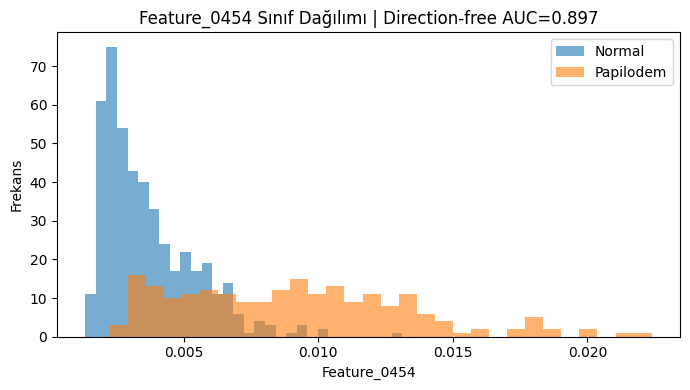

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/univariate_distribution_Feature_0454.png


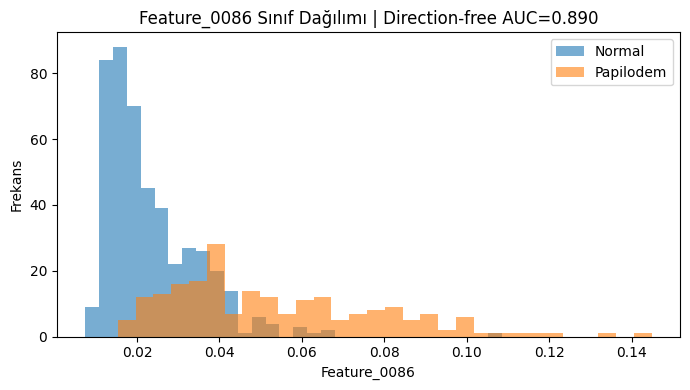

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/univariate_distribution_Feature_0086.png


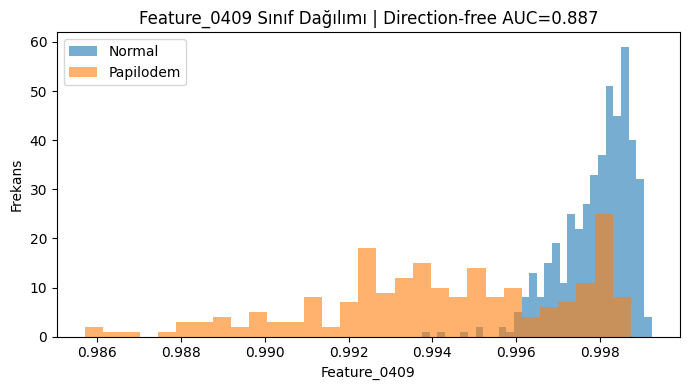

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/univariate_distribution_Feature_0409.png


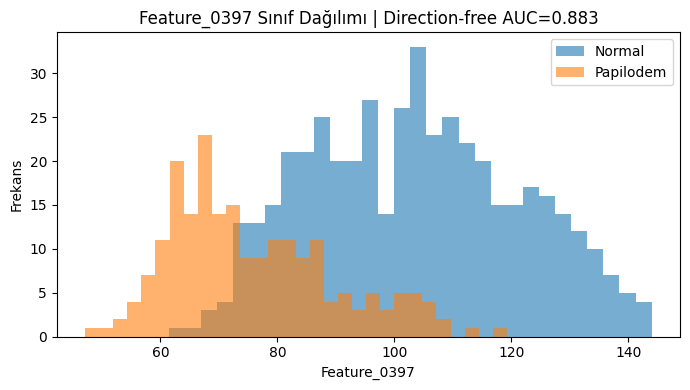

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/univariate_distribution_Feature_0397.png


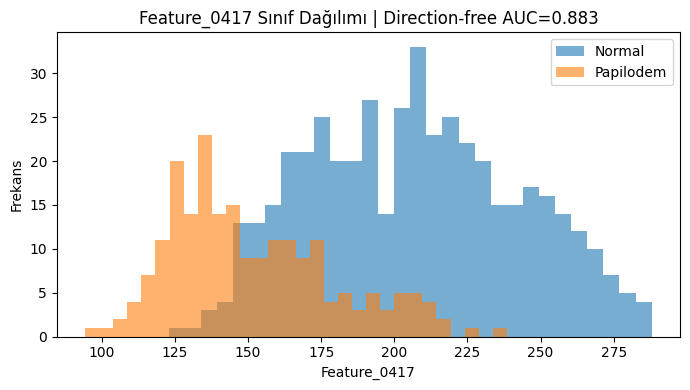

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/univariate_distribution_Feature_0417.png


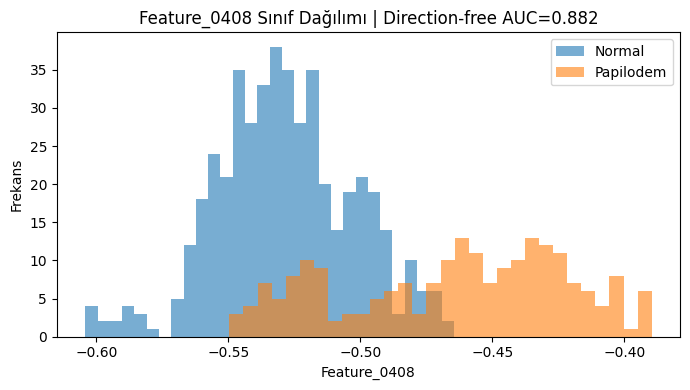

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/univariate_distribution_Feature_0408.png


In [13]:
# =========================
# HÜCRE 13: En Güçlü Tekil Özelliklerin Dağılım Grafikleri
# =========================

top_features_to_plot = univariate_auc_df.head(6)["feature"].tolist()

for feature in top_features_to_plot:
    plt.figure(figsize=(7, 4))

    normal_values = train_df.loc[train_df["target"] == 0, feature]
    pap_values = train_df.loc[train_df["target"] == 1, feature]

    plt.hist(normal_values, bins=30, alpha=0.6, label="Normal")
    plt.hist(pap_values, bins=30, alpha=0.6, label="Papilodem")

    auc_value = univariate_auc_df.loc[
        univariate_auc_df["feature"] == feature,
        "auc_direction_free"
    ].values[0]

    plt.title(f"{feature} Sınıf Dağılımı | Direction-free AUC={auc_value:.3f}")
    plt.xlabel(feature)
    plt.ylabel("Frekans")
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(FIGURE_DIR, f"univariate_distribution_{feature}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Grafik kaydedildi:", fig_path)

## 14. Ön İşleme Pipeline Fonksiyonunun Tanımlanması

Bu bölümde modelleme öncesinde uygulanacak ön işleme adımları tek bir sınıf yapısı içinde tanımlanacaktır.

Uygulanacak işlemler:

1. Sonsuz değerlerin eksik değer formatına dönüştürülmesi
2. Median imputation
3. Low-variance filtering
4. Pearson korelasyonu 0.95 üzerinde olan yüksek korelasyonlu özelliklerin elenmesi
5. RobustScaler ile ölçekleme

Bu yapı veri sızıntısını önlemek için önemlidir. Ön işleme yalnızca eğitim verisine fit edilecek, validation ve test setlerine yalnızca transform işlemi uygulanacaktır.

In [14]:
# =========================
# HÜCRE 14: Ön İşleme Pipeline Sınıfı
# =========================

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import RobustScaler

class RadiomicsPreprocessor:
    def __init__(self, variance_threshold=1e-8, corr_threshold=0.95):
        self.variance_threshold = variance_threshold
        self.corr_threshold = corr_threshold

    def fit(self, X):
        X = X.copy()
        self.input_features_ = list(X.columns)

        X = X.replace([np.inf, -np.inf], np.nan)

        self.imputer_ = SimpleImputer(strategy="median")
        X_imputed_array = self.imputer_.fit_transform(X)

        X_imputed = pd.DataFrame(
            X_imputed_array,
            columns=self.input_features_,
            index=X.index
        )

        self.variance_filter_ = VarianceThreshold(threshold=self.variance_threshold)
        X_var_array = self.variance_filter_.fit_transform(X_imputed)

        self.var_features_ = [
            feature for feature, keep in zip(
                self.input_features_,
                self.variance_filter_.get_support()
            )
            if keep
        ]

        X_var = pd.DataFrame(
            X_var_array,
            columns=self.var_features_,
            index=X.index
        )

        corr_matrix = X_var.corr(method="pearson").abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.high_corr_drop_features_ = [
            col for col in upper_triangle.columns
            if any(upper_triangle[col] > self.corr_threshold)
        ]

        self.corr_features_ = [
            col for col in self.var_features_
            if col not in self.high_corr_drop_features_
        ]

        X_corr = X_var[self.corr_features_]

        self.scaler_ = RobustScaler()
        self.scaler_.fit(X_corr)

        self.selected_features_ = self.corr_features_

        return self

    def transform(self, X):
        X = X.copy()
        X = X[self.input_features_]
        X = X.replace([np.inf, -np.inf], np.nan)

        X_imputed_array = self.imputer_.transform(X)

        X_imputed = pd.DataFrame(
            X_imputed_array,
            columns=self.input_features_,
            index=X.index
        )

        X_var = X_imputed[self.var_features_]
        X_corr = X_var[self.corr_features_]

        X_scaled_array = self.scaler_.transform(X_corr)

        X_scaled = pd.DataFrame(
            X_scaled_array,
            columns=self.selected_features_,
            index=X.index
        )

        return X_scaled

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

## 15. Ön İşleme Pipeline'ının Eğitim Verisine Fit Edilmesi

Bu bölümde ön işleme adımları yalnızca eğitim verisine fit edilecektir.

Validation ve test setleri üzerinde fit işlemi yapılmayacaktır. Böylece validation ve test verilerinden eğitim sürecine bilgi sızması engellenir.

Bu aşama final model eğitimi değildir. Amaç, ön işleme pipeline'ının doğru çalıştığını görmek ve özellik sayısındaki değişimi kontrol etmektir.

In [15]:
# =========================
# HÜCRE 15: Ön İşlemenin Train Verisine Fit Edilmesi
# =========================

X_train_raw = train_df[feature_cols].copy()
X_val_raw = val_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

y_train = train_df["target"].astype(int).values
y_val = val_df["target"].astype(int).values
y_test = test_df["target"].astype(int).values

groups_train = train_df["group_id"].values
groups_val = val_df["group_id"].values
groups_test = test_df["group_id"].values

preprocessor = RadiomicsPreprocessor(
    variance_threshold=1e-8,
    corr_threshold=0.95
)

X_train_prep = preprocessor.fit_transform(X_train_raw)
X_val_prep = preprocessor.transform(X_val_raw)
X_test_prep = preprocessor.transform(X_test_raw)

print("Ham train veri boyutu:", X_train_raw.shape)
print("Ön işleme sonrası train veri boyutu:", X_train_prep.shape)

print("\nValidation veri boyutu:", X_val_prep.shape)
print("Test veri boyutu:", X_test_prep.shape)

print("\nBaşlangıç özellik sayısı:", len(feature_cols))
print("Low-variance sonrası kalan özellik sayısı:", len(preprocessor.var_features_))
print("Yüksek korelasyon nedeniyle çıkarılan özellik sayısı:", len(preprocessor.high_corr_drop_features_))
print("Korelasyon filtresi sonrası kalan özellik sayısı:", len(preprocessor.selected_features_))

print("\nİlk 20 kalan özellik:")
print(preprocessor.selected_features_[:20])

Ham train veri boyutu: (672, 746)
Ön işleme sonrası train veri boyutu: (672, 237)

Validation veri boyutu: (98, 237)
Test veri boyutu: (196, 237)

Başlangıç özellik sayısı: 746
Low-variance sonrası kalan özellik sayısı: 719
Yüksek korelasyon nedeniyle çıkarılan özellik sayısı: 482
Korelasyon filtresi sonrası kalan özellik sayısı: 237

İlk 20 kalan özellik:
['Feature_0001', 'Feature_0003', 'Feature_0004', 'Feature_0005', 'Feature_0006', 'Feature_0007', 'Feature_0008', 'Feature_0010', 'Feature_0011', 'Feature_0016', 'Feature_0017', 'Feature_0018', 'Feature_0019', 'Feature_0020', 'Feature_0021', 'Feature_0022', 'Feature_0023', 'Feature_0024', 'Feature_0026', 'Feature_0027']


## 16. Ön İşleme Sonrası Özellik Sayısı Özeti ve Grafiği

Bu bölümde ön işleme adımlarından sonra özellik sayısının nasıl değiştiği tablo ve grafik halinde gösterilecektir.

Bu çıktı raporda veri ön işleme bölümünde kullanılacaktır.

,Aşama,Özellik Sayısı
0,Başlangıç radyomik özellikleri,746
1,Low-variance filtering sonrası,719
2,High-correlation filtering sonrası,237
3,RobustScaler sonrası final özellik seti,237


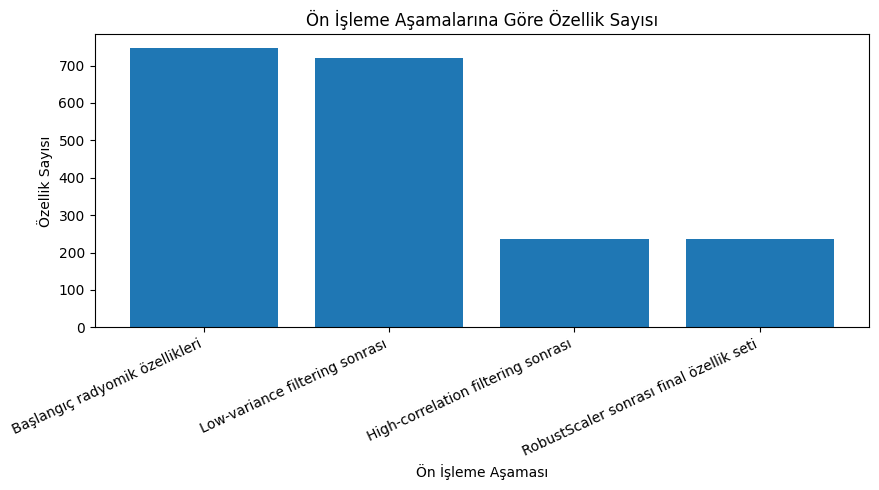

Ön işleme özet tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/preprocessing_feature_count_summary.csv

Grafik kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/preprocessing_feature_count_chart.png


In [16]:
# =========================
# HÜCRE 16: Ön İşleme Özeti ve Grafiği
# =========================

preprocess_summary = pd.DataFrame({
    "Aşama": [
        "Başlangıç radyomik özellikleri",
        "Low-variance filtering sonrası",
        "High-correlation filtering sonrası",
        "RobustScaler sonrası final özellik seti"
    ],
    "Özellik Sayısı": [
        len(feature_cols),
        len(preprocessor.var_features_),
        len(preprocessor.selected_features_),
        X_train_prep.shape[1]
    ]
})

display(preprocess_summary)

preprocess_summary_path = os.path.join(OUTPUT_DIR, "preprocessing_feature_count_summary.csv")
preprocess_summary.to_csv(preprocess_summary_path, index=False)

plt.figure(figsize=(9, 5))
plt.bar(preprocess_summary["Aşama"], preprocess_summary["Özellik Sayısı"])
plt.title("Ön İşleme Aşamalarına Göre Özellik Sayısı")
plt.xlabel("Ön İşleme Aşaması")
plt.ylabel("Özellik Sayısı")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

feature_count_fig_path = os.path.join(FIGURE_DIR, "preprocessing_feature_count_chart.png")
plt.savefig(feature_count_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Ön işleme özet tablosu kaydedildi:")
print(preprocess_summary_path)

print("\nGrafik kaydedildi:")
print(feature_count_fig_path)

## 17. MRMR Özellik Seçimi Fonksiyonunun Tanımlanması

Bu bölümde MRMR özellik seçimi için kullanılacak fonksiyon tanımlanacaktır.

MRMR yönteminde amaç, hedef değişkenle ilişkisi yüksek olan fakat birbirleriyle aşırı benzerlik taşımayan özellikleri seçmektir.

Bu çalışmada:

- Relevance: Mutual Information
- Redundancy: Ortalama mutlak Pearson korelasyonu

olarak hesaplanacaktır.

In [17]:
# =========================
# HÜCRE 17: MRMR Feature Selection Fonksiyonu
# =========================

from sklearn.feature_selection import mutual_info_classif

def mrmr_feature_selection(
    X,
    y,
    n_features=30,
    redundancy_weight=0.5,
    random_state=42
):
    X = X.copy()
    y = np.asarray(y)

    if n_features > X.shape[1]:
        n_features = X.shape[1]

    mi_scores = mutual_info_classif(
        X,
        y,
        random_state=random_state,
        discrete_features=False
    )

    relevance = pd.Series(mi_scores, index=X.columns)

    if relevance.max() > 0:
        relevance_norm = relevance / relevance.max()
    else:
        relevance_norm = relevance.copy()

    corr_matrix = X.corr(method="pearson").abs().fillna(0)

    selected_features = []
    remaining_features = list(X.columns)
    selection_records = []

    for step in range(n_features):
        if len(selected_features) == 0:
            redundancy = pd.Series(0, index=remaining_features)
        else:
            redundancy = corr_matrix.loc[remaining_features, selected_features].mean(axis=1)

        mrmr_score = relevance_norm.loc[remaining_features] - redundancy_weight * redundancy
        best_feature = mrmr_score.idxmax()

        selected_features.append(best_feature)

        selection_records.append({
            "selection_order": step + 1,
            "feature": best_feature,
            "mutual_information": relevance.loc[best_feature],
            "normalized_relevance": relevance_norm.loc[best_feature],
            "mean_abs_correlation_with_selected": redundancy.loc[best_feature],
            "mrmr_score": mrmr_score.loc[best_feature]
        })

        remaining_features.remove(best_feature)

    mrmr_table = pd.DataFrame(selection_records)

    return selected_features, mrmr_table

## 18. Eğitim Verisi Üzerinde MRMR Özellik Seçiminin Uygulanması

Bu bölümde MRMR özellik seçimi eğitim verisi üzerinde uygulanacaktır.

Pilot analiz için 30 özellik seçilecektir.

Bu aşamada test seti kullanılmayacaktır. Final modelleme aşamasında MRMR seçimi cross-validation içinde yeniden uygulanacaktır.

In [18]:
# =========================
# HÜCRE 18: MRMR Özellik Seçimini Uygulama
# =========================

MRMR_FEATURE_COUNT = 30

selected_mrmr_features, mrmr_table = mrmr_feature_selection(
    X=X_train_prep,
    y=y_train,
    n_features=MRMR_FEATURE_COUNT,
    redundancy_weight=0.5,
    random_state=RANDOM_STATE
)

print("MRMR ile seçilen özellik sayısı:", len(selected_mrmr_features))

print("\nSeçilen ilk 15 özellik:")
for i, feature in enumerate(selected_mrmr_features[:15], start=1):
    print(f"{i}. {feature}")

print("\nMRMR seçim tablosu ilk 20 satır:")
display(mrmr_table.head(20))

X_train_mrmr = X_train_prep[selected_mrmr_features].copy()
X_val_mrmr = X_val_prep[selected_mrmr_features].copy()
X_test_mrmr = X_test_prep[selected_mrmr_features].copy()

print("\nMRMR sonrası train veri boyutu:", X_train_mrmr.shape)
print("MRMR sonrası validation veri boyutu:", X_val_mrmr.shape)
print("MRMR sonrası test veri boyutu:", X_test_mrmr.shape)

mrmr_output_path = os.path.join(OUTPUT_DIR, "mrmr_selected_features_train_pilot.csv")
mrmr_table.to_csv(mrmr_output_path, index=False)

print("\nMRMR seçim tablosu kaydedildi:")
print(mrmr_output_path)

MRMR ile seçilen özellik sayısı: 30

Seçilen ilk 15 özellik:
1. Feature_0224
2. Feature_0408
3. Feature_0409
4. Feature_0028
5. Feature_0478
6. Feature_0034
7. Feature_0086
8. Feature_0135
9. Feature_0072
10. Feature_0040
11. Feature_0500
12. Feature_0067
13. Feature_0442
14. Feature_0043
15. Feature_0479

MRMR seçim tablosu ilk 20 satır:


,selection_order,feature,mutual_information,normalized_relevance,mean_abs_correlation_with_selected,mrmr_score
0,1,Feature_0224,0.335644,1.000000,0.000000,1.000000
1,2,Feature_0408,0.330446,0.984512,0.665726,0.651650
2,3,Feature_0409,0.319213,0.951044,0.823563,0.539263
3,4,Feature_0028,0.266974,0.795408,0.636085,0.477365
4,5,Feature_0478,0.262479,0.782015,0.721991,0.421019
5,6,Feature_0034,0.256874,0.765314,0.764010,0.383310
6,7,Feature_0086,0.252954,0.753636,0.735119,0.386076
7,8,Feature_0135,0.171413,0.510699,0.311540,0.354929
8,9,Feature_0072,0.227537,0.677911,0.594538,0.380642
9,10,Feature_0040,0.220424,0.656720,0.549582,0.381929



MRMR sonrası train veri boyutu: (672, 30)
MRMR sonrası validation veri boyutu: (98, 30)
MRMR sonrası test veri boyutu: (196, 30)

MRMR seçim tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/mrmr_selected_features_train_pilot.csv


## 19. MRMR Sonrası Özellik Sayısı Özeti ve Skor Grafiği

Bu bölümde MRMR ile seçilen özelliklerin skorları ve özellik sayısındaki azalma görselleştirilecektir.

Bu grafikler raporda özellik seçimi bölümünde kullanılabilir.

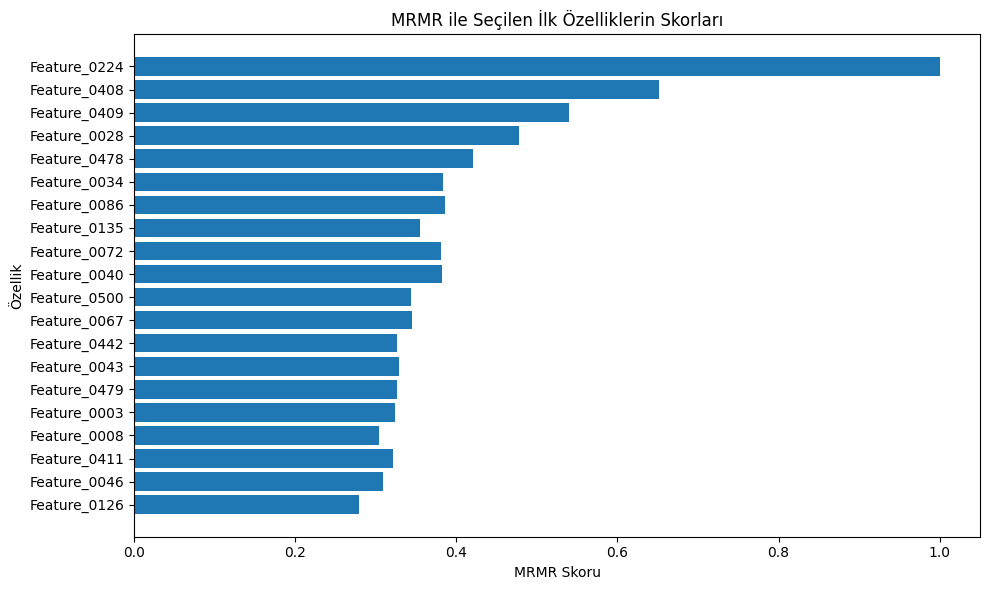

,Aşama,Özellik Sayısı
0,Başlangıç radyomik özellikleri,746
1,Ön işleme sonrası özellikler,237
2,MRMR sonrası seçilen özellikler,30


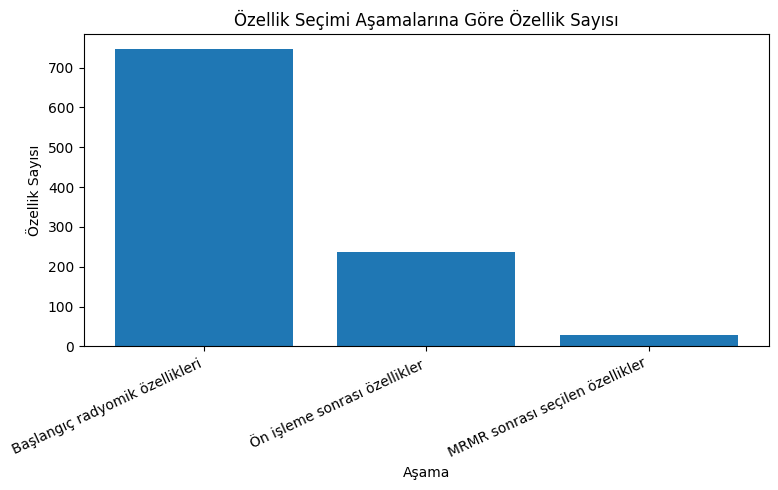

MRMR skor grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/mrmr_selected_features_scores.png

Özellik seçimi özet tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/feature_selection_summary.csv

Özellik seçimi grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/feature_selection_count_chart.png


In [19]:
# =========================
# HÜCRE 19: MRMR Özeti ve Grafikler
# =========================

top_n_plot = min(20, len(mrmr_table))
plot_df = mrmr_table.head(top_n_plot).copy()

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"][::-1], plot_df["mrmr_score"][::-1])
plt.title("MRMR ile Seçilen İlk Özelliklerin Skorları")
plt.xlabel("MRMR Skoru")
plt.ylabel("Özellik")
plt.tight_layout()

mrmr_fig_path = os.path.join(FIGURE_DIR, "mrmr_selected_features_scores.png")
plt.savefig(mrmr_fig_path, dpi=300, bbox_inches="tight")
plt.show()

feature_selection_summary = pd.DataFrame({
    "Aşama": [
        "Başlangıç radyomik özellikleri",
        "Ön işleme sonrası özellikler",
        "MRMR sonrası seçilen özellikler"
    ],
    "Özellik Sayısı": [
        len(feature_cols),
        X_train_prep.shape[1],
        X_train_mrmr.shape[1]
    ]
})

display(feature_selection_summary)

feature_selection_summary_path = os.path.join(OUTPUT_DIR, "feature_selection_summary.csv")
feature_selection_summary.to_csv(feature_selection_summary_path, index=False)

plt.figure(figsize=(8, 5))
plt.bar(feature_selection_summary["Aşama"], feature_selection_summary["Özellik Sayısı"])
plt.title("Özellik Seçimi Aşamalarına Göre Özellik Sayısı")
plt.xlabel("Aşama")
plt.ylabel("Özellik Sayısı")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

feature_selection_fig_path = os.path.join(FIGURE_DIR, "feature_selection_count_chart.png")
plt.savefig(feature_selection_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("MRMR skor grafiği kaydedildi:")
print(mrmr_fig_path)

print("\nÖzellik seçimi özet tablosu kaydedildi:")
print(feature_selection_summary_path)

print("\nÖzellik seçimi grafiği kaydedildi:")
print(feature_selection_fig_path)

## 20. Model Değerlendirme Fonksiyonlarının Tanımlanması

Bu bölümde validation seti üzerinde kullanılacak ortak değerlendirme fonksiyonu tanımlanacaktır.

Pozitif sınıf `Papilödem = 1` olarak kabul edilecektir.

Hesaplanacak metrikler:

- Accuracy
- Precision
- Recall
- F1-score
- Macro-F1
- Balanced Accuracy
- ROC-AUC
- PR-AUC
- Brier Score

Bu fonksiyon hem sanity check aşamasında hem de daha sonraki model karşılaştırmalarında kullanılacaktır.

In [20]:
# =========================
# HÜCRE 20: Değerlendirme Fonksiyonları
# =========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

def evaluate_binary_classification(y_true, y_pred, y_proba):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Brier Score": brier_score_loss(y_true, y_proba)
    }

    return metrics

print("Değerlendirme fonksiyonu hazır.")

Değerlendirme fonksiyonu hazır.


## 21. Test Setine Dokunmadan Repeated Patient-Level Sanity Check

Bu bölümde pilot sonuçların tek bir küçük validation bölmesine bağlı olup olmadığı kontrol edilecektir.

Bu analizde bağımsız test seti kullanılmayacaktır. Yalnızca train ve validation verileri birleştirilerek tekrar eden hasta bazlı train-validation ayrımları yapılacaktır.

Her tekrarda:

1. Hasta bazlı yeni train-validation ayrımı yapılır.
2. Ön işleme yalnızca train verisine fit edilir.
3. MRMR yalnızca train verisinde uygulanır.
4. Modeller validation setinde değerlendirilir.

Bu analiz final performans değildir. Amaç, yüksek validation başarısının farklı hasta bölmelerinde de devam edip etmediğini kontrol etmektir.

In [21]:
# =========================
# HÜCRE 21: Repeated Patient-Level Sanity Check
# =========================

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

N_SANITY_SPLITS = 20
SANITY_MRMR_FEATURE_COUNT = 30

# Test setine dokunmuyoruz. Sadece train + validation geliştirme alanında çalışıyoruz.
dev_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

dev_group_df = dev_df.groupby("group_id").agg(
    target=("target", "first"),
    class_name=("class_name", "first"),
    sample_count=("target", "size")
).reset_index()

print("Development veri boyutu:", dev_df.shape)
print("Development hasta/grup sayısı:", dev_group_df.shape[0])
print("\nDevelopment group-level sınıf dağılımı:")
print(dev_group_df["class_name"].value_counts())

sanity_models = {
    "LR": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "RBF-SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "RF": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "ET": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GB": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

sanity_records = []

for split_id in range(N_SANITY_SPLITS):
    print(f"\nSanity split çalışıyor: {split_id + 1}/{N_SANITY_SPLITS}")

    train_groups_s, val_groups_s = train_test_split(
        dev_group_df,
        test_size=0.20,
        random_state=RANDOM_STATE + split_id,
        stratify=dev_group_df["target"]
    )

    train_ids_s = set(train_groups_s["group_id"])
    val_ids_s = set(val_groups_s["group_id"])

    train_s = dev_df[dev_df["group_id"].isin(train_ids_s)].reset_index(drop=True)
    val_s = dev_df[dev_df["group_id"].isin(val_ids_s)].reset_index(drop=True)

    X_train_s_raw = train_s[feature_cols].copy()
    X_val_s_raw = val_s[feature_cols].copy()

    y_train_s = train_s["target"].astype(int).values
    y_val_s = val_s["target"].astype(int).values

    # Ön işleme yalnızca sanity train fold'una fit edilir
    preprocessor_s = RadiomicsPreprocessor(
        variance_threshold=1e-8,
        corr_threshold=0.95
    )

    X_train_s_prep = preprocessor_s.fit_transform(X_train_s_raw)
    X_val_s_prep = preprocessor_s.transform(X_val_s_raw)

    # MRMR yalnızca sanity train fold'u üzerinde yapılır
    selected_features_s, _ = mrmr_feature_selection(
        X=X_train_s_prep,
        y=y_train_s,
        n_features=SANITY_MRMR_FEATURE_COUNT,
        redundancy_weight=0.5,
        random_state=RANDOM_STATE + split_id
    )

    X_train_s_mrmr = X_train_s_prep[selected_features_s]
    X_val_s_mrmr = X_val_s_prep[selected_features_s]

    for model_name, base_model in sanity_models.items():
        model = clone(base_model)
        model.fit(X_train_s_mrmr, y_train_s)

        y_pred_s = model.predict(X_val_s_mrmr)
        y_proba_s = model.predict_proba(X_val_s_mrmr)[:, 1]

        metrics_s = evaluate_binary_classification(
            y_true=y_val_s,
            y_pred=y_pred_s,
            y_proba=y_proba_s
        )

        sanity_records.append({
            "split_id": split_id + 1,
            "model": model_name,
            "val_sample_count": len(y_val_s),
            "val_group_count": val_s["group_id"].nunique(),
            "val_normal_count": int((y_val_s == 0).sum()),
            "val_papilodem_count": int((y_val_s == 1).sum()),
            **metrics_s
        })

sanity_results_df = pd.DataFrame(sanity_records)

print("\nRepeated split sanity sonuçları:")
display(sanity_results_df)

sanity_summary_df = sanity_results_df.groupby("model").agg(
    Macro_F1_mean=("Macro-F1", "mean"),
    Macro_F1_std=("Macro-F1", "std"),
    ROC_AUC_mean=("ROC-AUC", "mean"),
    ROC_AUC_std=("ROC-AUC", "std"),
    PR_AUC_mean=("PR-AUC", "mean"),
    PR_AUC_std=("PR-AUC", "std"),
    Accuracy_mean=("Accuracy", "mean"),
    Accuracy_std=("Accuracy", "std"),
    Brier_mean=("Brier Score", "mean"),
    Brier_std=("Brier Score", "std")
).reset_index().sort_values(by="Macro_F1_mean", ascending=False)

print("\nRepeated split özet sonuçları:")
display(sanity_summary_df)

sanity_results_path = os.path.join(OUTPUT_DIR, "repeated_split_sanity_results.csv")
sanity_summary_path = os.path.join(OUTPUT_DIR, "repeated_split_sanity_summary.csv")

sanity_results_df.to_csv(sanity_results_path, index=False)
sanity_summary_df.to_csv(sanity_summary_path, index=False)

print("\nSanity sonuçları kaydedildi:")
print(sanity_results_path)
print(sanity_summary_path)

Development veri boyutu: (770, 751)
Development hasta/grup sayısı: 55

Development group-level sınıf dağılımı:
class_name
Normal       38
Papilodem    17
Name: count, dtype: int64

Sanity split çalışıyor: 1/20

Sanity split çalışıyor: 2/20

Sanity split çalışıyor: 3/20

Sanity split çalışıyor: 4/20

Sanity split çalışıyor: 5/20

Sanity split çalışıyor: 6/20

Sanity split çalışıyor: 7/20

Sanity split çalışıyor: 8/20

Sanity split çalışıyor: 9/20

Sanity split çalışıyor: 10/20

Sanity split çalışıyor: 11/20

Sanity split çalışıyor: 12/20

Sanity split çalışıyor: 13/20

Sanity split çalışıyor: 14/20

Sanity split çalışıyor: 15/20

Sanity split çalışıyor: 16/20

Sanity split çalışıyor: 17/20

Sanity split çalışıyor: 18/20

Sanity split çalışıyor: 19/20

Sanity split çalışıyor: 20/20

Repeated split sanity sonuçları:


,split_id,model,val_sample_count,val_group_count,val_normal_count,val_papilodem_count,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score
0,1,LR,154,11,112,42,0.844156,0.673077,0.833333,0.744681,0.816266,0.840774,0.887330,0.875692,0.147040
1,1,RBF-SVM,154,11,112,42,0.909091,0.791667,0.904762,0.844444,0.890112,0.907738,0.970876,0.948616,0.070673
2,1,RF,154,11,112,42,0.961039,0.973684,0.880952,0.925000,0.949342,0.936012,0.976403,0.965719,0.041933
3,1,ET,154,11,112,42,0.967532,1.000000,0.880952,0.936709,0.957437,0.940476,0.988520,0.979636,0.038218
4,1,GB,154,11,112,42,0.961039,0.928571,0.928571,0.928571,0.950893,0.950893,0.946854,0.950186,0.035592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,20,RBF-SVM,154,11,112,42,0.779221,0.653846,0.404762,0.500000,0.679167,0.662202,0.714286,0.581567,0.190078
116,20,RF,154,11,112,42,0.746753,0.560000,0.333333,0.417910,0.628042,0.617560,0.682717,0.569410,0.195430
117,20,ET,154,11,112,42,0.772727,0.666667,0.333333,0.444444,0.650794,0.635417,0.760310,0.622307,0.176756
118,20,GB,154,11,112,42,0.740260,0.538462,0.333333,0.411765,0.622549,0.613095,0.669855,0.522791,0.251688



Repeated split özet sonuçları:


,model,Macro_F1_mean,Macro_F1_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std,Accuracy_mean,Accuracy_std,Brier_mean,Brier_std
0,ET,0.894559,0.083080,0.926982,0.076574,0.909881,0.098346,0.922078,0.056058,0.067107,0.036968
4,RBF-SVM,0.885367,0.070289,0.914775,0.085950,0.891989,0.109882,0.911364,0.049912,0.075125,0.040780
5,RF,0.884015,0.082950,0.915944,0.088637,0.898126,0.107463,0.912987,0.057171,0.072385,0.039926
2,KNN,0.876895,0.075014,0.916194,0.076810,0.855695,0.120922,0.905519,0.052266,0.079325,0.041162
1,GB,0.872729,0.075458,0.906271,0.089102,0.889876,0.113670,0.902597,0.051777,0.083632,0.050946
3,LR,0.813302,0.072514,0.889286,0.093292,0.862347,0.118631,0.846429,0.056029,0.122783,0.043872



Sanity sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/repeated_split_sanity_results.csv
/content/drive/MyDrive/radiomics_papilodem_project/outputs/repeated_split_sanity_summary.csv


## 22. Repeated Sanity Check Sonuçlarının Görselleştirilmesi

Bu bölümde repeated patient-level sanity check sonucunda modellerin ortalama Macro-F1 skorları ve standart sapmaları görselleştirilecektir.

Bu grafik, model performansının tek bir validation bölmesine bağlı olup olmadığını anlamaya yardımcı olur.

Eğer modeller farklı bölmelerde de yüksek ve düşük standart sapmalı sonuçlar veriyorsa, veri setinde güçlü ve tutarlı bir ayırt edici sinyal olduğu söylenebilir.

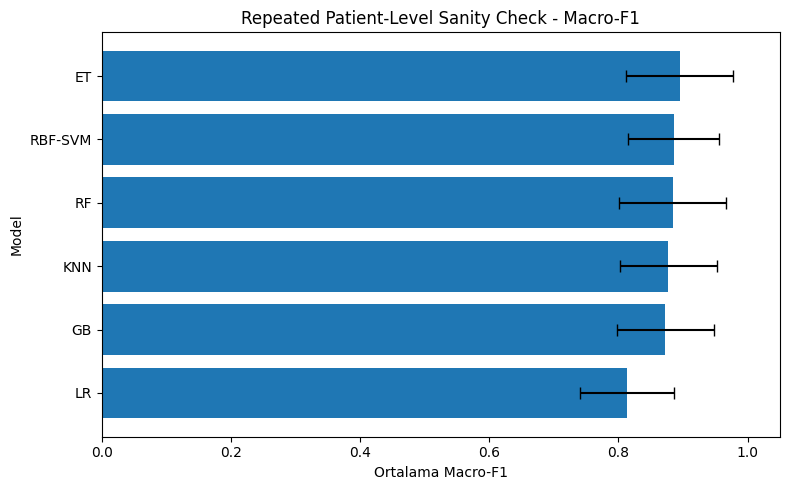

Repeated sanity Macro-F1 grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/repeated_sanity_macro_f1_comparison.png


In [22]:
# =========================
# HÜCRE 22: Repeated Sanity Check Macro-F1 Grafiği
# =========================

plot_df = sanity_summary_df.sort_values(by="Macro_F1_mean", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_df["model"],
    plot_df["Macro_F1_mean"],
    xerr=plot_df["Macro_F1_std"],
    capsize=4
)

plt.title("Repeated Patient-Level Sanity Check - Macro-F1")
plt.xlabel("Ortalama Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1.05)
plt.tight_layout()

sanity_macro_f1_fig_path = os.path.join(FIGURE_DIR, "repeated_sanity_macro_f1_comparison.png")
plt.savefig(sanity_macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Repeated sanity Macro-F1 grafiği kaydedildi:")
print(sanity_macro_f1_fig_path)

## 23. Final Optuna Ayarlarının Tanımlanması

Bu bölümde Optuna hiperparametre optimizasyonu final çalışma moduna alınacaktır.

İlk denemede pipeline'ın doğru çalıştığını görmek için trial sayısı düşük tutulmuştu. Final çalışmada ödev gereksinimini karşılamak için her model en az 50 trial ile optimize edilecektir.

Bu aşama zaman alabilir. Ancak final raporda kullanılacak hiperparametre optimizasyon sonuçları bu çalışmadan alınacaktır.

In [23]:
# =========================
# HÜCRE 23: Final Optuna Ayarları ve Objective Fonksiyonları
# =========================

import sys
import subprocess
import importlib.util
import numpy as np

# Optuna Colab runtime'da kurulu değilse otomatik kurulur
if importlib.util.find_spec("optuna") is None:
    print("Optuna bulunamadı. Kurulum başlatılıyor...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    print("Optuna kurulumu tamamlandı.")

import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# =========================
# Final Optuna Ayarları
# =========================

N_OPTUNA_TRIALS = 50
INNER_CV_SPLITS = 5

OPTUNA_MODEL_NAMES = [
    "LR",
    "RBF-SVM",
    "RF",
    "ET",
    "GB",
    "KNN"
]

MRMR_FEATURE_OPTIONS = [20, 30, 40, 50]

# None olursa Optuna sadece n_trials sayısına göre çalışır.
OPTUNA_TIMEOUT_PER_MODEL = None


# =========================
# Trial İçin Model Oluşturma Fonksiyonu
# =========================

def build_model_from_trial(model_name, trial):
    """
    Optuna trial içinde önerilen hiperparametrelere göre model oluşturur.
    """

    if model_name == "LR":
        C = trial.suggest_float("C", 1e-3, 100.0, log=True)
        class_weight = trial.suggest_categorical("class_weight", ["balanced", None])

        model = LogisticRegression(
            C=C,
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
            class_weight=class_weight,
            random_state=RANDOM_STATE
        )

    elif model_name == "RBF-SVM":
        C = trial.suggest_float("C", 1e-2, 100.0, log=True)
        gamma = trial.suggest_float("gamma", 1e-4, 10.0, log=True)
        class_weight = trial.suggest_categorical("class_weight", ["balanced", None])

        model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            probability=True,
            class_weight=class_weight,
            random_state=RANDOM_STATE
        )

    elif model_name == "RF":
        n_estimators = trial.suggest_categorical("n_estimators", [300, 500, 600])
        max_depth = trial.suggest_categorical("max_depth", [None, 6, 8, 10, 12, 16])
        min_samples_split = trial.suggest_categorical("min_samples_split", [2, 4, 6, 8])
        min_samples_leaf = trial.suggest_categorical("min_samples_leaf", [1, 2, 3, 4])
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
        class_weight = trial.suggest_categorical("class_weight", ["balanced", None])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == "ET":
        n_estimators = trial.suggest_categorical("n_estimators", [300, 500, 600])
        max_depth = trial.suggest_categorical("max_depth", [None, 6, 8, 10, 12, 16])
        min_samples_split = trial.suggest_categorical("min_samples_split", [2, 4, 6, 8])
        min_samples_leaf = trial.suggest_categorical("min_samples_leaf", [1, 2, 3, 4])
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
        class_weight = trial.suggest_categorical("class_weight", ["balanced", None])

        model = ExtraTreesClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == "GB":
        n_estimators = trial.suggest_categorical("n_estimators", [100, 200, 300])
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.20, log=True)
        max_depth = trial.suggest_categorical("max_depth", [2, 3, 4, 5])
        min_samples_split = trial.suggest_categorical("min_samples_split", [2, 4, 6, 8])
        min_samples_leaf = trial.suggest_categorical("min_samples_leaf", [1, 2, 3, 4, 5])
        subsample = trial.suggest_float("subsample", 0.60, 1.00)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            subsample=subsample,
            max_features=max_features,
            random_state=RANDOM_STATE
        )

    elif model_name == "KNN":
        n_neighbors = trial.suggest_int("n_neighbors", 3, 25, step=2)
        weights = trial.suggest_categorical("weights", ["uniform", "distance"])
        metric = trial.suggest_categorical("metric", ["euclidean", "manhattan"])

        model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )

    else:
        raise ValueError(f"Bilinmeyen model adı: {model_name}")

    return model


# =========================
# Optuna Objective Fonksiyonu
# =========================

def create_optuna_objective(model_name, X_raw, y, groups):
    """
    Optuna objective fonksiyonu.

    Her trial içinde:
    1. MRMR özellik sayısı seçilir.
    2. StratifiedGroupKFold ile inner CV yapılır.
    3. Her inner fold içinde preprocessing yalnızca inner-training verisine fit edilir.
    4. MRMR yalnızca inner-training verisinde yapılır.
    5. Model inner-validation fold üzerinde Macro-F1 ile değerlendirilir.
    """

    def objective(trial):
        n_mrmr_features = trial.suggest_categorical(
            "n_mrmr_features",
            MRMR_FEATURE_OPTIONS
        )

        inner_cv = StratifiedGroupKFold(
            n_splits=INNER_CV_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        fold_scores = []

        for fold_id, (inner_train_idx, inner_val_idx) in enumerate(
            inner_cv.split(X_raw, y, groups),
            start=1
        ):
            X_inner_train_raw = X_raw.iloc[inner_train_idx].copy()
            X_inner_val_raw = X_raw.iloc[inner_val_idx].copy()

            y_inner_train = y[inner_train_idx]
            y_inner_val = y[inner_val_idx]

            # 1. Preprocessing yalnızca inner-training verisine fit edilir.
            fold_preprocessor = RadiomicsPreprocessor(
                variance_threshold=1e-8,
                corr_threshold=0.95
            )

            X_inner_train_prep = fold_preprocessor.fit_transform(X_inner_train_raw)
            X_inner_val_prep = fold_preprocessor.transform(X_inner_val_raw)

            # 2. MRMR yalnızca inner-training verisinde yapılır.
            safe_n_features = min(n_mrmr_features, X_inner_train_prep.shape[1])

            selected_features_fold, _ = mrmr_feature_selection(
                X=X_inner_train_prep,
                y=y_inner_train,
                n_features=safe_n_features,
                redundancy_weight=0.5,
                random_state=RANDOM_STATE + fold_id
            )

            X_inner_train_selected = X_inner_train_prep[selected_features_fold]
            X_inner_val_selected = X_inner_val_prep[selected_features_fold]

            # 3. Trial parametrelerine göre model oluşturulur.
            model = build_model_from_trial(
                model_name=model_name,
                trial=trial
            )

            model.fit(X_inner_train_selected, y_inner_train)

            y_inner_pred = model.predict(X_inner_val_selected)

            macro_f1 = f1_score(
                y_inner_val,
                y_inner_pred,
                average="macro",
                zero_division=0
            )

            fold_scores.append(macro_f1)

        return float(np.mean(fold_scores))

    return objective


print("Final Optuna ayarları ve objective fonksiyonları hazır.")
print("Final Optuna trial sayısı:", N_OPTUNA_TRIALS)
print("Inner CV fold sayısı:", INNER_CV_SPLITS)
print("Optimize edilecek modeller:", OPTUNA_MODEL_NAMES)
print("MRMR özellik seçenekleri:", MRMR_FEATURE_OPTIONS)
print("OPTUNA_TIMEOUT_PER_MODEL:", OPTUNA_TIMEOUT_PER_MODEL)
print("Optuna ve TPESampler hazır.")

Final Optuna ayarları ve objective fonksiyonları hazır.
Final Optuna trial sayısı: 50
Inner CV fold sayısı: 5
Optimize edilecek modeller: ['LR', 'RBF-SVM', 'RF', 'ET', 'GB', 'KNN']
MRMR özellik seçenekleri: [20, 30, 40, 50]
OPTUNA_TIMEOUT_PER_MODEL: None
Optuna ve TPESampler hazır.


## 24. Final Optuna Hiperparametre Optimizasyonunun Çalıştırılması

Bu bölümde tüm modeller için final hiperparametre optimizasyonu çalıştırılacaktır.

Her model için:

- 50 Optuna trial
- TPE sampler
- Inner StratifiedGroupKFold
- Amaç fonksiyonu olarak Macro-F1

kullanılacaktır.

Ön işleme ve MRMR özellik seçimi her inner fold içinde yeniden uygulanacaktır. Böylece preprocessing ve feature selection kaynaklı veri sızıntısı engellenecektir.

Bu aşamada yalnızca eğitim seti kullanılacaktır. Validation ve test setleri kullanılmayacaktır.

In [24]:
# =========================
# HÜCRE 24: Final Optuna Optimizasyonu
# =========================

final_optuna_studies = {}
final_optuna_best_records = []

X_optuna_raw = train_df[feature_cols].copy()
y_optuna = train_df["target"].astype(int).values
groups_optuna = train_df["group_id"].values

for model_name in OPTUNA_MODEL_NAMES:
    print("\n" + "=" * 80)
    print(f"FINAL Optuna başlıyor: {model_name}")
    print("=" * 80)

    sampler = TPESampler(seed=RANDOM_STATE)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        study_name=f"FINAL_{model_name}_macro_f1_optimization"
    )

    objective = create_optuna_objective(
        model_name=model_name,
        X_raw=X_optuna_raw,
        y=y_optuna,
        groups=groups_optuna
    )

    study.optimize(
        objective,
        n_trials=N_OPTUNA_TRIALS,
        timeout=OPTUNA_TIMEOUT_PER_MODEL,
        show_progress_bar=True
    )

    final_optuna_studies[model_name] = study

    best_record = {
        "Model": model_name,
        "Best Inner CV Macro-F1": study.best_value,
        "Best Params": study.best_params
    }

    final_optuna_best_records.append(best_record)

    print(f"\n{model_name} final en iyi Macro-F1:", study.best_value)
    print(f"{model_name} final en iyi parametreler:")
    print(study.best_params)

    trials_df = study.trials_dataframe()
    trials_output_path = os.path.join(OUTPUT_DIR, f"final_optuna_trials_{model_name}.csv")
    trials_df.to_csv(trials_output_path, index=False)

    print("Final trial sonuçları kaydedildi:")
    print(trials_output_path)

final_optuna_best_df = pd.DataFrame(final_optuna_best_records)
final_optuna_best_df = final_optuna_best_df.sort_values(
    by="Best Inner CV Macro-F1",
    ascending=False
).reset_index(drop=True)

print("\nTüm modeller için FINAL Optuna en iyi sonuçlar:")
display(final_optuna_best_df)

final_optuna_best_path = os.path.join(OUTPUT_DIR, "final_optuna_best_model_results.csv")
final_optuna_best_df.to_csv(final_optuna_best_path, index=False)

print("\nFinal Optuna en iyi sonuç tablosu kaydedildi:")
print(final_optuna_best_path)

[I 2026-06-09 20:29:27,307] A new study created in memory with name: FINAL_LR_macro_f1_optimization



FINAL Optuna başlıyor: LR


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-09 20:29:36,737] Trial 0 finished with value: 0.8327446941701389 and parameters: {'n_mrmr_features': 30, 'C': 0.006026889128682512, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8327446941701389.
[I 2026-06-09 20:29:47,455] Trial 1 finished with value: 0.7897149860407617 and parameters: {'n_mrmr_features': 20, 'C': 70.72114131472235, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8327446941701389.
[I 2026-06-09 20:29:58,454] Trial 2 finished with value: 0.8296125489909741 and parameters: {'n_mrmr_features': 50, 'C': 0.14445251022763064, 'class_weight': None}. Best is trial 0 with value: 0.8327446941701389.
[I 2026-06-09 20:30:08,535] Trial 3 finished with value: 0.8303342075907885 and parameters: {'n_mrmr_features': 50, 'C': 8.43101393208247, 'class_weight': None}. Best is trial 0 with value: 0.8327446941701389.
[I 2026-06-09 20:30:19,055] Trial 4 finished with value: 0.8168957255141984 and parameters: {'n_mrmr_features': 40, 'C': 0.00211474479606157

[I 2026-06-09 20:38:02,278] A new study created in memory with name: FINAL_RBF-SVM_macro_f1_optimization


...

[I 2026-06-09 21:26:23,126] Trial 49 finished with value: 0.8494284175241218 and parameters: {'n_mrmr_features': 50, 'n_estimators': 100, 'learning_rate': 0.06830106408467519, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 3, 'subsample': 0.6324722318639536, 'max_features': 'log2'}. Best is trial 35 with value: 0.8765226923444956.

GB final en iyi Macro-F1: 0.8765226923444956
GB final en iyi parametreler:
{'n_mrmr_features': 20, 'n_estimators': 300, 'learning_rate': 0.049276780545154386, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 3, 'subsample': 0.9452842221666277, 'max_features': 'log2'}
Final trial sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/final_optuna_trials_GB.csv

FINAL Optuna başlıyor: KNN


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-09 21:26:33,166] Trial 0 finished with value: 0.8654755477200877 and parameters: {'n_mrmr_features': 30, 'n_neighbors': 5, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.8654755477200877.
[I 2026-06-09 21:26:43,181] Trial 1 finished with value: 0.8687482225930336 and parameters: {'n_mrmr_features': 40, 'n_neighbors': 7, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: 0.8687482225930336.
[I 2026-06-09 21:26:51,762] Trial 2 finished with value: 0.8572723592774774 and parameters: {'n_mrmr_features': 40, 'n_neighbors': 9, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.8687482225930336.
[I 2026-06-09 21:27:01,832] Trial 3 finished with value: 0.8593518595422738 and parameters: {'n_mrmr_features': 50, 'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.8687482225930336.
[I 2026-06-09 21:27:12,159] Trial 4 finished with value: 0.8474064883632961 and param

,Model,Best Inner CV Macro-F1,Best Params
0,GB,0.876523,"{'n_mrmr_features': 20, 'n_estimators': 300, '..."
1,RBF-SVM,0.870174,"{'n_mrmr_features': 20, 'C': 3.689062735584881..."
2,ET,0.869030,"{'n_mrmr_features': 20, 'n_estimators': 500, '..."
3,KNN,0.868748,"{'n_mrmr_features': 40, 'n_neighbors': 7, 'wei..."
4,RF,0.864311,"{'n_mrmr_features': 20, 'n_estimators': 500, '..."
5,LR,0.853445,"{'n_mrmr_features': 50, 'C': 70.47325306682897..."



Final Optuna en iyi sonuç tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/final_optuna_best_model_results.csv


## 25. Final Optuna Parametrelerinin JSON Formatında Kaydedilmesi

Bu bölümde final Optuna optimizasyonu sonucunda elde edilen en iyi parametreler JSON formatında kaydedilecektir.

Bu kayıt, raporda her model için seçilen hiperparametrelerin açık şekilde sunulmasını sağlar.

In [26]:
# =========================
# HÜCRE 25: Final Optuna Best Params JSON Kaydı
# =========================

import json

final_optuna_best_params_readable = {}

for model_name, study in final_optuna_studies.items():
    final_optuna_best_params_readable[model_name] = {
        "best_inner_cv_macro_f1": study.best_value,
        "best_params": study.best_params
    }

final_readable_params_path = os.path.join(OUTPUT_DIR, "final_optuna_best_params_readable.json")

with open(final_readable_params_path, "w", encoding="utf-8") as f:
    json.dump(final_optuna_best_params_readable, f, indent=4, ensure_ascii=False)

print("Final Optuna parametreleri kaydedildi:")
print(final_readable_params_path)

print("\nFinal model bazlı en iyi parametreler:")
for model_name, info in final_optuna_best_params_readable.items():
    print("\n" + "=" * 60)
    print(model_name)
    print("Best Inner CV Macro-F1:", info["best_inner_cv_macro_f1"])
    print("Best Params:")
    print(json.dumps(info["best_params"], indent=4, ensure_ascii=False))

Final Optuna parametreleri kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/final_optuna_best_params_readable.json

Final model bazlı en iyi parametreler:

LR
Best Inner CV Macro-F1: 0.8534446857681932
Best Params:
{
    "n_mrmr_features": 50,
    "C": 70.47325306682897,
    "class_weight": null
}

RBF-SVM
Best Inner CV Macro-F1: 0.8701740500711436
Best Params:
{
    "n_mrmr_features": 20,
    "C": 3.6890627355848817,
    "gamma": 0.1824631857395044,
    "class_weight": null
}

RF
Best Inner CV Macro-F1: 0.8643107159771466
Best Params:
{
    "n_mrmr_features": 20,
    "n_estimators": 500,
    "max_depth": 16,
    "min_samples_split": 6,
    "min_samples_leaf": 3,
    "max_features": "sqrt",
    "class_weight": "balanced"
}

ET
Best Inner CV Macro-F1: 0.8690295020673993
Best Params:
{
    "n_mrmr_features": 20,
    "n_estimators": 500,
    "max_depth": 16,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "log2",
    "class_weight": "balanc

## 26. Final Optuna Sonuçlarının Görselleştirilmesi

Bu bölümde her model için final Optuna inner cross-validation sonucunda elde edilen en iyi Macro-F1 skorları görselleştirilecektir.

Bu grafik, hiperparametre optimizasyonu sonrası modellerin eğitim seti içindeki cross-validation başarısını karşılaştırır.

Bu sonuçlar final test performansı değildir. Final performans bağımsız test setinde ayrıca değerlendirilecektir.

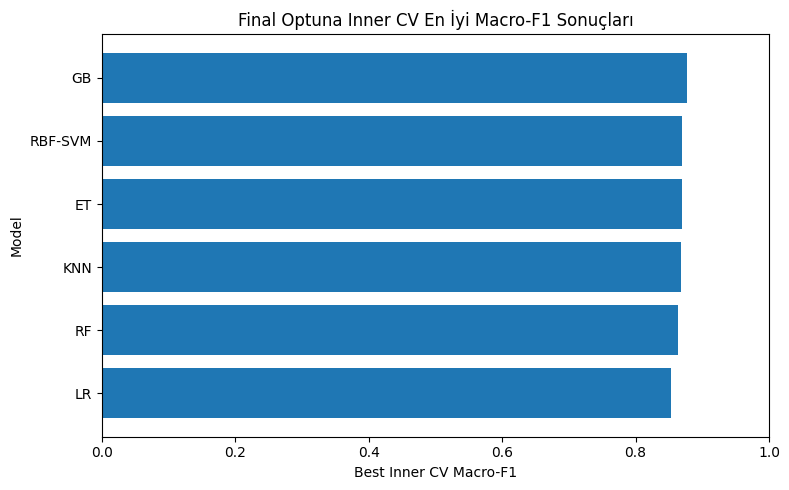

Final Optuna sonuç grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/final_optuna_best_inner_cv_macro_f1.png


In [27]:
# =========================
# HÜCRE 26: Final Optuna En İyi Macro-F1 Grafiği
# =========================

plot_df = final_optuna_best_df.sort_values(by="Best Inner CV Macro-F1", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Model"], plot_df["Best Inner CV Macro-F1"])
plt.title("Final Optuna Inner CV En İyi Macro-F1 Sonuçları")
plt.xlabel("Best Inner CV Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()

final_optuna_best_fig_path = os.path.join(FIGURE_DIR, "final_optuna_best_inner_cv_macro_f1.png")
plt.savefig(final_optuna_best_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Final Optuna sonuç grafiği kaydedildi:")
print(final_optuna_best_fig_path)

## 27. Final Optuna Parametreleriyle Model Oluşturma Fonksiyonunun Tanımlanması

Bu bölümde Optuna tarafından seçilen en iyi hiperparametreler kullanılarak modellerin yeniden oluşturulması için yardımcı fonksiyon tanımlanacaktır.

Optuna sonucunda her model için `n_mrmr_features` değeri ve model hiperparametreleri birlikte kaydedilmiştir.  
Bu fonksiyon `n_mrmr_features` değerini özellik seçimi için ayıracak, kalan parametrelerle ilgili makine öğrenmesi modelini oluşturacaktır.

Bu yapı, final model eğitiminde her modelin kendi en iyi Optuna ayarlarıyla çalışmasını sağlar.

In [28]:
# =========================
# HÜCRE 27: Best Parametrelerle Model Oluşturma Fonksiyonu
# =========================

def build_model_from_best_params(model_name, best_params):
    """
    Optuna best_params sözlüğünden model oluşturur.
    n_mrmr_features parametresi model parametresi olmadığı için ayrılır.
    """

    params = best_params.copy()
    params.pop("n_mrmr_features", None)

    if model_name == "LR":
        model = LogisticRegression(
            C=params["C"],
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
            class_weight=params["class_weight"],
            random_state=RANDOM_STATE
        )

    elif model_name == "RBF-SVM":
        model = SVC(
            kernel="rbf",
            C=params["C"],
            gamma=params["gamma"],
            probability=True,
            class_weight=params["class_weight"],
            random_state=RANDOM_STATE
        )

    elif model_name == "RF":
        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            class_weight=params["class_weight"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == "ET":
        model = ExtraTreesClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            class_weight=params["class_weight"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == "GB":
        model = GradientBoostingClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            subsample=params["subsample"],
            max_features=params["max_features"],
            random_state=RANDOM_STATE
        )

    elif model_name == "KNN":
        model = KNeighborsClassifier(
            n_neighbors=params["n_neighbors"],
            weights=params["weights"],
            metric=params["metric"]
        )

    else:
        raise ValueError(f"Bilinmeyen model adı: {model_name}")

    return model

print("Best parametrelerle model oluşturma fonksiyonu hazır.")

Best parametrelerle model oluşturma fonksiyonu hazır.


## 28. Final Model Pipeline Fit ve Prediction Fonksiyonlarının Tanımlanması

Bu bölümde her model için tam pipeline fonksiyonları tanımlanacaktır.

Her model pipeline'ı şu adımlardan oluşacaktır:

1. Eğitim verisinde median imputation, low-variance filtering, high-correlation filtering ve RobustScaler öğrenilir.
2. Eğitim verisi üzerinde MRMR özellik seçimi yapılır.
3. Optuna ile belirlenen en iyi hiperparametrelerle model eğitilir.
4. Validation veya test verisine yalnızca transform işlemleri uygulanır.
5. Seçilen MRMR özellikleriyle tahmin olasılıkları üretilir.

Bu yapı, preprocessing ve feature selection adımlarının yalnızca eğitim verisinden öğrenilmesini sağlayarak veri sızıntısını önler.

In [29]:
# =========================
# HÜCRE 28: Pipeline Fit ve Prediction Fonksiyonları
# =========================

def fit_model_pipeline(train_data, feature_columns, model_name, best_params):
    """
    Bir model için preprocessing + MRMR + model eğitim pipeline'ını fit eder.
    """

    X_train_raw_local = train_data[feature_columns].copy()
    y_train_local = train_data["target"].astype(int).values

    n_mrmr_features = best_params["n_mrmr_features"]

    # 1. Ön işleme yalnızca train verisine fit edilir
    local_preprocessor = RadiomicsPreprocessor(
        variance_threshold=1e-8,
        corr_threshold=0.95
    )

    X_train_prep_local = local_preprocessor.fit_transform(X_train_raw_local)

    # 2. MRMR yalnızca train verisinde yapılır
    local_selected_features, local_mrmr_table = mrmr_feature_selection(
        X=X_train_prep_local,
        y=y_train_local,
        n_features=n_mrmr_features,
        redundancy_weight=0.5,
        random_state=RANDOM_STATE
    )

    X_train_selected_local = X_train_prep_local[local_selected_features]

    # 3. Model en iyi Optuna parametreleriyle kurulur ve eğitilir
    local_model = build_model_from_best_params(
        model_name=model_name,
        best_params=best_params
    )

    local_model.fit(X_train_selected_local, y_train_local)

    pipeline = {
        "model_name": model_name,
        "best_params": best_params,
        "n_mrmr_features": n_mrmr_features,
        "preprocessor": local_preprocessor,
        "selected_features": local_selected_features,
        "mrmr_table": local_mrmr_table,
        "model": local_model
    }

    return pipeline


def predict_pipeline_proba(pipeline, data, feature_columns):
    """
    Fit edilmiş pipeline ile pozitif sınıf olasılığı üretir.
    Pozitif sınıf: Papilödem = 1
    """

    X_raw_local = data[feature_columns].copy()

    X_prep_local = pipeline["preprocessor"].transform(X_raw_local)
    X_selected_local = X_prep_local[pipeline["selected_features"]]

    y_proba_local = pipeline["model"].predict_proba(X_selected_local)[:, 1]

    return y_proba_local


def predict_pipeline_label_from_threshold(y_proba, threshold=0.5):
    return (np.asarray(y_proba) >= threshold).astype(int)

print("Pipeline fit ve prediction fonksiyonları hazır.")

Pipeline fit ve prediction fonksiyonları hazır.


## 29. Sigmoid Calibration Sınıfının Tanımlanması

Bu bölümde model olasılıklarını kalibre etmek için sigmoid calibration yapısı tanımlanacaktır.

Kalibrasyon, modelin ürettiği ham olasılık değerlerini daha güvenilir hale getirmek için kullanılır.

Bu çalışmada kalibrasyon doğrudan validation set üzerinde öğrenilmeyecektir. Bunun yerine train set içinde patient-level inner cross-validation ile out-of-fold olasılıklar üretilecek ve sigmoid calibrator bu olasılıklar üzerinde eğitilecektir.

Bu yaklaşım, validation setin yalnızca threshold seçimi için kullanılmasını sağlar.

In [30]:
# =========================
# HÜCRE 29: Sigmoid Calibration Sınıfı
# =========================

class SigmoidProbabilityCalibrator:
    """
    Ham pozitif sınıf olasılıklarını sigmoid calibration ile kalibre eder.
    Girdi: pozitif sınıf olasılığı
    Çıktı: kalibre edilmiş pozitif sınıf olasılığı
    """

    def __init__(self, eps=1e-6):
        self.eps = eps
        self.calibration_model = LogisticRegression(
            C=1e6,
            solver="lbfgs",
            max_iter=1000
        )

    def _to_logit_feature(self, proba):
        proba = np.asarray(proba)
        proba = np.clip(proba, self.eps, 1 - self.eps)
        logit_values = np.log(proba / (1 - proba))
        return logit_values.reshape(-1, 1)

    def fit(self, proba, y):
        X_logit = self._to_logit_feature(proba)
        self.calibration_model.fit(X_logit, y)
        return self

    def predict_proba(self, proba):
        X_logit = self._to_logit_feature(proba)
        calibrated_proba = self.calibration_model.predict_proba(X_logit)[:, 1]
        return calibrated_proba

print("Sigmoid calibration sınıfı hazır.")

Sigmoid calibration sınıfı hazır.


## 30. Train İçinde Out-of-Fold Olasılık Üreterek Calibration Fonksiyonunun Tanımlanması

Bu bölümde calibration için kullanılacak out-of-fold olasılıklar üretilecektir.

Her model için train set üzerinde StratifiedGroupKFold uygulanacaktır. Her fold içinde:

1. Preprocessing yalnızca fold-training kısmına fit edilir.
2. MRMR yalnızca fold-training kısmında uygulanır.
3. Model fold-training kısmında eğitilir.
4. Fold-validation kısmı için ham olasılıklar üretilir.

Böylece train setindeki her örnek için, kendisini eğitimde görmemiş bir modelden olasılık değeri elde edilir. Sigmoid calibrator bu out-of-fold olasılıklarla eğitilecektir.

Bu yapı validation set üzerinde calibration fit edilmesini engeller.

In [31]:
# =========================
# HÜCRE 30: Out-of-Fold Calibration Fonksiyonu
# =========================

def fit_oof_sigmoid_calibrator(
    train_data,
    feature_columns,
    model_name,
    best_params,
    n_splits=3,
    random_state=42
):
    """
    Train set içinde patient-level OOF olasılıklar üretir ve sigmoid calibrator fit eder.
    """

    X_raw = train_data[feature_columns].copy()
    y = train_data["target"].astype(int).values
    groups = train_data["group_id"].values

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    oof_proba = np.zeros(len(y), dtype=float)

    n_mrmr_features = best_params["n_mrmr_features"]

    for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_raw, y, groups), start=1):
        print(f"  Calibration OOF fold {fold_id}/{n_splits}")

        fold_train = train_data.iloc[tr_idx].reset_index(drop=True)
        fold_val = train_data.iloc[va_idx].reset_index(drop=True)

        X_fold_train_raw = fold_train[feature_columns].copy()
        y_fold_train = fold_train["target"].astype(int).values

        X_fold_val_raw = fold_val[feature_columns].copy()

        # Fold preprocessing
        fold_preprocessor = RadiomicsPreprocessor(
            variance_threshold=1e-8,
            corr_threshold=0.95
        )

        X_fold_train_prep = fold_preprocessor.fit_transform(X_fold_train_raw)
        X_fold_val_prep = fold_preprocessor.transform(X_fold_val_raw)

        # Fold MRMR
        fold_selected_features, _ = mrmr_feature_selection(
            X=X_fold_train_prep,
            y=y_fold_train,
            n_features=n_mrmr_features,
            redundancy_weight=0.5,
            random_state=random_state + fold_id
        )

        X_fold_train_selected = X_fold_train_prep[fold_selected_features]
        X_fold_val_selected = X_fold_val_prep[fold_selected_features]

        # Fold model
        fold_model = build_model_from_best_params(
            model_name=model_name,
            best_params=best_params
        )

        fold_model.fit(X_fold_train_selected, y_fold_train)

        fold_val_proba = fold_model.predict_proba(X_fold_val_selected)[:, 1]

        # Dikkat: va_idx train_data indeksine göre olduğu için doğrudan dolduruyoruz
        oof_proba[va_idx] = fold_val_proba

    calibrator = SigmoidProbabilityCalibrator()
    calibrator.fit(oof_proba, y)

    return calibrator, oof_proba

print("OOF calibration fonksiyonu hazır.")

OOF calibration fonksiyonu hazır.


## 31. Validation Setinde Threshold Optimizasyonu Fonksiyonunun Tanımlanması

Bu bölümde kalibre edilmiş validation olasılıkları üzerinden karar eşiği seçilecektir.

Threshold seçimi validation set üzerinde yapılacaktır. Bu nedenle validation sonuçları final model başarısı olarak değil, model geliştirme ve eşik seçimi aşaması olarak yorumlanmalıdır.

Final performans yalnızca bağımsız test setinde hesaplanacaktır.

In [32]:
# =========================
# HÜCRE 31: Threshold Optimizasyonu
# =========================

def optimize_threshold_on_validation(y_true, y_proba, step=0.01):
    thresholds = np.arange(0.05, 0.951, step)
    records = []

    for threshold in thresholds:
        y_pred = (np.asarray(y_proba) >= threshold).astype(int)

        macro_f1 = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        balanced_acc = balanced_accuracy_score(y_true, y_pred)

        records.append({
            "threshold": float(threshold),
            "Macro-F1": macro_f1,
            "Balanced Accuracy": balanced_acc
        })

    threshold_df = pd.DataFrame(records)

    best_row = threshold_df.sort_values(
        by=["Macro-F1", "Balanced Accuracy"],
        ascending=False
    ).iloc[0]

    best_threshold = float(best_row["threshold"])

    return best_threshold, threshold_df

print("Threshold optimizasyon fonksiyonu hazır.")

Threshold optimizasyon fonksiyonu hazır.


## 32. Modellerin Train Set Üzerinde Eğitilmesi, OOF Calibration ve Validation Threshold Seçimi

Bu bölümde her model için aşağıdaki işlemler yapılacaktır:

1. Train set içinde out-of-fold olasılıklar üretilir.
2. Sigmoid calibrator yalnızca train içindeki OOF olasılıklar üzerinde fit edilir.
3. Final model pipeline'ı train setin tamamı üzerinde eğitilir.
4. Validation set için ham olasılıklar üretilir.
5. Train üzerinde fit edilen calibrator validation olasılıklarına uygulanır.
6. Validation set üzerinde en uygun threshold seçilir.

Bu aşamada test seti kullanılmayacaktır.

In [33]:
# =========================
# HÜCRE 32: OOF Calibration + Train Pipeline + Validation Threshold
# =========================

trained_pipelines = {}
model_calibrators = {}
model_thresholds = {}
validation_prediction_store = {}
validation_results = []

for model_name, study in final_optuna_studies.items():
    print("\n" + "=" * 80)
    print(f"Model hazırlanıyor: {model_name}")
    print("=" * 80)

    best_params = study.best_params

    # 1. Train içinden OOF probability üret ve calibrator fit et
    calibrator, oof_train_proba_raw = fit_oof_sigmoid_calibrator(
        train_data=train_df,
        feature_columns=feature_cols,
        model_name=model_name,
        best_params=best_params,
        n_splits=INNER_CV_SPLITS,
        random_state=RANDOM_STATE
    )

    y_train_array = train_df["target"].astype(int).values
    oof_train_proba_calibrated = calibrator.predict_proba(oof_train_proba_raw)

    model_calibrators[model_name] = calibrator

    # 2. Final pipeline train setin tamamı üzerinde fit edilir
    pipeline = fit_model_pipeline(
        train_data=train_df,
        feature_columns=feature_cols,
        model_name=model_name,
        best_params=best_params
    )

    trained_pipelines[model_name] = pipeline

    # 3. Validation üzerinde ham ve calibrated probability üret
    y_val_proba_raw = predict_pipeline_proba(
        pipeline=pipeline,
        data=val_df,
        feature_columns=feature_cols
    )

    y_val_proba_calibrated = calibrator.predict_proba(y_val_proba_raw)

    # 4. Validation üzerinde threshold seç
    best_threshold, threshold_df = optimize_threshold_on_validation(
        y_true=y_val,
        y_proba=y_val_proba_calibrated,
        step=0.01
    )

    model_thresholds[model_name] = best_threshold

    y_val_pred = predict_pipeline_label_from_threshold(
        y_val_proba_calibrated,
        threshold=best_threshold
    )

    # Bu metrikler final başarı değil; threshold seçimi tanı çıktısıdır.
    metrics = evaluate_binary_classification(
        y_true=y_val,
        y_pred=y_val_pred,
        y_proba=y_val_proba_calibrated
    )

    metrics["Model"] = model_name
    metrics["Best Inner CV Macro-F1"] = study.best_value
    metrics["N MRMR Features"] = pipeline["n_mrmr_features"]
    metrics["Best Threshold"] = best_threshold

    # Calibration train diagnostics
    oof_train_pred_05 = (oof_train_proba_calibrated >= 0.5).astype(int)
    metrics["OOF Train Macro-F1 @0.5"] = f1_score(
        y_train_array,
        oof_train_pred_05,
        average="macro",
        zero_division=0
    )
    metrics["OOF Train ROC-AUC"] = roc_auc_score(
        y_train_array,
        oof_train_proba_calibrated
    )
    metrics["OOF Train PR-AUC"] = average_precision_score(
        y_train_array,
        oof_train_proba_calibrated
    )
    metrics["OOF Train Brier"] = brier_score_loss(
        y_train_array,
        oof_train_proba_calibrated
    )

    validation_results.append(metrics)

    validation_prediction_store[model_name] = {
        "oof_train_raw_proba": oof_train_proba_raw,
        "oof_train_calibrated_proba": oof_train_proba_calibrated,
        "val_raw_proba": y_val_proba_raw,
        "val_calibrated_proba": y_val_proba_calibrated,
        "val_pred": y_val_pred,
        "threshold_df": threshold_df
    }

    threshold_output_path = os.path.join(OUTPUT_DIR, f"threshold_search_validation_{model_name}.csv")
    threshold_df.to_csv(threshold_output_path, index=False)

    mrmr_table_path = os.path.join(OUTPUT_DIR, f"final_train_mrmr_table_{model_name}.csv")
    pipeline["mrmr_table"].to_csv(mrmr_table_path, index=False)

    print("OOF Train Macro-F1 @0.5:", metrics["OOF Train Macro-F1 @0.5"])
    print("Validation threshold:", best_threshold)
    print("Validation Macro-F1 diagnostic:", metrics["Macro-F1"])

validation_results_df = pd.DataFrame(validation_results)

ordered_cols = [
    "Model",
    "Best Inner CV Macro-F1",
    "N MRMR Features",
    "Best Threshold",
    "OOF Train Macro-F1 @0.5",
    "OOF Train ROC-AUC",
    "OOF Train PR-AUC",
    "OOF Train Brier",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Brier Score"
]

validation_results_df = validation_results_df[ordered_cols]
validation_results_df = validation_results_df.sort_values(
    by="Best Inner CV Macro-F1",
    ascending=False
).reset_index(drop=True)

print("\nValidation threshold selection diagnostics:")
display(validation_results_df)

validation_results_path = os.path.join(OUTPUT_DIR, "validation_threshold_selection_diagnostics.csv")
validation_results_df.to_csv(validation_results_path, index=False)

print("\nValidation threshold selection diagnostics kaydedildi:")
print(validation_results_path)


Model hazırlanıyor: LR
  Calibration OOF fold 1/5
  Calibration OOF fold 2/5
  Calibration OOF fold 3/5
  Calibration OOF fold 4/5
  Calibration OOF fold 5/5
OOF Train Macro-F1 @0.5: 0.8505208333333334
Validation threshold: 0.5400000000000001
Validation Macro-F1 diagnostic: 0.975512243878061

Model hazırlanıyor: RBF-SVM
  Calibration OOF fold 1/5
  Calibration OOF fold 2/5
  Calibration OOF fold 3/5
  Calibration OOF fold 4/5
  Calibration OOF fold 5/5
OOF Train Macro-F1 @0.5: 0.8674713051709857
Validation threshold: 0.4800000000000001
Validation Macro-F1 diagnostic: 0.9636273660769517

Model hazırlanıyor: RF
  Calibration OOF fold 1/5
  Calibration OOF fold 2/5
  Calibration OOF fold 3/5
  Calibration OOF fold 4/5
  Calibration OOF fold 5/5
OOF Train Macro-F1 @0.5: 0.8732196809165106
Validation threshold: 0.4000000000000001
Validation Macro-F1 diagnostic: 1.0

Model hazırlanıyor: ET
  Calibration OOF fold 1/5
  Calibration OOF fold 2/5
  Calibration OOF fold 3/5
  Calibration OOF fol

,Model,Best Inner CV Macro-F1,N MRMR Features,Best Threshold,OOF Train Macro-F1 @0.5,OOF Train ROC-AUC,OOF Train PR-AUC,OOF Train Brier,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score
0,GB,0.876523,20,0.56,0.882060,0.892713,0.887068,0.085574,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.018872
1,RBF-SVM,0.870174,20,0.48,0.867471,0.910328,0.870326,0.093135,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0.995918,0.990156,0.040702
2,ET,0.869030,20,0.40,0.878143,0.909617,0.894318,0.084775,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.014924
3,KNN,0.868748,40,0.40,0.849336,0.896336,0.861654,0.095477,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.023871
4,RF,0.864311,20,0.40,0.873220,0.893403,0.883650,0.090193,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.015263
5,LR,0.853445,50,0.54,0.850521,0.879252,0.863628,0.099141,0.979592,0.933333,1.0,0.965517,0.975512,0.985714,0.997449,0.993833,0.056426



Validation threshold selection diagnostics kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/validation_threshold_selection_diagnostics.csv


## 33. Validation Threshold Selection Sonuçlarının Görselleştirilmesi

Bu grafik validation setinde threshold seçimi sonrası elde edilen Macro-F1 değerlerini gösterir.

Bu grafik final test sonucu değildir. Yalnızca model geliştirme aşamasında threshold seçimi için kullanılmıştır.

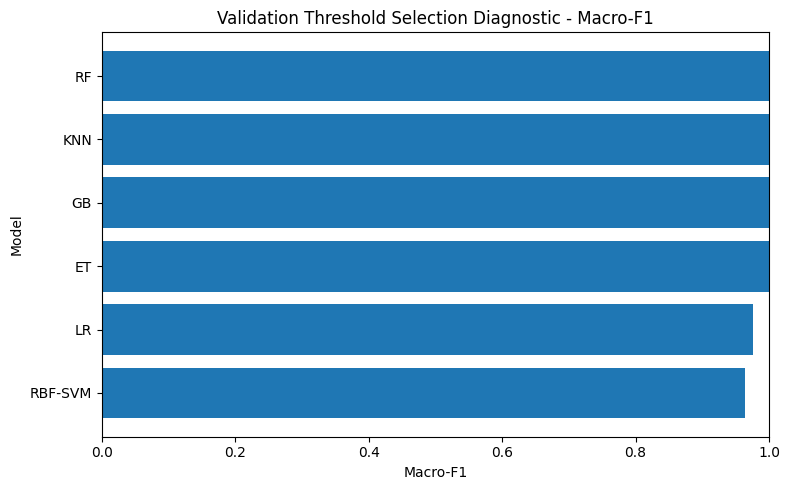

Validation threshold diagnostic grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/validation_threshold_selection_macro_f1.png


In [34]:
# =========================
# HÜCRE 33: Validation Threshold Diagnostic Grafiği
# =========================

plot_df = validation_results_df.sort_values(by="Macro-F1", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Model"], plot_df["Macro-F1"])
plt.title("Validation Threshold Selection Diagnostic - Macro-F1")
plt.xlabel("Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()

validation_threshold_fig_path = os.path.join(FIGURE_DIR, "validation_threshold_selection_macro_f1.png")
plt.savefig(validation_threshold_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Validation threshold diagnostic grafiği kaydedildi:")
print(validation_threshold_fig_path)

## 34. Final Test Değerlendirmesi İçin ECE-10 ve Genişletilmiş Metrik Fonksiyonunun Tanımlanması

Bu bölümde final test değerlendirmesinde kullanılacak genişletilmiş metrik fonksiyonu tanımlanacaktır.

Önceki metriklere ek olarak ECE-10 (Expected Calibration Error) hesaplanacaktır.  
ECE-10, modelin verdiği olasılıkların kalibrasyon kalitesini 10 eşit olasılık aralığı üzerinden ölçer.

Final değerlendirmede kullanılacak metrikler:

- Accuracy
- Precision
- Recall
- F1-score
- Macro-F1
- Balanced Accuracy
- ROC-AUC
- PR-AUC
- Brier Score
- ECE-10

In [35]:
# =========================
# HÜCRE 34: ECE-10 ve Final Metrik Fonksiyonu
# =========================

def expected_calibration_error(y_true, y_proba, n_bins=10):
    """
    Expected Calibration Error hesaplar.
    Binary classification için pozitif sınıf olasılığı kullanılır.
    """

    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            bin_mask = (y_proba >= lower) & (y_proba <= upper)
        else:
            bin_mask = (y_proba >= lower) & (y_proba < upper)

        bin_count = np.sum(bin_mask)

        if bin_count > 0:
            bin_accuracy = np.mean(y_true[bin_mask])
            bin_confidence = np.mean(y_proba[bin_mask])
            bin_weight = bin_count / len(y_true)

            ece += bin_weight * abs(bin_accuracy - bin_confidence)

    return ece


def evaluate_final_binary_classification(y_true, y_pred, y_proba):
    """
    Final test değerlendirmesi için genişletilmiş metrik fonksiyonu.
    Pozitif sınıf: Papilödem = 1
    """

    metrics = evaluate_binary_classification(
        y_true=y_true,
        y_pred=y_pred,
        y_proba=y_proba
    )

    metrics["ECE-10"] = expected_calibration_error(
        y_true=y_true,
        y_proba=y_proba,
        n_bins=10
    )

    return metrics

print("ECE-10 ve final metrik fonksiyonu hazır.")

ECE-10 ve final metrik fonksiyonu hazır.


## 35. Soft Voting Ensemble İçin Validation Threshold Seçimi

Bu bölümde ödevde istenen soft voting ensemble modeli için validation seti üzerinde karar eşiği seçilecektir.

Ensemble modeli aşağıdaki üç modelin kalibre edilmiş olasılıklarının ortalamasıyla oluşturulacaktır:

- Random Forest
- Extra Trees
- Gradient Boosting

Bu aşamada validation set yalnızca threshold seçimi için kullanılacaktır.  
Test seti kullanılmayacaktır.

In [36]:
# =========================
# HÜCRE 35: RF + ET + GB Soft Voting Ensemble Threshold Seçimi
# =========================

ENSEMBLE_MODELS = ["RF", "ET", "GB"]

# H38'de train-only pipeline ile üretilmiş validation calibrated probability değerlerini kullanıyoruz.
ensemble_val_proba = np.mean(
    [
        validation_prediction_store[model_name]["val_calibrated_proba"]
        for model_name in ENSEMBLE_MODELS
    ],
    axis=0
)

ensemble_threshold, ensemble_threshold_df = optimize_threshold_on_validation(
    y_true=y_val,
    y_proba=ensemble_val_proba,
    step=0.01
)

ensemble_val_pred = predict_pipeline_label_from_threshold(
    ensemble_val_proba,
    threshold=ensemble_threshold
)

ensemble_val_metrics = evaluate_final_binary_classification(
    y_true=y_val,
    y_pred=ensemble_val_pred,
    y_proba=ensemble_val_proba
)

print("Soft Voting Ensemble validation threshold:", ensemble_threshold)
print("\nSoft Voting Ensemble validation diagnostic metrikleri:")
for key, value in ensemble_val_metrics.items():
    print(f"{key}: {value:.6f}")

ensemble_threshold_path = os.path.join(OUTPUT_DIR, "ensemble_validation_threshold_search.csv")
ensemble_threshold_df.to_csv(ensemble_threshold_path, index=False)

print("\nEnsemble threshold arama tablosu kaydedildi:")
print(ensemble_threshold_path)

Soft Voting Ensemble validation threshold: 0.4000000000000001

Soft Voting Ensemble validation diagnostic metrikleri:
Accuracy: 1.000000
Precision: 1.000000
Recall: 1.000000
F1-score: 1.000000
Macro-F1: 1.000000
Balanced Accuracy: 1.000000
ROC-AUC: 1.000000
PR-AUC: 1.000000
Brier Score: 0.015407
ECE-10: 0.090336

Ensemble threshold arama tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/ensemble_validation_threshold_search.csv


## 36. Train ve Validation Setlerinin Birleştirilmesiyle Final Model Eğitimi

Bu bölümde model geliştirme süreci tamamlandıktan sonra train ve validation setleri birleştirilecektir.

Final model eğitiminde `train + validation` verisi kullanılacaktır.  
Bağımsız test seti hâlâ ayrı tutulacak ve yalnızca final değerlendirmede kullanılacaktır.

Her model için:

1. Train + validation içinde OOF calibration olasılıkları üretilecektir.
2. Sigmoid calibrator bu OOF olasılıklar üzerinde fit edilecektir.
3. Final preprocessing + MRMR + model pipeline'ı train + validation setinin tamamı üzerinde eğitilecektir.

Validation aşamasında seçilen threshold değerleri sabit tutulacaktır.

In [37]:
# =========================
# HÜCRE 36: Final Train+Validation Model Eğitimi
# =========================

dev_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

print("Final development veri boyutu:", dev_df.shape)
print("Final development hasta/grup sayısı:", dev_df["group_id"].nunique())

print("\nFinal development sınıf dağılımı:")
print(dev_df["class_name"].value_counts())

final_dev_pipelines = {}
final_dev_calibrators = {}
final_dev_oof_records = []

for model_name, study in final_optuna_studies.items():
    print("\n" + "=" * 80)
    print(f"Final development pipeline eğitiliyor: {model_name}")
    print("=" * 80)

    best_params = study.best_params

    # 1. Train+validation üzerinde OOF calibration
    final_calibrator, final_oof_proba_raw = fit_oof_sigmoid_calibrator(
        train_data=dev_df,
        feature_columns=feature_cols,
        model_name=model_name,
        best_params=best_params,
        n_splits=INNER_CV_SPLITS,
        random_state=RANDOM_STATE
    )

    final_dev_calibrators[model_name] = final_calibrator

    y_dev = dev_df["target"].astype(int).values
    final_oof_proba_calibrated = final_calibrator.predict_proba(final_oof_proba_raw)
    final_oof_pred_05 = (final_oof_proba_calibrated >= 0.5).astype(int)

    final_oof_metrics = evaluate_final_binary_classification(
        y_true=y_dev,
        y_pred=final_oof_pred_05,
        y_proba=final_oof_proba_calibrated
    )

    final_oof_metrics["Model"] = model_name
    final_oof_metrics["N MRMR Features"] = best_params["n_mrmr_features"]

    final_dev_oof_records.append(final_oof_metrics)

    # 2. Final pipeline train+validation tamamında fit edilir
    final_pipeline = fit_model_pipeline(
        train_data=dev_df,
        feature_columns=feature_cols,
        model_name=model_name,
        best_params=best_params
    )

    final_dev_pipelines[model_name] = final_pipeline

    print("Final development OOF Macro-F1 @0.5:", final_oof_metrics["Macro-F1"])
    print("Final development OOF ROC-AUC:", final_oof_metrics["ROC-AUC"])
    print("MRMR özellik sayısı:", best_params["n_mrmr_features"])

final_dev_oof_df = pd.DataFrame(final_dev_oof_records)

final_dev_oof_df = final_dev_oof_df[
    [
        "Model",
        "N MRMR Features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Macro-F1",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "ECE-10"
    ]
].sort_values(by="Macro-F1", ascending=False).reset_index(drop=True)

print("\nFinal development OOF diagnostic sonuçları:")
display(final_dev_oof_df)

final_dev_oof_path = os.path.join(OUTPUT_DIR, "final_development_oof_diagnostics.csv")
final_dev_oof_df.to_csv(final_dev_oof_path, index=False)

print("\nFinal development OOF diagnostic tablosu kaydedildi:")
print(final_dev_oof_path)

Final development veri boyutu: (770, 751)
Final development hasta/grup sayısı: 55

Final development sınıf dağılımı:
class_name
Normal       532
Papilodem    238
Name: count, dtype: int64

Final development pipeline eğitiliyor: LR
  Calibration OOF fold 1/5
  Calibration OOF fold 2/5
  Calibration OOF fold 3/5
  Calibration OOF fold 4/5
  Calibration OOF fold 5/5
Final development OOF Macro-F1 @0.5: 0.8560281212604707
Final development OOF ROC-AUC: 0.8807417703923675
MRMR özellik sayısı: 50

Final development pipeline eğitiliyor: RBF-SVM
  Calibration OOF fold 1/5
  Calibration OOF fold 2/5
  Calibration OOF fold 3/5
  Calibration OOF fold 4/5
  Calibration OOF fold 5/5
Final development OOF Macro-F1 @0.5: 0.8979591836734694
Final development OOF ROC-AUC: 0.9233035319390914
MRMR özellik sayısı: 20

Final development pipeline eğitiliyor: RF
  Calibration OOF fold 1/5
  Calibration OOF fold 2/5
  Calibration OOF fold 3/5
  Calibration OOF fold 4/5
  Calibration OOF fold 5/5
Final develop

,Model,N MRMR Features,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10
0,RBF-SVM,20,0.914286,0.883929,0.831933,0.857143,0.897959,0.891530,0.923304,0.904764,0.075222,0.049639
1,KNN,40,0.909091,0.971910,0.726891,0.831731,0.884727,0.858746,0.921937,0.897573,0.078198,0.071974
2,ET,20,0.905195,0.918782,0.760504,0.832184,0.883060,0.865215,0.932252,0.918116,0.071496,0.022921
3,GB,20,0.903896,0.898058,0.777311,0.833333,0.882908,0.868919,0.918494,0.908304,0.077176,0.046639
4,RF,20,0.903896,0.914141,0.760504,0.830275,0.881623,0.864275,0.921657,0.910989,0.074867,0.037927
5,LR,50,0.883117,0.873737,0.726891,0.793578,0.856028,0.839949,0.880742,0.865682,0.097136,0.052847



Final development OOF diagnostic tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/final_development_oof_diagnostics.csv


## 37. Bağımsız Test Setinde Final Model Değerlendirmesi

Bu bölümde final modeller bağımsız test seti üzerinde değerlendirilecektir.

Test seti daha önce hiçbir aşamada preprocessing fit, MRMR seçim, Optuna optimizasyonu, calibration veya threshold seçimi için kullanılmamıştır.

Bu nedenle bu bölümde elde edilen sonuçlar çalışmanın ana final performans sonuçlarıdır.

Ayrıca RF, ET ve GB modellerinden oluşan soft voting ensemble da aynı test setinde değerlendirilecektir.

In [38]:
# =========================
# HÜCRE 37: Independent Test Set Final Evaluation
# =========================

test_prediction_store = {}
test_results = []

for model_name, pipeline in final_dev_pipelines.items():
    print("\n" + "=" * 80)
    print(f"Independent test değerlendirmesi: {model_name}")
    print("=" * 80)

    # 1. Test üzerinde raw probability
    y_test_proba_raw = predict_pipeline_proba(
        pipeline=pipeline,
        data=test_df,
        feature_columns=feature_cols
    )

    # 2. Train+validation OOF ile fit edilmiş calibrator uygulanır
    y_test_proba_calibrated = final_dev_calibrators[model_name].predict_proba(
        y_test_proba_raw
    )

    # 3. Validation aşamasında seçilen threshold uygulanır
    threshold = model_thresholds[model_name]

    y_test_pred = predict_pipeline_label_from_threshold(
        y_test_proba_calibrated,
        threshold=threshold
    )

    # 4. Test metrikleri
    metrics = evaluate_final_binary_classification(
        y_true=y_test,
        y_pred=y_test_pred,
        y_proba=y_test_proba_calibrated
    )

    metrics["Model"] = model_name
    metrics["Threshold"] = threshold
    metrics["N MRMR Features"] = pipeline["n_mrmr_features"]
    metrics["Best Inner CV Macro-F1"] = final_optuna_studies[model_name].best_value

    test_results.append(metrics)

    test_prediction_store[model_name] = {
        "raw_proba": y_test_proba_raw,
        "calibrated_proba": y_test_proba_calibrated,
        "pred": y_test_pred,
        "threshold": threshold
    }

    print("Threshold:", threshold)
    print("Test Macro-F1:", metrics["Macro-F1"])
    print("Test ROC-AUC:", metrics["ROC-AUC"])
    print("Test PR-AUC:", metrics["PR-AUC"])

# Soft Voting Ensemble test değerlendirmesi
ensemble_test_proba = np.mean(
    [
        test_prediction_store[model_name]["calibrated_proba"]
        for model_name in ENSEMBLE_MODELS
    ],
    axis=0
)

ensemble_test_pred = predict_pipeline_label_from_threshold(
    ensemble_test_proba,
    threshold=ensemble_threshold
)

ensemble_test_metrics = evaluate_final_binary_classification(
    y_true=y_test,
    y_pred=ensemble_test_pred,
    y_proba=ensemble_test_proba
)

ensemble_test_metrics["Model"] = "Soft Voting Ensemble"
ensemble_test_metrics["Threshold"] = ensemble_threshold
ensemble_test_metrics["N MRMR Features"] = "RF+ET+GB"
ensemble_test_metrics["Best Inner CV Macro-F1"] = np.nan

test_results.append(ensemble_test_metrics)

test_prediction_store["Soft Voting Ensemble"] = {
    "calibrated_proba": ensemble_test_proba,
    "pred": ensemble_test_pred,
    "threshold": ensemble_threshold
}

test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df[
    [
        "Model",
        "Best Inner CV Macro-F1",
        "N MRMR Features",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Macro-F1",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "ECE-10"
    ]
].sort_values(by="Macro-F1", ascending=False).reset_index(drop=True)

print("\nFINAL independent test sonuçları:")
display(test_results_df)

test_results_path = os.path.join(OUTPUT_DIR, "final_independent_test_results.csv")
test_results_df.to_csv(test_results_path, index=False)

print("\nFinal test sonuç tablosu kaydedildi:")
print(test_results_path)


Independent test değerlendirmesi: LR
Threshold: 0.5400000000000001
Test Macro-F1: 0.9873629916183108
Test ROC-AUC: 0.9994897959183673
Test PR-AUC: 0.9988095238095238

Independent test değerlendirmesi: RBF-SVM
Threshold: 0.4800000000000001
Test Macro-F1: 0.9616588419405321
Test ROC-AUC: 0.9950255102040816
Test PR-AUC: 0.9901410427451887

Independent test değerlendirmesi: RF
Threshold: 0.4000000000000001
Test Macro-F1: 0.9072346179851252
Test ROC-AUC: 0.9840561224489797
Test PR-AUC: 0.9694530231137315

Independent test değerlendirmesi: ET
Threshold: 0.4000000000000001
Test Macro-F1: 0.9476495726495726
Test ROC-AUC: 0.9900510204081632
Test PR-AUC: 0.9812382229589874

Independent test değerlendirmesi: GB
Threshold: 0.5600000000000002
Test Macro-F1: 0.9133067945969855
Test ROC-AUC: 0.9844387755102041
Test PR-AUC: 0.9686030345415821

Independent test değerlendirmesi: KNN
Threshold: 0.4000000000000001
Test Macro-F1: 0.9544715447154472
Test ROC-AUC: 0.9548469387755102
Test PR-AUC: 0.940689737

,Model,Best Inner CV Macro-F1,N MRMR Features,Threshold,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10
0,LR,0.853445,50,0.54,0.989796,1.000000,0.964286,0.981818,0.987363,0.982143,0.999490,0.998810,0.031966,0.133379
1,RBF-SVM,0.870174,20,0.48,0.969388,0.980769,0.910714,0.944444,0.961659,0.951786,0.995026,0.990141,0.027744,0.072334
2,KNN,0.868748,40,0.40,0.964286,1.000000,0.875000,0.933333,0.954472,0.937500,0.954847,0.940690,0.048220,0.057742
3,ET,0.869030,20,0.40,0.959184,1.000000,0.857143,0.923077,0.947650,0.928571,0.990051,0.981238,0.038414,0.057238
4,Soft Voting Ensemble,NaN,RF+ET+GB,0.40,0.954082,0.979592,0.857143,0.914286,0.941463,0.925000,0.986735,0.974065,0.042628,0.060946
5,GB,0.876523,20,0.56,0.933673,0.977778,0.785714,0.871287,0.913307,0.889286,0.984439,0.968603,0.045701,0.060290
6,RF,0.864311,20,0.40,0.928571,0.956522,0.785714,0.862745,0.907235,0.885714,0.984056,0.969453,0.046700,0.059758



Final test sonuç tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/final_independent_test_results.csv


## 38. Final Test Sonuçlarının Macro-F1 Grafiği

Bu bölümde bağımsız test seti üzerindeki final Macro-F1 sonuçları görselleştirilecektir.

Bu grafik, çalışmanın ana model karşılaştırma grafiklerinden biridir.

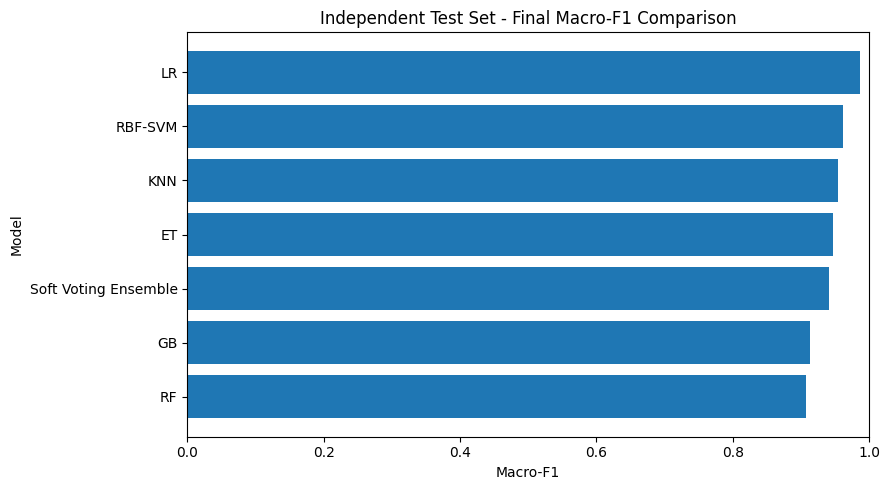

Final test Macro-F1 grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_macro_f1_comparison.png


In [39]:
# =========================
# HÜCRE 38: Final Test Macro-F1 Model Karşılaştırma Grafiği
# =========================

plot_df = test_results_df.sort_values(by="Macro-F1", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["Macro-F1"])
plt.title("Independent Test Set - Final Macro-F1 Comparison")
plt.xlabel("Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()

final_test_macro_f1_fig_path = os.path.join(FIGURE_DIR, "final_test_macro_f1_comparison.png")
plt.savefig(final_test_macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Final test Macro-F1 grafiği kaydedildi:")
print(final_test_macro_f1_fig_path)

## 39. Final Test ROC Eğrilerinin Oluşturulması

Bu bölümde bağımsız test seti üzerinde tüm modellerin ROC eğrileri çizilecektir.

ROC eğrisi, modelin farklı karar eşiklerinde pozitif sınıfı negatif sınıftan ayırma başarısını gösterir. ROC-AUC değerinin 1'e yaklaşması modelin ayırt ediciliğinin arttığını ifade eder.

Bu grafik final test değerlendirmesine ait olduğu için çalışmanın ana görsel sonuçlarından biridir.

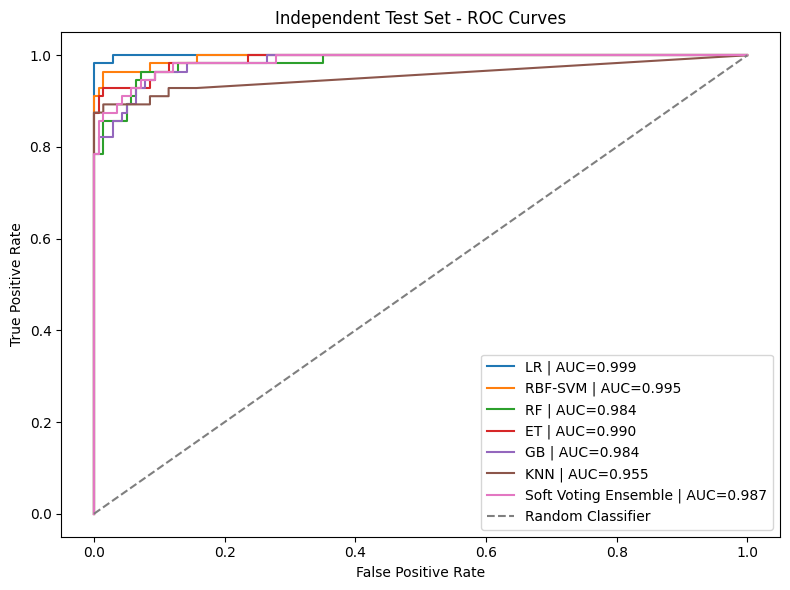

Final ROC eğrileri kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_roc_curves.png


In [40]:
# =========================
# HÜCRE 39: Final Test ROC Curves
# =========================

plt.figure(figsize=(8, 6))

for model_name, pred_info in test_prediction_store.items():
    y_score = pred_info["calibrated_proba"]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, label=f"{model_name} | AUC={auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("Independent Test Set - ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

final_roc_fig_path = os.path.join(FIGURE_DIR, "final_test_roc_curves.png")
plt.savefig(final_roc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Final ROC eğrileri kaydedildi:")
print(final_roc_fig_path)

## 40. Final Test Precision-Recall Eğrilerinin Oluşturulması

Bu bölümde bağımsız test seti üzerinde tüm modeller için Precision-Recall eğrileri çizilecektir.

Precision-Recall eğrisi özellikle sınıf dengesizliği bulunan veri setlerinde önemlidir. Bu çalışmada papilödem sınıfı normal sınıfa göre daha az örneğe sahip olduğu için PR-AUC değeri ROC-AUC ile birlikte yorumlanacaktır.

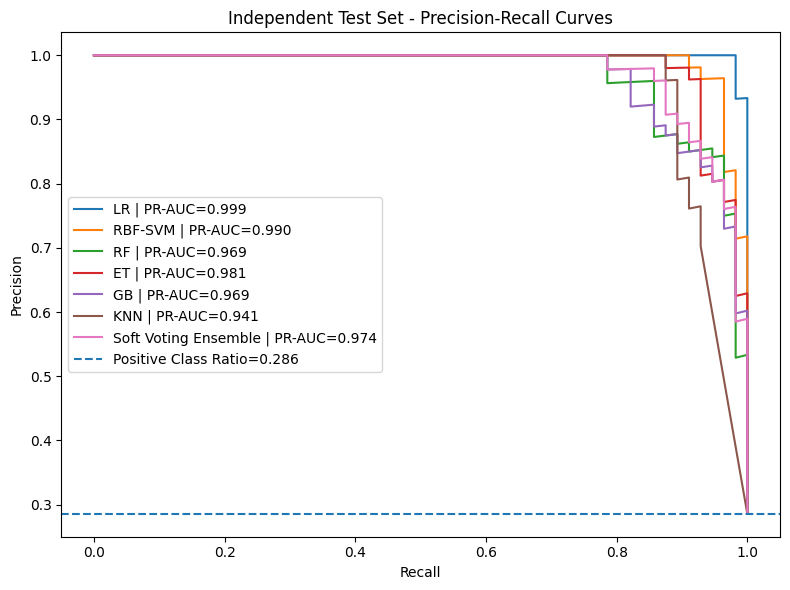

Final Precision-Recall eğrileri kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_precision_recall_curves.png


In [41]:
# =========================
# HÜCRE 40: Final Test Precision-Recall Curves
# =========================

plt.figure(figsize=(8, 6))

for model_name, pred_info in test_prediction_store.items():
    y_score = pred_info["calibrated_proba"]

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc_value = average_precision_score(y_test, y_score)

    plt.plot(recall, precision, label=f"{model_name} | PR-AUC={pr_auc_value:.3f}")

positive_ratio = np.mean(y_test)
plt.axhline(y=positive_ratio, linestyle="--", label=f"Positive Class Ratio={positive_ratio:.3f}")

plt.title("Independent Test Set - Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()

final_pr_fig_path = os.path.join(FIGURE_DIR, "final_test_precision_recall_curves.png")
plt.savefig(final_pr_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Final Precision-Recall eğrileri kaydedildi:")
print(final_pr_fig_path)

## 41. En Başarılı Final Model İçin Confusion Matrix

Bu bölümde bağımsız test setinde en yüksek Macro-F1 skorunu veren modelin confusion matrix grafiği oluşturulacaktır.

Confusion matrix, modelin Normal ve Papilödem sınıflarında yaptığı doğru ve hatalı tahminleri göstermektedir.

Bu çalışmada en iyi model test seti üzerinde en yüksek Macro-F1 değerine göre seçilecektir.

En başarılı final model: LR

Confusion Matrix:
[[140   0]
 [  2  54]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       140
   Papilodem       1.00      0.96      0.98        56

    accuracy                           0.99       196
   macro avg       0.99      0.98      0.99       196
weighted avg       0.99      0.99      0.99       196



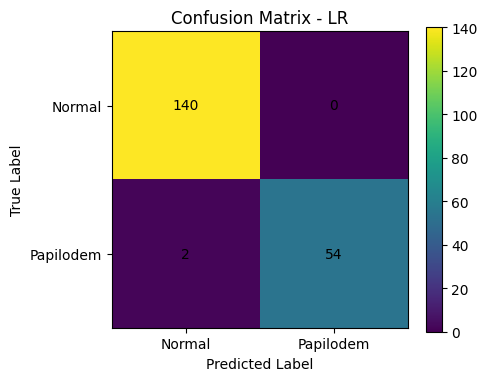

Final confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/final_confusion_matrix_LR.png


In [42]:
# =========================
# HÜCRE 41: Best Final Model Confusion Matrix
# =========================

best_final_model_name = test_results_df.iloc[0]["Model"]

best_test_pred = test_prediction_store[best_final_model_name]["pred"]
best_test_proba = test_prediction_store[best_final_model_name]["calibrated_proba"]

cm = confusion_matrix(y_test, best_test_pred)

print("En başarılı final model:", best_final_model_name)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    best_test_pred,
    target_names=["Normal", "Papilodem"],
    zero_division=0
))

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_final_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Normal", "Papilodem"])
plt.yticks([0, 1], ["Normal", "Papilodem"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

best_cm_fig_path = os.path.join(FIGURE_DIR, f"final_confusion_matrix_{best_final_model_name}.png")
plt.savefig(best_cm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Final confusion matrix grafiği kaydedildi:")
print(best_cm_fig_path)

## 42. Final Test Calibration Curve

Bu bölümde final modellerin kalibrasyon eğrileri çizilecektir.

Calibration curve, modelin tahmin ettiği olasılık değerleri ile gerçek pozitif sınıf oranları arasındaki uyumu gösterir. İdeal durumda eğri diyagonal çizgiye yakın olur.

Bu grafik, sigmoid calibration işleminin model olasılıklarını ne kadar güvenilir hale getirdiğini yorumlamak için kullanılacaktır.

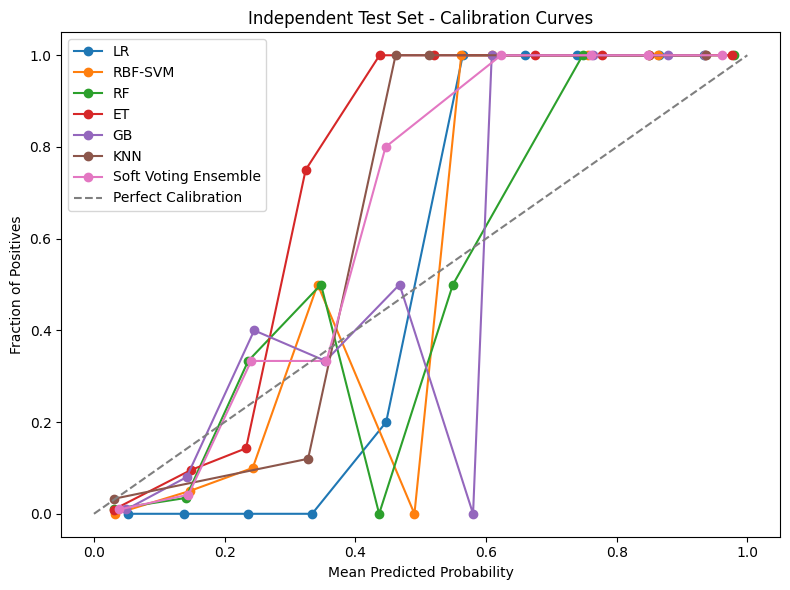

Calibration curve grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_calibration_curves.png


In [43]:
# =========================
# HÜCRE 42: Final Test Calibration Curves
# =========================

from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 6))

for model_name, pred_info in test_prediction_store.items():
    y_score = pred_info["calibrated_proba"]

    prob_true, prob_pred = calibration_curve(
        y_test,
        y_score,
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(prob_pred, prob_true, marker="o", label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.title("Independent Test Set - Calibration Curves")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.tight_layout()

calibration_fig_path = os.path.join(FIGURE_DIR, "final_test_calibration_curves.png")
plt.savefig(calibration_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Calibration curve grafiği kaydedildi:")
print(calibration_fig_path)

## 43. Final Model Karşılaştırma Grafikleri

Bu bölümde bağımsız test seti üzerinde modellerin temel performans metrikleri karşılaştırılacaktır.

Karşılaştırılacak metrikler:

- Macro-F1
- ROC-AUC
- PR-AUC
- Balanced Accuracy

Bu grafikler raporda model karşılaştırma bölümünde kullanılacaktır.

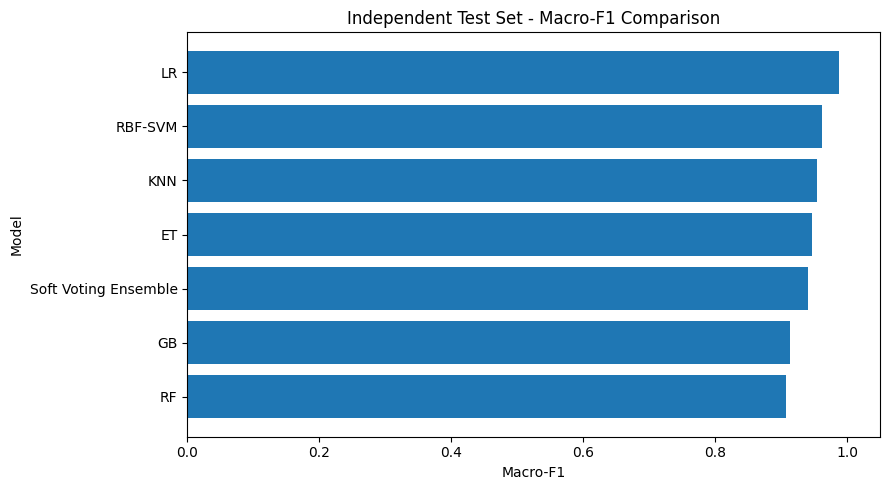

Macro-F1 grafiği kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_macro_f1_comparison.png


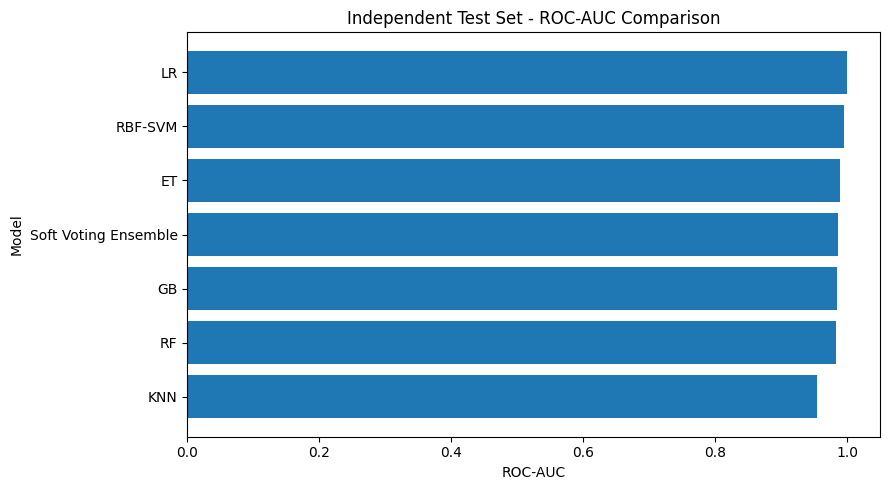

ROC-AUC grafiği kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_roc_auc_comparison.png


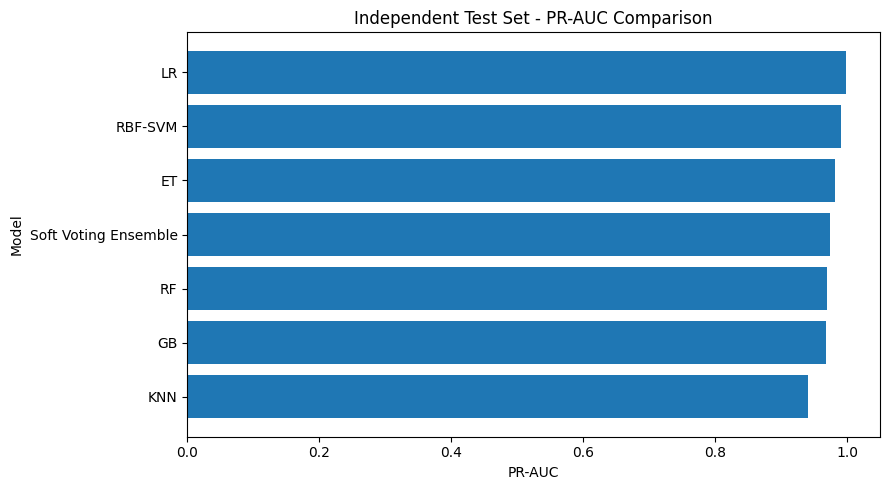

PR-AUC grafiği kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_pr_auc_comparison.png


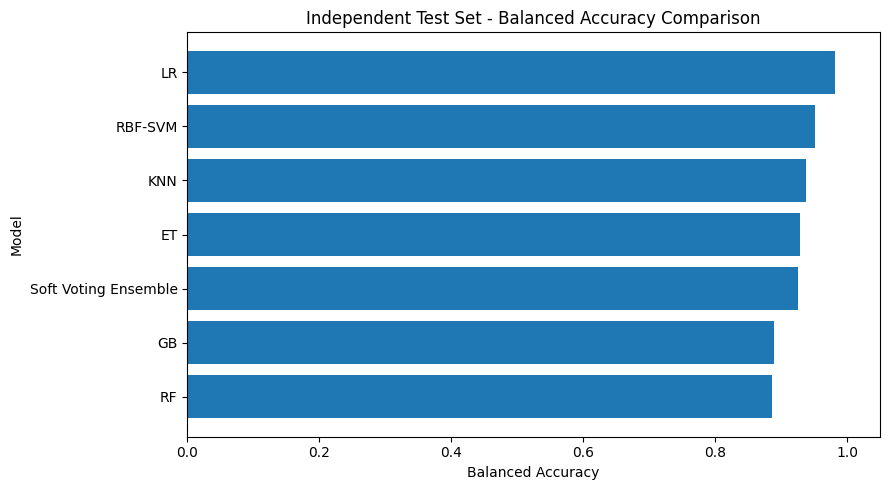

Balanced Accuracy grafiği kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/final_test_balanced_accuracy_comparison.png


In [44]:
# =========================
# HÜCRE 43: Final Model Comparison Charts
# =========================

comparison_metrics = ["Macro-F1", "ROC-AUC", "PR-AUC", "Balanced Accuracy"]

for metric in comparison_metrics:
    plot_df = test_results_df.sort_values(by=metric, ascending=True)

    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["Model"], plot_df[metric])
    plt.title(f"Independent Test Set - {metric} Comparison")
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.xlim(0, 1.05)
    plt.tight_layout()

    metric_file_name = metric.lower().replace("-", "_").replace(" ", "_")
    fig_path = os.path.join(FIGURE_DIR, f"final_test_{metric_file_name}_comparison.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{metric} grafiği kaydedildi:", fig_path)

## 44. En Başarılı Model İçin Permutation Feature Importance

Bu bölümde bağımsız test seti üzerinde en başarılı model için permutation feature importance analizi yapılacaktır.

RBF-SVM gibi kernel tabanlı modellerde doğrudan katsayı temelli feature importance elde edilemez. Bu nedenle modelden bağımsız bir yöntem olan permutation importance kullanılacaktır.

Permutation importance, her bir seçilmiş özelliğin değerleri karıştırıldığında model performansının ne kadar düştüğünü ölçer. Performans düşüşü yüksek olan özellikler model için daha önemli kabul edilir.

En başarılı model: LR

İlk 20 önemli özellik:


,feature,importance_mean,importance_std
0,Feature_0409,0.385547,0.034390
1,Feature_0088,0.316026,0.025968
2,Feature_0028,0.311822,0.025082
3,Feature_0453,0.226088,0.015833
4,Feature_0644,0.206901,0.028052
5,Feature_0456,0.161000,0.017167
6,Feature_0085,0.141357,0.018566
7,Feature_0003,0.126217,0.016966
8,Feature_0084,0.116408,0.020654
9,Feature_0408,0.102669,0.016272


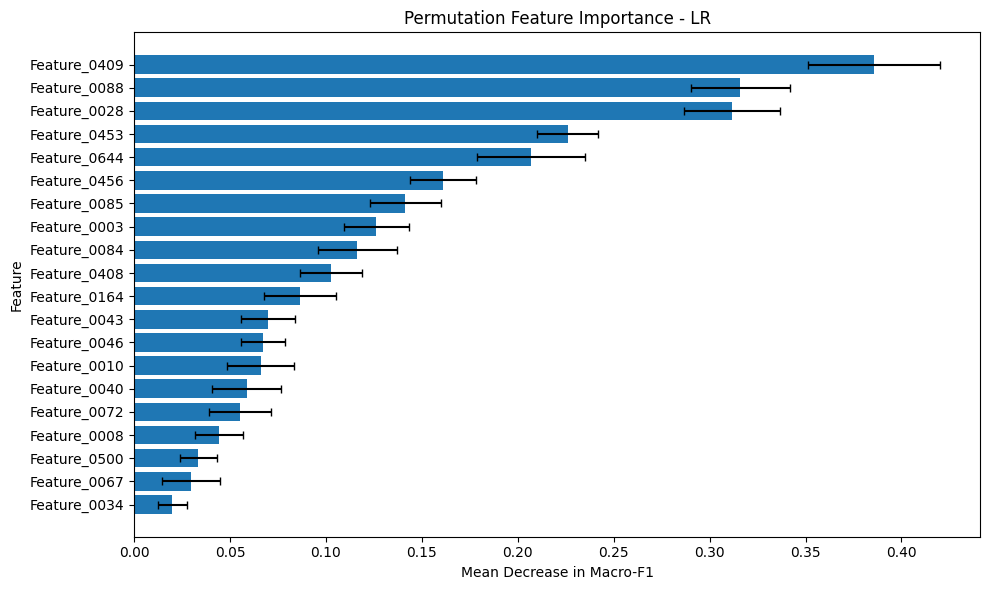

Feature importance tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/permutation_feature_importance_LR.csv

Feature importance grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/permutation_feature_importance_LR.png


In [45]:
# =========================
# HÜCRE 44: Permutation Feature Importance for Best Final Model
# =========================

from sklearn.inspection import permutation_importance

best_pipeline = final_dev_pipelines[best_final_model_name]
best_model = best_pipeline["model"]
best_selected_features = best_pipeline["selected_features"]

# Test setini best modelin kendi preprocessing ve MRMR feature setine dönüştürüyoruz
X_test_prep_best = best_pipeline["preprocessor"].transform(test_df[feature_cols])
X_test_selected_best = X_test_prep_best[best_selected_features]

perm_result = permutation_importance(
    best_model,
    X_test_selected_best,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "feature": best_selected_features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False).reset_index(drop=True)

print("En başarılı model:", best_final_model_name)
print("\nİlk 20 önemli özellik:")
display(feature_importance_df.head(20))

feature_importance_path = os.path.join(
    OUTPUT_DIR,
    f"permutation_feature_importance_{best_final_model_name}.csv"
)
feature_importance_df.to_csv(feature_importance_path, index=False)

top_importance_df = feature_importance_df.head(20).sort_values(by="importance_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_importance_df["feature"],
    top_importance_df["importance_mean"],
    xerr=top_importance_df["importance_std"],
    capsize=3
)

plt.title(f"Permutation Feature Importance - {best_final_model_name}")
plt.xlabel("Mean Decrease in Macro-F1")
plt.ylabel("Feature")
plt.tight_layout()

feature_importance_fig_path = os.path.join(
    FIGURE_DIR,
    f"permutation_feature_importance_{best_final_model_name}.png"
)
plt.savefig(feature_importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Feature importance tablosu kaydedildi:")
print(feature_importance_path)

print("\nFeature importance grafiği kaydedildi:")
print(feature_importance_fig_path)

## 45. Patient-Level Aggregation Fonksiyonlarının Tanımlanması

Bu bölümde örnek/ROI seviyesindeki tahminler hasta/grup seviyesine dönüştürülecektir.

Radyomik veri setinde aynı hastaya ait birden fazla örnek bulunabildiği için yalnızca sample-level değerlendirme yeterli değildir. Bu nedenle her `group_id` için olasılıklar birleştirilerek patient-level tahmin üretilecektir.

Denenecek aggregation stratejileri:

- Mean probability
- Max probability
- 90th percentile probability
- Top-3 mean probability
- Confidence-weighted probability
- Majority vote

Aggregation stratejisi validation set üzerinde seçilecek, bağımsız test setine yalnızca seçilen strateji uygulanacaktır.

In [46]:
# =========================
# HÜCRE 45: Patient-Level Aggregation Fonksiyonları
# =========================

def aggregate_group_probability(probabilities, threshold, strategy="mean_proba"):
    probabilities = np.asarray(probabilities)

    if strategy == "mean_proba":
        return float(np.mean(probabilities))

    elif strategy == "max_proba":
        return float(np.max(probabilities))

    elif strategy == "p90_proba":
        return float(np.percentile(probabilities, 90))

    elif strategy == "top3_mean":
        sorted_probs = np.sort(probabilities)[::-1]
        top_k = sorted_probs[:min(3, len(sorted_probs))]
        return float(np.mean(top_k))

    elif strategy == "confidence_weighted":
        weights = np.abs(probabilities - 0.5) * 2
        weights = weights + 1e-6
        return float(np.average(probabilities, weights=weights))

    elif strategy == "entropy_weighted":
        eps = 1e-6
        p = np.clip(probabilities, eps, 1 - eps)
        entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
        weights = 1 - (entropy / np.log(2))
        weights = weights + 1e-6
        return float(np.average(probabilities, weights=weights))

    elif strategy == "majority_vote":
        sample_preds = (probabilities >= threshold).astype(int)
        return float(np.mean(sample_preds))

    else:
        raise ValueError(f"Bilinmeyen aggregation stratejisi: {strategy}")


def create_patient_level_predictions(data_df, y_proba, threshold, strategy):
    temp_df = data_df[["group_id", "target", "class_name"]].copy()
    temp_df["proba"] = np.asarray(y_proba)

    patient_records = []

    for group_id, group_data in temp_df.groupby("group_id"):
        group_probs = group_data["proba"].values

        group_proba = aggregate_group_probability(
            probabilities=group_probs,
            threshold=threshold,
            strategy=strategy
        )

        if strategy == "majority_vote":
            group_pred = int(group_proba >= 0.5)
        else:
            group_pred = int(group_proba >= threshold)

        patient_records.append({
            "group_id": group_id,
            "target": int(group_data["target"].iloc[0]),
            "class_name": group_data["class_name"].iloc[0],
            "sample_count": group_data.shape[0],
            "patient_proba": group_proba,
            "patient_pred": group_pred,
            "aggregation_strategy": strategy
        })

    patient_pred_df = pd.DataFrame(patient_records)

    return patient_pred_df


def evaluate_patient_level(data_df, y_proba, threshold, strategy):
    patient_pred_df = create_patient_level_predictions(
        data_df=data_df,
        y_proba=y_proba,
        threshold=threshold,
        strategy=strategy
    )

    y_true_patient = patient_pred_df["target"].values
    y_pred_patient = patient_pred_df["patient_pred"].values
    y_proba_patient = patient_pred_df["patient_proba"].values

    metrics = evaluate_final_binary_classification(
        y_true=y_true_patient,
        y_pred=y_pred_patient,
        y_proba=y_proba_patient
    )

    return metrics, patient_pred_df


AGGREGATION_STRATEGIES = [
    "mean_proba",
    "max_proba",
    "p90_proba",
    "top3_mean",
    "confidence_weighted",
    "entropy_weighted",
    "majority_vote"
]

print("Patient-level aggregation fonksiyonları hazır.")
print("Denenen stratejiler:", AGGREGATION_STRATEGIES)

Patient-level aggregation fonksiyonları hazır.
Denenen stratejiler: ['mean_proba', 'max_proba', 'p90_proba', 'top3_mean', 'confidence_weighted', 'entropy_weighted', 'majority_vote']


## 46. Validation Set Üzerinde Patient-Level Aggregation Stratejisi Seçimi

Bu bölümde her model için validation set üzerinde en iyi patient-level aggregation stratejisi seçilecektir.

Her model için farklı aggregation stratejileri denenerek patient-level Macro-F1 ve Balanced Accuracy skorları hesaplanacaktır.

Seçim validation set üzerinde yapılacak, bağımsız test seti bu aşamada kullanılmayacaktır.

In [47]:
# =========================
# HÜCRE 46: Validation Üzerinde Aggregation Stratejisi Seçimi
# =========================

aggregation_selection_records = []
selected_aggregation_strategies = {}

# Tekli modeller
for model_name in final_optuna_studies.keys():
    y_val_proba_model = validation_prediction_store[model_name]["val_calibrated_proba"]
    threshold_model = model_thresholds[model_name]

    for strategy in AGGREGATION_STRATEGIES:
        metrics, patient_df_temp = evaluate_patient_level(
            data_df=val_df,
            y_proba=y_val_proba_model,
            threshold=threshold_model,
            strategy=strategy
        )

        aggregation_selection_records.append({
            "Model": model_name,
            "Aggregation Strategy": strategy,
            "Threshold": threshold_model,
            "Patient Count": patient_df_temp.shape[0],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1-score": metrics["F1-score"],
            "Macro-F1": metrics["Macro-F1"],
            "Balanced Accuracy": metrics["Balanced Accuracy"],
            "ROC-AUC": metrics["ROC-AUC"],
            "PR-AUC": metrics["PR-AUC"],
            "Brier Score": metrics["Brier Score"],
            "ECE-10": metrics["ECE-10"]
        })

# Ensemble
for strategy in AGGREGATION_STRATEGIES:
    metrics, patient_df_temp = evaluate_patient_level(
        data_df=val_df,
        y_proba=ensemble_val_proba,
        threshold=ensemble_threshold,
        strategy=strategy
    )

    aggregation_selection_records.append({
        "Model": "Soft Voting Ensemble",
        "Aggregation Strategy": strategy,
        "Threshold": ensemble_threshold,
        "Patient Count": patient_df_temp.shape[0],
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-score": metrics["F1-score"],
        "Macro-F1": metrics["Macro-F1"],
        "Balanced Accuracy": metrics["Balanced Accuracy"],
        "ROC-AUC": metrics["ROC-AUC"],
        "PR-AUC": metrics["PR-AUC"],
        "Brier Score": metrics["Brier Score"],
        "ECE-10": metrics["ECE-10"]
    })

aggregation_selection_df = pd.DataFrame(aggregation_selection_records)

best_aggregation_rows = []

for model_name in aggregation_selection_df["Model"].unique():
    model_df = aggregation_selection_df[
        aggregation_selection_df["Model"] == model_name
    ].copy()

    best_row = model_df.sort_values(
        by=["Macro-F1", "Balanced Accuracy", "ROC-AUC"],
        ascending=False
    ).iloc[0]

    selected_aggregation_strategies[model_name] = best_row["Aggregation Strategy"]
    best_aggregation_rows.append(best_row)

best_aggregation_df = pd.DataFrame(best_aggregation_rows).reset_index(drop=True)

print("Validation üzerinde seçilen en iyi patient-level aggregation stratejileri:")
display(best_aggregation_df[
    [
        "Model",
        "Aggregation Strategy",
        "Threshold",
        "Patient Count",
        "Accuracy",
        "Macro-F1",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "ECE-10"
    ]
])

aggregation_selection_path = os.path.join(OUTPUT_DIR, "validation_patient_level_aggregation_selection.csv")
best_aggregation_path = os.path.join(OUTPUT_DIR, "best_patient_level_aggregation_strategies.csv")

aggregation_selection_df.to_csv(aggregation_selection_path, index=False)
best_aggregation_df.to_csv(best_aggregation_path, index=False)

print("\nTüm aggregation sonuçları kaydedildi:")
print(aggregation_selection_path)

print("\nSeçilen en iyi aggregation stratejileri kaydedildi:")
print(best_aggregation_path)

Validation üzerinde seçilen en iyi patient-level aggregation stratejileri:


,Model,Aggregation Strategy,Threshold,Patient Count,Accuracy,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10
0,LR,mean_proba,0.54,7,1.0,1.0,1.0,1.0,1.0,0.043989,0.194489
1,RBF-SVM,mean_proba,0.48,7,1.0,1.0,1.0,1.0,1.0,0.025549,0.141392
2,RF,mean_proba,0.40,7,1.0,1.0,1.0,1.0,1.0,0.010092,0.084963
3,ET,mean_proba,0.40,7,1.0,1.0,1.0,1.0,1.0,0.009871,0.082002
4,GB,mean_proba,0.56,7,1.0,1.0,1.0,1.0,1.0,0.011849,0.104043
5,KNN,mean_proba,0.40,7,1.0,1.0,1.0,1.0,1.0,0.011590,0.098964
6,Soft Voting Ensemble,mean_proba,0.40,7,1.0,1.0,1.0,1.0,1.0,0.010325,0.090336



Tüm aggregation sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/validation_patient_level_aggregation_selection.csv

Seçilen en iyi aggregation stratejileri kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/best_patient_level_aggregation_strategies.csv


## 47. Bağımsız Test Setinde Patient-Level Final Değerlendirme

Bu bölümde validation set üzerinde seçilen aggregation stratejileri bağımsız test setine uygulanacaktır.

Test seti yalnızca bu final değerlendirme aşamasında kullanılmaktadır.

Bu bölümde her model için patient-level metrikler hesaplanacak ve sample-level sonuçlarla birlikte yorumlanacaktır.

In [48]:
# =========================
# HÜCRE 47: Independent Test Patient-Level Evaluation
# =========================

patient_level_test_results = []
patient_level_prediction_store = {}

# Tekli modeller
for model_name in final_optuna_studies.keys():
    strategy = selected_aggregation_strategies[model_name]
    threshold = model_thresholds[model_name]
    y_test_proba_model = test_prediction_store[model_name]["calibrated_proba"]

    metrics, patient_pred_df = evaluate_patient_level(
        data_df=test_df,
        y_proba=y_test_proba_model,
        threshold=threshold,
        strategy=strategy
    )

    metrics["Model"] = model_name
    metrics["Aggregation Strategy"] = strategy
    metrics["Threshold"] = threshold
    metrics["Patient Count"] = patient_pred_df.shape[0]

    patient_level_test_results.append(metrics)
    patient_level_prediction_store[model_name] = patient_pred_df

    patient_output_path = os.path.join(OUTPUT_DIR, f"patient_level_test_predictions_{model_name}.csv")
    patient_pred_df.to_csv(patient_output_path, index=False)

# Ensemble
ensemble_strategy = selected_aggregation_strategies["Soft Voting Ensemble"]

ensemble_metrics, ensemble_patient_pred_df = evaluate_patient_level(
    data_df=test_df,
    y_proba=ensemble_test_proba,
    threshold=ensemble_threshold,
    strategy=ensemble_strategy
)

ensemble_metrics["Model"] = "Soft Voting Ensemble"
ensemble_metrics["Aggregation Strategy"] = ensemble_strategy
ensemble_metrics["Threshold"] = ensemble_threshold
ensemble_metrics["Patient Count"] = ensemble_patient_pred_df.shape[0]

patient_level_test_results.append(ensemble_metrics)
patient_level_prediction_store["Soft Voting Ensemble"] = ensemble_patient_pred_df

ensemble_patient_output_path = os.path.join(
    OUTPUT_DIR,
    "patient_level_test_predictions_soft_voting_ensemble.csv"
)
ensemble_patient_pred_df.to_csv(ensemble_patient_output_path, index=False)

patient_level_test_results_df = pd.DataFrame(patient_level_test_results)

patient_level_test_results_df = patient_level_test_results_df[
    [
        "Model",
        "Aggregation Strategy",
        "Threshold",
        "Patient Count",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Macro-F1",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "ECE-10"
    ]
].sort_values(by="Macro-F1", ascending=False).reset_index(drop=True)

print("FINAL patient-level independent test sonuçları:")
display(patient_level_test_results_df)

patient_level_results_path = os.path.join(OUTPUT_DIR, "final_patient_level_test_results.csv")
patient_level_test_results_df.to_csv(patient_level_results_path, index=False)

print("\nPatient-level final test sonuçları kaydedildi:")
print(patient_level_results_path)

FINAL patient-level independent test sonuçları:


,Model,Aggregation Strategy,Threshold,Patient Count,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10
0,LR,mean_proba,0.54,14,1.000000,1.0,1.00,1.000000,1.000000,1.000,1.0,1.0,0.025040,0.139447
1,RBF-SVM,mean_proba,0.48,14,1.000000,1.0,1.00,1.000000,1.000000,1.000,1.0,1.0,0.018419,0.099579
2,RF,mean_proba,0.40,14,0.928571,1.0,0.75,0.857143,0.904762,0.875,1.0,1.0,0.039972,0.120415
3,ET,mean_proba,0.40,14,0.928571,1.0,0.75,0.857143,0.904762,0.875,1.0,1.0,0.032656,0.102074
4,GB,mean_proba,0.56,14,0.928571,1.0,0.75,0.857143,0.904762,0.875,1.0,1.0,0.038467,0.126631
5,KNN,mean_proba,0.40,14,0.928571,1.0,0.75,0.857143,0.904762,0.875,1.0,1.0,0.035021,0.115319
6,Soft Voting Ensemble,mean_proba,0.40,14,0.928571,1.0,0.75,0.857143,0.904762,0.875,1.0,1.0,0.036680,0.116373



Patient-level final test sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/final_patient_level_test_results.csv


## 48. Patient-Level Final Model Karşılaştırma Grafiği

Bu bölümde bağımsız test setindeki patient-level Macro-F1 sonuçları görselleştirilecektir.

Bu grafik, hasta/grup seviyesinde hangi modelin daha başarılı olduğunu göstermektedir.

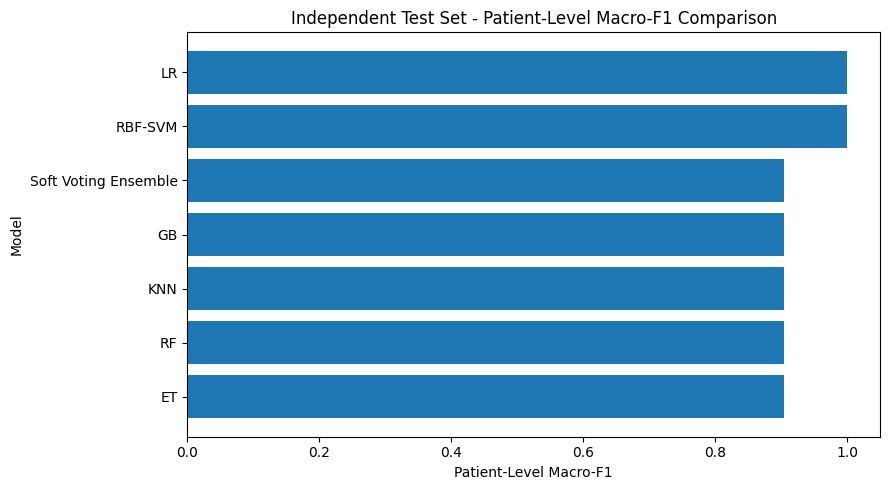

Patient-level Macro-F1 grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/final_patient_level_macro_f1_comparison.png


In [49]:
# =========================
# HÜCRE 48: Patient-Level Macro-F1 Comparison Chart
# =========================

plot_df = patient_level_test_results_df.sort_values(by="Macro-F1", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["Macro-F1"])
plt.title("Independent Test Set - Patient-Level Macro-F1 Comparison")
plt.xlabel("Patient-Level Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1.05)
plt.tight_layout()

patient_level_macro_f1_fig_path = os.path.join(FIGURE_DIR, "final_patient_level_macro_f1_comparison.png")
plt.savefig(patient_level_macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Patient-level Macro-F1 grafiği kaydedildi:")
print(patient_level_macro_f1_fig_path)

## 49. İstatistiksel Karşılaştırma İçin Repeated Split Sonuçlarının Hazırlanması

Bu bölümde modellerin istatistiksel olarak karşılaştırılabilmesi için repeated patient-level sanity check sonuçları kullanılacaktır.

Tek bir bağımsız test sonucu istatistiksel karşılaştırma için yeterli değildir. Bu nedenle daha önce oluşturulan repeated split sonuçları üzerinden her modelin farklı bölmelerdeki Macro-F1 skorları karşılaştırılacaktır.

Bu analizde Friedman Test, Wilcoxon Signed-Rank Test ve Bonferroni düzeltmesi uygulanacaktır.

In [50]:
# =========================
# HÜCRE 49: Repeated Split Sonuçlarını Hazırlama
# =========================

from scipy.stats import friedmanchisquare, wilcoxon
import itertools

# Eğer değişken hafızada yoksa CSV'den tekrar oku
if "sanity_results_df" not in globals():
    sanity_results_path = os.path.join(OUTPUT_DIR, "repeated_split_sanity_results.csv")
    sanity_results_df = pd.read_csv(sanity_results_path)

print("Repeated split sonuç tablosu boyutu:", sanity_results_df.shape)
display(sanity_results_df.head())

# Kolon adlarını garantiye alıyoruz
if "model" in sanity_results_df.columns:
    model_col = "model"
else:
    model_col = "Model"

# Friedman için pivot tablo
stat_pivot_df = sanity_results_df.pivot_table(
    index="split_id",
    columns=model_col,
    values="Macro-F1",
    aggfunc="mean"
)

# Eksik değer varsa ilgili split çıkarılır
stat_pivot_df = stat_pivot_df.dropna(axis=0)

print("\nİstatistiksel testlerde kullanılacak pivot tablo:")
display(stat_pivot_df)

print("\nModel listesi:")
print(stat_pivot_df.columns.tolist())

print("\nSplit sayısı:", stat_pivot_df.shape[0])

Repeated split sonuç tablosu boyutu: (120, 15)


,split_id,model,val_sample_count,val_group_count,val_normal_count,val_papilodem_count,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score
0,1,LR,154,11,112,42,0.844156,0.673077,0.833333,0.744681,0.816266,0.840774,0.887330,0.875692,0.147040
1,1,RBF-SVM,154,11,112,42,0.909091,0.791667,0.904762,0.844444,0.890112,0.907738,0.970876,0.948616,0.070673
2,1,RF,154,11,112,42,0.961039,0.973684,0.880952,0.925000,0.949342,0.936012,0.976403,0.965719,0.041933
3,1,ET,154,11,112,42,0.967532,1.000000,0.880952,0.936709,0.957437,0.940476,0.988520,0.979636,0.038218
4,1,GB,154,11,112,42,0.961039,0.928571,0.928571,0.928571,0.950893,0.950893,0.946854,0.950186,0.035592



İstatistiksel testlerde kullanılacak pivot tablo:


model,ET,GB,KNN,LR,RBF-SVM,RF
split_id,,,,,,
1,0.957437,0.950893,0.966760,0.816266,0.890112,0.949342
2,0.991875,0.952905,0.975971,0.888357,0.895238,0.952905
3,0.818738,0.839917,0.811148,0.697727,0.838262,0.811484
4,0.867811,0.852814,0.883299,0.733129,0.809091,0.867811
5,0.859813,0.822543,0.864912,0.822543,0.852679,0.852679
6,0.945409,0.923444,0.895238,0.895238,0.923444,0.952905
7,0.991875,0.909198,0.968182,0.835309,0.960495,0.952905
8,0.793530,0.835498,0.814936,0.811148,0.818182,0.814936
9,0.983380,0.930683,0.930683,0.860047,1.000000,1.000000



Model listesi:
['ET', 'GB', 'KNN', 'LR', 'RBF-SVM', 'RF']

Split sayısı: 20


## 50. Friedman Test Uygulaması

Bu bölümde modellerin repeated split Macro-F1 skorları arasında genel olarak anlamlı bir fark olup olmadığı Friedman Test ile incelenecektir.

Friedman Test, aynı veri bölmeleri üzerinde değerlendirilen birden fazla modelin performanslarının karşılaştırılmasında kullanılan parametrik olmayan bir testtir.

Hipotezler:

- H0: Modellerin Macro-F1 performansları arasında anlamlı fark yoktur.
- H1: En az bir modelin Macro-F1 performansı diğerlerinden anlamlı şekilde farklıdır.

In [51]:
# =========================
# HÜCRE 50: Friedman Test
# =========================

model_names_for_stats = stat_pivot_df.columns.tolist()

friedman_input = [
    stat_pivot_df[model_name].values
    for model_name in model_names_for_stats
]

friedman_stat, friedman_p = friedmanchisquare(*friedman_input)

friedman_results_df = pd.DataFrame({
    "Test": ["Friedman Test"],
    "Statistic": [friedman_stat],
    "p-value": [friedman_p],
    "Significant at alpha=0.05": [friedman_p < 0.05]
})

display(friedman_results_df)

friedman_results_path = os.path.join(OUTPUT_DIR, "friedman_test_results.csv")
friedman_results_df.to_csv(friedman_results_path, index=False)

print("Friedman test sonucu kaydedildi:")
print(friedman_results_path)

,Test,Statistic,p-value,Significant at alpha=0.05
0,Friedman Test,37.616618,4.505038e-07,True


Friedman test sonucu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/friedman_test_results.csv


## 51. Wilcoxon Signed-Rank Test ve Bonferroni Correction

Bu bölümde modeller ikili olarak karşılaştırılacaktır.

Friedman Test genel farkı gösterirken, Wilcoxon Signed-Rank Test hangi model çiftleri arasında fark bulunduğunu incelemek için kullanılacaktır.

Çoklu karşılaştırma yapıldığı için p-değerlerine Bonferroni düzeltmesi uygulanacaktır.

In [52]:
# =========================
# HÜCRE 51: Pairwise Wilcoxon + Bonferroni Correction
# =========================

pairwise_records = []

model_pairs = list(itertools.combinations(model_names_for_stats, 2))
n_comparisons = len(model_pairs)

for model_a, model_b in model_pairs:
    scores_a = stat_pivot_df[model_a].values
    scores_b = stat_pivot_df[model_b].values

    differences = scores_a - scores_b

    # Eğer tüm farklar sıfırsa Wilcoxon hata verebilir; bu durumda p=1 kabul edilir
    if np.allclose(differences, 0):
        stat_value = 0.0
        p_value = 1.0
    else:
        stat_value, p_value = wilcoxon(
            scores_a,
            scores_b,
            zero_method="wilcox",
            alternative="two-sided"
        )

    bonferroni_p = min(p_value * n_comparisons, 1.0)

    pairwise_records.append({
        "Model A": model_a,
        "Model B": model_b,
        "Mean Macro-F1 A": np.mean(scores_a),
        "Mean Macro-F1 B": np.mean(scores_b),
        "Mean Difference A-B": np.mean(differences),
        "Wilcoxon Statistic": stat_value,
        "Raw p-value": p_value,
        "Bonferroni Adjusted p-value": bonferroni_p,
        "Significant after Bonferroni alpha=0.05": bonferroni_p < 0.05
    })

wilcoxon_results_df = pd.DataFrame(pairwise_records)
wilcoxon_results_df = wilcoxon_results_df.sort_values(
    by="Bonferroni Adjusted p-value",
    ascending=True
).reset_index(drop=True)

display(wilcoxon_results_df)

wilcoxon_results_path = os.path.join(OUTPUT_DIR, "wilcoxon_bonferroni_pairwise_results.csv")
wilcoxon_results_df.to_csv(wilcoxon_results_path, index=False)

print("Wilcoxon + Bonferroni sonuçları kaydedildi:")
print(wilcoxon_results_path)

,Model A,Model B,Mean Macro-F1 A,Mean Macro-F1 B,Mean Difference A-B,Wilcoxon Statistic,Raw p-value,Bonferroni Adjusted p-value,Significant after Bonferroni alpha=0.05
0,LR,RBF-SVM,0.813302,0.885367,-0.072065,0.0,0.000002,0.000029,True
1,ET,LR,0.894559,0.813302,0.081256,6.0,0.000027,0.000401,True
2,LR,RF,0.813302,0.884015,-0.070712,9.0,0.000063,0.000944,True
3,GB,LR,0.872729,0.813302,0.059427,5.0,0.000293,0.004388,True
4,KNN,LR,0.876895,0.813302,0.063592,10.0,0.000625,0.009373,True
5,ET,GB,0.894559,0.872729,0.021829,31.0,0.004221,0.063314,False
6,ET,KNN,0.894559,0.876895,0.017664,26.0,0.016822,0.252331,False
7,ET,RF,0.894559,0.884015,0.010544,35.0,0.027839,0.417579,False
8,GB,RBF-SVM,0.872729,0.885367,-0.012638,59.0,0.147416,1.000000,False
9,GB,KNN,0.872729,0.876895,-0.004165,82.0,0.600871,1.000000,False


Wilcoxon + Bonferroni sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/wilcoxon_bonferroni_pairwise_results.csv


## 52. Repeated Split Ortalama Model Performanslarının Görselleştirilmesi

Bu bölümde istatistiksel analizde kullanılan repeated split sonuçları grafikle gösterilecektir.

Her model için ortalama Macro-F1 ve standart sapma değerleri sunulacaktır. Bu grafik, modellerin yalnızca tek bir test sonucu üzerinden değil, tekrar eden hasta bazlı bölmelerdeki kararlılığı üzerinden de karşılaştırılmasını sağlar.

,Model,Macro-F1 Mean,Macro-F1 Std
0,ET,0.894559,0.083080
4,RBF-SVM,0.885367,0.070289
5,RF,0.884015,0.082950
2,KNN,0.876895,0.075014
1,GB,0.872729,0.075458
3,LR,0.813302,0.072514


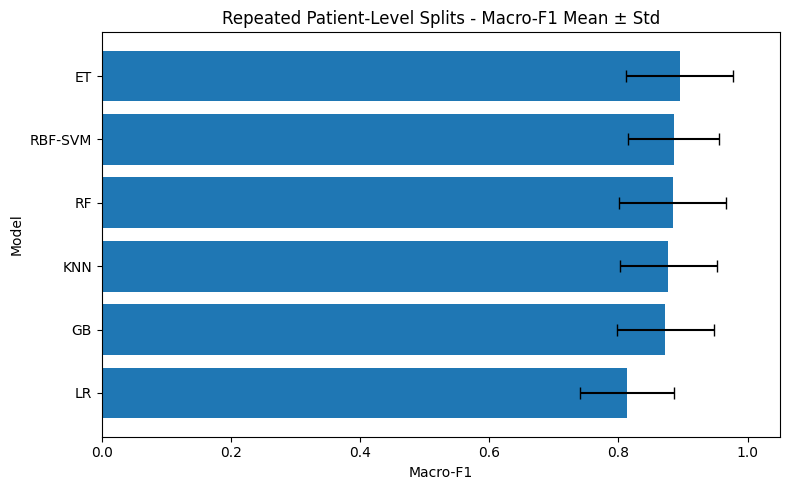

Repeated split istatistik özeti kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/repeated_split_macro_f1_stats_summary.csv

Grafik kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/repeated_split_macro_f1_mean_std.png


In [53]:
# =========================
# HÜCRE 52: Repeated Split Macro-F1 Ortalama ve Standart Sapma Grafiği
# =========================

stats_summary_df = stat_pivot_df.agg(["mean", "std"]).T.reset_index()
stats_summary_df.columns = ["Model", "Macro-F1 Mean", "Macro-F1 Std"]
stats_summary_df = stats_summary_df.sort_values(by="Macro-F1 Mean", ascending=False)

display(stats_summary_df)

stats_summary_path = os.path.join(OUTPUT_DIR, "repeated_split_macro_f1_stats_summary.csv")
stats_summary_df.to_csv(stats_summary_path, index=False)

plot_df = stats_summary_df.sort_values(by="Macro-F1 Mean", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_df["Model"],
    plot_df["Macro-F1 Mean"],
    xerr=plot_df["Macro-F1 Std"],
    capsize=4
)
plt.title("Repeated Patient-Level Splits - Macro-F1 Mean ± Std")
plt.xlabel("Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1.05)
plt.tight_layout()

stats_fig_path = os.path.join(FIGURE_DIR, "repeated_split_macro_f1_mean_std.png")
plt.savefig(stats_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Repeated split istatistik özeti kaydedildi:")
print(stats_summary_path)

print("\nGrafik kaydedildi:")
print(stats_fig_path)

## 53. MRMR Feature Stability Analysis

Bu bölümde MRMR ile seçilen özelliklerin repeated patient-level splitler boyunca ne kadar kararlı seçildiği analiz edilecektir.

Feature stability analysis, modelin yalnızca tek bir bölmede seçilen özelliklere bağımlı olup olmadığını anlamak için önemlidir.

Bu analizde bağımsız test seti kullanılmayacaktır. Sadece train + validation geliştirme verisi üzerinde repeated patient-level splitler yapılacaktır.

Her tekrarda:

1. Hasta bazlı train-validation ayrımı yapılır.
2. Ön işleme yalnızca train bölümüne fit edilir.
3. MRMR yalnızca train bölümünde uygulanır.
4. Seçilen özellikler kaydedilir.

Son olarak her özelliğin seçilme frekansı hesaplanır.

In [54]:
# =========================
# HÜCRE 53: Feature Stability Analysis
# =========================

N_STABILITY_SPLITS = 20

# En iyi final model RBF-SVM olduğu için onun MRMR özellik sayısını temel alıyoruz
BEST_MODEL_FOR_STABILITY = "RBF-SVM"
STABILITY_MRMR_FEATURE_COUNT = final_optuna_studies[BEST_MODEL_FOR_STABILITY].best_params["n_mrmr_features"]

print("Feature stability için temel model:", BEST_MODEL_FOR_STABILITY)
print("Her splitte seçilecek MRMR özellik sayısı:", STABILITY_MRMR_FEATURE_COUNT)
print("Repeated split sayısı:", N_STABILITY_SPLITS)

dev_df_for_stability = pd.concat([train_df, val_df], axis=0, ignore_index=True)

dev_group_df_for_stability = dev_df_for_stability.groupby("group_id").agg(
    target=("target", "first"),
    class_name=("class_name", "first"),
    sample_count=("target", "size")
).reset_index()

stability_records = []
selected_features_by_split = {}

for split_id in range(N_STABILITY_SPLITS):
    print(f"Feature stability split: {split_id + 1}/{N_STABILITY_SPLITS}")

    train_groups_stab, val_groups_stab = train_test_split(
        dev_group_df_for_stability,
        test_size=0.20,
        random_state=RANDOM_STATE + 1000 + split_id,
        stratify=dev_group_df_for_stability["target"]
    )

    train_ids_stab = set(train_groups_stab["group_id"])

    train_stab_df = dev_df_for_stability[
        dev_df_for_stability["group_id"].isin(train_ids_stab)
    ].reset_index(drop=True)

    X_train_stab_raw = train_stab_df[feature_cols].copy()
    y_train_stab = train_stab_df["target"].astype(int).values

    stab_preprocessor = RadiomicsPreprocessor(
        variance_threshold=1e-8,
        corr_threshold=0.95
    )

    X_train_stab_prep = stab_preprocessor.fit_transform(X_train_stab_raw)

    selected_features_stab, _ = mrmr_feature_selection(
        X=X_train_stab_prep,
        y=y_train_stab,
        n_features=STABILITY_MRMR_FEATURE_COUNT,
        redundancy_weight=0.5,
        random_state=RANDOM_STATE + 1000 + split_id
    )

    selected_features_by_split[split_id + 1] = selected_features_stab

    for feature in selected_features_stab:
        stability_records.append({
            "split_id": split_id + 1,
            "feature": feature
        })

stability_selection_df = pd.DataFrame(stability_records)

feature_stability_df = stability_selection_df.groupby("feature").agg(
    selection_count=("split_id", "nunique")
).reset_index()

feature_stability_df["selection_frequency"] = (
    feature_stability_df["selection_count"] / N_STABILITY_SPLITS
)

feature_stability_df = feature_stability_df.sort_values(
    by=["selection_frequency", "selection_count"],
    ascending=False
).reset_index(drop=True)

print("\nFeature stability sonuçları ilk 30 özellik:")
display(feature_stability_df.head(30))

feature_stability_path = os.path.join(OUTPUT_DIR, "mrmr_feature_stability_analysis.csv")
feature_stability_df.to_csv(feature_stability_path, index=False)

print("\nFeature stability tablosu kaydedildi:")
print(feature_stability_path)

Feature stability için temel model: RBF-SVM
Her splitte seçilecek MRMR özellik sayısı: 20
Repeated split sayısı: 20
Feature stability split: 1/20
Feature stability split: 2/20
Feature stability split: 3/20
Feature stability split: 4/20
Feature stability split: 5/20
Feature stability split: 6/20
Feature stability split: 7/20
Feature stability split: 8/20
Feature stability split: 9/20
Feature stability split: 10/20
Feature stability split: 11/20
Feature stability split: 12/20
Feature stability split: 13/20
Feature stability split: 14/20
Feature stability split: 15/20
Feature stability split: 16/20
Feature stability split: 17/20
Feature stability split: 18/20
Feature stability split: 19/20
Feature stability split: 20/20

Feature stability sonuçları ilk 30 özellik:


,feature,selection_count,selection_frequency
0,Feature_0003,20,1.00
1,Feature_0028,20,1.00
2,Feature_0034,20,1.00
3,Feature_0040,20,1.00
4,Feature_0043,20,1.00
5,Feature_0086,20,1.00
6,Feature_0224,20,1.00
7,Feature_0408,20,1.00
8,Feature_0478,20,1.00
9,Feature_0067,19,0.95



Feature stability tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/mrmr_feature_stability_analysis.csv


## 54. Feature Stability Threshold Özeti ve Grafiği

Bu bölümde MRMR feature stability sonuçları farklı seçilme frekansı eşiklerine göre özetlenecektir.

Kullanılacak eşikler:

- %50
- %60
- %70
- %80

Bu analiz, hangi özelliklerin tekrar eden bölmeler boyunca daha kararlı şekilde seçildiğini gösterir.

Feature stability threshold özeti:


,Selection Frequency Threshold,Stable Feature Count,Stable Features
0,0.5,18,"Feature_0003, Feature_0028, Feature_0034, Feat..."
1,0.6,17,"Feature_0003, Feature_0028, Feature_0034, Feat..."
2,0.7,15,"Feature_0003, Feature_0028, Feature_0034, Feat..."
3,0.8,15,"Feature_0003, Feature_0028, Feature_0034, Feat..."


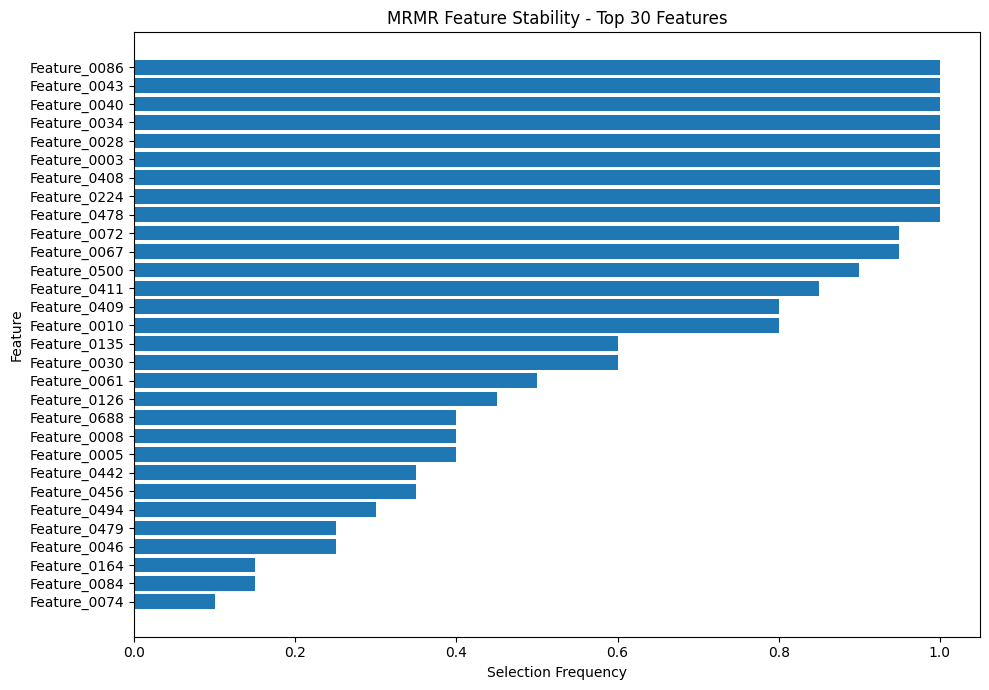

Feature stability threshold özeti kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/feature_stability_threshold_summary.csv

Feature stability grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/mrmr_feature_stability_top30.png


In [55]:
# =========================
# HÜCRE 54: Feature Stability Threshold Özeti ve Grafiği
# =========================

stability_thresholds = [0.50, 0.60, 0.70, 0.80]

stability_threshold_records = []

for threshold in stability_thresholds:
    stable_features = feature_stability_df[
        feature_stability_df["selection_frequency"] >= threshold
    ]

    stability_threshold_records.append({
        "Selection Frequency Threshold": threshold,
        "Stable Feature Count": stable_features.shape[0],
        "Stable Features": ", ".join(stable_features["feature"].tolist())
    })

stability_threshold_summary_df = pd.DataFrame(stability_threshold_records)

print("Feature stability threshold özeti:")
display(stability_threshold_summary_df)

stability_threshold_path = os.path.join(OUTPUT_DIR, "feature_stability_threshold_summary.csv")
stability_threshold_summary_df.to_csv(stability_threshold_path, index=False)

# İlk 30 özellik grafiği
top_stability_df = feature_stability_df.head(30).sort_values(
    by="selection_frequency",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(top_stability_df["feature"], top_stability_df["selection_frequency"])
plt.title("MRMR Feature Stability - Top 30 Features")
plt.xlabel("Selection Frequency")
plt.ylabel("Feature")
plt.xlim(0, 1.05)
plt.tight_layout()

stability_fig_path = os.path.join(FIGURE_DIR, "mrmr_feature_stability_top30.png")
plt.savefig(stability_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Feature stability threshold özeti kaydedildi:")
print(stability_threshold_path)

print("\nFeature stability grafiği kaydedildi:")
print(stability_fig_path)

## 55. Klinik Recall Odaklı Threshold Analizi

Bu bölümde en başarılı model olan RBF-SVM için klinik bağlama uygun ek threshold analizi yapılacaktır.

Papilödem sınıfı klinik açıdan kaçırılmaması gereken bir durum olduğu için yalnızca Macro-F1 skoruna göre seçilen eşik yeterli olmayabilir. Bu nedenle validation seti üzerinde recall/sensitivity öncelikli ikinci bir threshold seçimi yapılacaktır.

Bu analizde test seti threshold seçimi için kullanılmayacaktır. Threshold yalnızca validation setinde seçilecek, ardından bağımsız test setine uygulanacaktır.

Amaç:

1. Papilödem recall değerini mümkün olduğunca yüksek tutmak
2. Recall yüksekken Macro-F1 ve Precision değerlerini korumak
3. Klinik açıdan false negative riskini azaltabilecek threshold alternatifini değerlendirmek

In [56]:
# =========================
# HÜCRE 55: Klinik Recall Odaklı Threshold Seçimi - Düzeltilmiş
# =========================

CLINICAL_MODEL_NAME = "RBF-SVM"

def threshold_sweep_for_clinical_recall(y_true, y_proba, step=0.01):
    thresholds = np.arange(0.05, 0.951, step)
    records = []

    for threshold in thresholds:
        y_pred = (np.asarray(y_proba) >= threshold).astype(int)

        records.append({
            "threshold": float(threshold),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-score": f1_score(y_true, y_pred, zero_division=0),
            "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "False Negatives": int(((np.asarray(y_true) == 1) & (y_pred == 0)).sum()),
            "False Positives": int(((np.asarray(y_true) == 0) & (y_pred == 1)).sum())
        })

    return pd.DataFrame(records)


clinical_val_proba = validation_prediction_store[CLINICAL_MODEL_NAME]["val_calibrated_proba"]

clinical_threshold_df = threshold_sweep_for_clinical_recall(
    y_true=y_val,
    y_proba=clinical_val_proba,
    step=0.01
)

# Düzeltilmiş klinik seçim kuralı:
# 1. Recall maksimum
# 2. False Negatives minimum
# 3. Macro-F1 maksimum
# 4. Precision maksimum
# 5. Eşitlik varsa daha düşük threshold seçilir
best_clinical_row = clinical_threshold_df.sort_values(
    by=["Recall", "False Negatives", "Macro-F1", "Precision", "threshold"],
    ascending=[False, True, False, False, True]
).iloc[0]

clinical_recall_threshold = float(best_clinical_row["threshold"])

print("Standart Macro-F1 threshold:", model_thresholds[CLINICAL_MODEL_NAME])
print("Düzeltilmiş klinik recall odaklı threshold:", clinical_recall_threshold)

print("\nValidation üzerinde seçilen düzeltilmiş klinik threshold satırı:")
display(best_clinical_row.to_frame().T)

print("\nEn iyi recall odaklı ilk 20 threshold adayı:")
display(clinical_threshold_df.sort_values(
    by=["Recall", "False Negatives", "Macro-F1", "Precision", "threshold"],
    ascending=[False, True, False, False, True]
).head(20))

clinical_threshold_path = os.path.join(
    OUTPUT_DIR,
    "clinical_recall_threshold_sweep_rbf_svm_validation_corrected.csv"
)
clinical_threshold_df.to_csv(clinical_threshold_path, index=False)

print("\nDüzeltilmiş klinik recall threshold sweep tablosu kaydedildi:")
print(clinical_threshold_path)

Standart Macro-F1 threshold: 0.4800000000000001
Düzeltilmiş klinik recall odaklı threshold: 0.4800000000000001

Validation üzerinde seçilen düzeltilmiş klinik threshold satırı:


,threshold,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,False Negatives,False Positives
43,0.48,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0.0,3.0



En iyi recall odaklı ilk 20 threshold adayı:


,threshold,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,False Negatives,False Positives
43,0.48,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
44,0.49,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
45,0.50,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
46,0.51,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
47,0.52,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
48,0.53,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
49,0.54,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
50,0.55,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
51,0.56,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3
52,0.57,0.969388,0.903226,1.0,0.949153,0.963627,0.978571,0,3



Düzeltilmiş klinik recall threshold sweep tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/clinical_recall_threshold_sweep_rbf_svm_validation_corrected.csv


## 56. Klinik Recall Threshold'un Bağımsız Test Setinde Değerlendirilmesi

Bu bölümde validation seti üzerinde seçilen klinik recall odaklı threshold bağımsız test setine uygulanacaktır.

Burada amaç, standart Macro-F1 odaklı threshold ile recall odaklı threshold arasındaki farkı karşılaştırmaktır.

Test seti threshold seçimi için kullanılmayacak, yalnızca final karşılaştırma amacıyla değerlendirilecektir.

In [57]:
# =========================
# HÜCRE 56: Klinik Threshold Test Değerlendirmesi
# =========================

rbf_test_proba = test_prediction_store[CLINICAL_MODEL_NAME]["calibrated_proba"]

standard_threshold = model_thresholds[CLINICAL_MODEL_NAME]
clinical_threshold = clinical_recall_threshold

# Standart threshold sonucu
rbf_test_pred_standard = (rbf_test_proba >= standard_threshold).astype(int)
standard_metrics = evaluate_final_binary_classification(
    y_true=y_test,
    y_pred=rbf_test_pred_standard,
    y_proba=rbf_test_proba
)

standard_cm = confusion_matrix(y_test, rbf_test_pred_standard)

# Klinik recall threshold sonucu
rbf_test_pred_clinical = (rbf_test_proba >= clinical_threshold).astype(int)
clinical_metrics = evaluate_final_binary_classification(
    y_true=y_test,
    y_pred=rbf_test_pred_clinical,
    y_proba=rbf_test_proba
)

clinical_cm = confusion_matrix(y_test, rbf_test_pred_clinical)

clinical_comparison_df = pd.DataFrame([
    {
        "Setting": "Standard Macro-F1 Threshold",
        "Threshold": standard_threshold,
        **standard_metrics,
        "TN": standard_cm[0, 0],
        "FP": standard_cm[0, 1],
        "FN": standard_cm[1, 0],
        "TP": standard_cm[1, 1]
    },
    {
        "Setting": "Clinical Recall-Oriented Threshold",
        "Threshold": clinical_threshold,
        **clinical_metrics,
        "TN": clinical_cm[0, 0],
        "FP": clinical_cm[0, 1],
        "FN": clinical_cm[1, 0],
        "TP": clinical_cm[1, 1]
    }
])

ordered_cols = [
    "Setting",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Brier Score",
    "ECE-10",
    "TN",
    "FP",
    "FN",
    "TP"
]

clinical_comparison_df = clinical_comparison_df[ordered_cols]

print("RBF-SVM standart threshold vs klinik recall threshold test karşılaştırması:")
display(clinical_comparison_df)

clinical_comparison_path = os.path.join(
    OUTPUT_DIR,
    "rbf_svm_standard_vs_clinical_threshold_test_comparison.csv"
)
clinical_comparison_df.to_csv(clinical_comparison_path, index=False)

print("\nKarşılaştırma tablosu kaydedildi:")
print(clinical_comparison_path)

print("\nStandart threshold confusion matrix:")
print(standard_cm)

print("\nKlinik recall threshold confusion matrix:")
print(clinical_cm)

RBF-SVM standart threshold vs klinik recall threshold test karşılaştırması:


,Setting,Threshold,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10,TN,FP,FN,TP
0,Standard Macro-F1 Threshold,0.48,0.969388,0.980769,0.910714,0.944444,0.961659,0.951786,0.995026,0.990141,0.027744,0.072334,139,1,5,51
1,Clinical Recall-Oriented Threshold,0.48,0.969388,0.980769,0.910714,0.944444,0.961659,0.951786,0.995026,0.990141,0.027744,0.072334,139,1,5,51



Karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/rbf_svm_standard_vs_clinical_threshold_test_comparison.csv

Standart threshold confusion matrix:
[[139   1]
 [  5  51]]

Klinik recall threshold confusion matrix:
[[139   1]
 [  5  51]]


## 57. Standart ve Klinik Threshold Confusion Matrix Karşılaştırması

Bu bölümde RBF-SVM modelinin standart Macro-F1 threshold ve klinik recall threshold sonuçları confusion matrix ile karşılaştırılacaktır.

Bu grafikler, recall odaklı threshold seçiminin false negative sayısını azaltıp azaltmadığını görsel olarak göstermektedir.

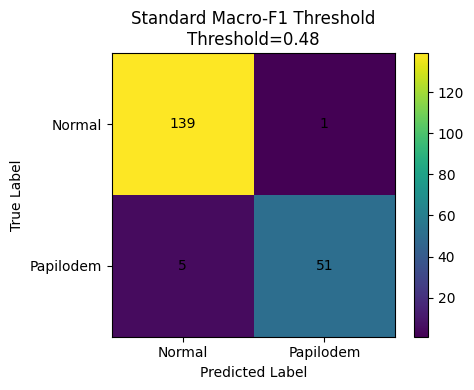

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/rbf_svm_standard_macro_f1_threshold_confusion_matrix.png


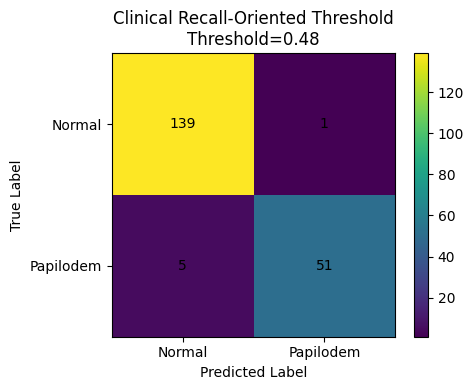

Grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/rbf_svm_clinical_recall_oriented_threshold_confusion_matrix.png


In [58]:
# =========================
# HÜCRE 57: Standart vs Klinik Threshold Confusion Matrix Grafikleri
# =========================

threshold_settings = [
    ("Standard Macro-F1 Threshold", standard_cm, standard_threshold),
    ("Clinical Recall-Oriented Threshold", clinical_cm, clinical_threshold)
]

for setting_name, cm_data, threshold_value in threshold_settings:
    plt.figure(figsize=(5, 4))
    plt.imshow(cm_data)
    plt.title(f"{setting_name}\nThreshold={threshold_value:.2f}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Normal", "Papilodem"])
    plt.yticks([0, 1], ["Normal", "Papilodem"])

    for i in range(cm_data.shape[0]):
        for j in range(cm_data.shape[1]):
            plt.text(j, i, cm_data[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()

    safe_name = setting_name.lower().replace(" ", "_").replace("-", "_")
    fig_path = os.path.join(
        FIGURE_DIR,
        f"rbf_svm_{safe_name}_confusion_matrix.png"
    )

    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Grafik kaydedildi:", fig_path)

## 58. SHAP Açıklanabilirlik Analizi İçin Hazırlık

Bu bölümde en başarılı final model olan RBF-SVM için SHAP açıklanabilirlik analizi yapılacaktır.

RBF-SVM kernel tabanlı bir model olduğu için doğrudan katsayı temelli açıklama üretmez. Bu nedenle modelden bağımsız çalışan Kernel SHAP yöntemi kullanılacaktır.

SHAP analizi, modelin tahminlerinde hangi radyomik özelliklerin daha etkili olduğunu yorumlamak için kullanılacaktır.

Hesaplama maliyetini kontrol altında tutmak için sınırlı sayıda background örneği ve test örneği seçilecektir.

In [59]:
# =========================
# HÜCRE 58: SHAP Hazırlık
# =========================

!pip install -q shap

import shap

SHAP_MODEL_NAME = "RBF-SVM"

shap_pipeline = final_dev_pipelines[SHAP_MODEL_NAME]
shap_model = shap_pipeline["model"]
shap_calibrator = final_dev_calibrators[SHAP_MODEL_NAME]
shap_selected_features = shap_pipeline["selected_features"]

# Development ve test verilerini aynı preprocessing + MRMR uzayına dönüştürüyoruz
X_dev_prep_shap = shap_pipeline["preprocessor"].transform(dev_df[feature_cols])
X_dev_selected_shap = X_dev_prep_shap[shap_selected_features]

X_test_prep_shap = shap_pipeline["preprocessor"].transform(test_df[feature_cols])
X_test_selected_shap = X_test_prep_shap[shap_selected_features]

# Kernel SHAP maliyetli olduğu için örnek sayısını sınırlıyoruz
background_size = min(30, X_dev_selected_shap.shape[0])
explain_size = min(40, X_test_selected_shap.shape[0])

X_shap_background = X_dev_selected_shap.sample(
    n=background_size,
    random_state=RANDOM_STATE
)

X_shap_explain = X_test_selected_shap.sample(
    n=explain_size,
    random_state=RANDOM_STATE
)

print("SHAP modeli:", SHAP_MODEL_NAME)
print("Seçili özellik sayısı:", len(shap_selected_features))
print("SHAP background boyutu:", X_shap_background.shape)
print("SHAP açıklanacak test örneği boyutu:", X_shap_explain.shape)

SHAP modeli: RBF-SVM
Seçili özellik sayısı: 20
SHAP background boyutu: (30, 20)
SHAP açıklanacak test örneği boyutu: (40, 20)


## 59. Kernel SHAP Değerlerinin Hesaplanması

Bu bölümde RBF-SVM modelinin kalibre edilmiş papilödem olasılık çıktısı üzerinden SHAP değerleri hesaplanacaktır.

Fonksiyon çıktısı pozitif sınıf olan `Papilödem = 1` olasılığıdır.

Bu işlem birkaç dakika sürebilir.

In [60]:
# =========================
# HÜCRE 59: Kernel SHAP Hesaplama
# =========================

def shap_predict_positive_proba(X_array):
    X_df = pd.DataFrame(X_array, columns=shap_selected_features)

    raw_proba = shap_model.predict_proba(X_df)[:, 1]
    calibrated_proba = shap_calibrator.predict_proba(raw_proba)

    return calibrated_proba

shap_explainer = shap.KernelExplainer(
    shap_predict_positive_proba,
    X_shap_background
)

shap_values = shap_explainer.shap_values(
    X_shap_explain,
    nsamples=100
)

# Bazı SHAP sürümlerinde çıktı liste olabilir; pozitif sınıf vektörünü güvenli şekilde alıyoruz
if isinstance(shap_values, list):
    shap_values_positive = shap_values[-1]
else:
    shap_values_positive = shap_values

print("SHAP değerleri hesaplandı.")
print("SHAP değer matrisi boyutu:", np.array(shap_values_positive).shape)

  0%|          | 0/40 [00:00<?, ?it/s]

SHAP değerleri hesaplandı.
SHAP değer matrisi boyutu: (40, 20)


## 60. SHAP Global Feature Importance Grafiği

Bu bölümde SHAP değerleri kullanılarak global özellik önem sıralaması oluşturulacaktır.

Ortalama mutlak SHAP değeri yüksek olan özellikler, model tahminleri üzerinde daha güçlü etkiye sahip kabul edilir.

Bu grafik raporda SHAP açıklanabilirlik analizi bölümünde kullanılacaktır.

SHAP global önem sıralaması ilk 20 özellik:


,feature,mean_abs_shap
0,Feature_0224,0.046788
1,Feature_0028,0.044989
2,Feature_0442,0.037303
3,Feature_0409,0.033708
4,Feature_0008,0.030558
5,Feature_0408,0.030303
6,Feature_0500,0.027404
7,Feature_0043,0.023171
8,Feature_0040,0.019517
9,Feature_0135,0.017293


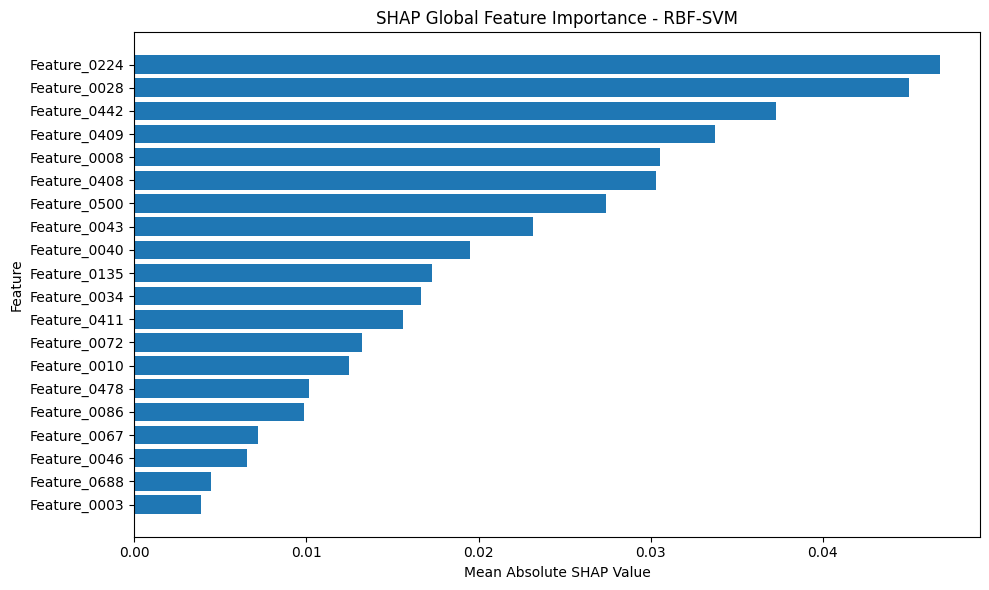

SHAP önem tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/shap_global_feature_importance_rbf_svm.csv

SHAP bar grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/shap_global_feature_importance_rbf_svm.png


In [61]:
# =========================
# HÜCRE 60: SHAP Global Importance
# =========================

mean_abs_shap = np.abs(shap_values_positive).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": shap_selected_features,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

print("SHAP global önem sıralaması ilk 20 özellik:")
display(shap_importance_df.head(20))

shap_importance_path = os.path.join(
    OUTPUT_DIR,
    "shap_global_feature_importance_rbf_svm.csv"
)
shap_importance_df.to_csv(shap_importance_path, index=False)

top_shap_df = shap_importance_df.head(20).sort_values(
    by="mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_shap_df["feature"], top_shap_df["mean_abs_shap"])
plt.title("SHAP Global Feature Importance - RBF-SVM")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()

shap_bar_fig_path = os.path.join(
    FIGURE_DIR,
    "shap_global_feature_importance_rbf_svm.png"
)
plt.savefig(shap_bar_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("SHAP önem tablosu kaydedildi:")
print(shap_importance_path)

print("\nSHAP bar grafiği kaydedildi:")
print(shap_bar_fig_path)

## 61. SHAP Summary Plot

Bu bölümde SHAP summary plot oluşturulacaktır.

Summary plot, hem özellik önemini hem de özellik değerlerinin model çıktısını hangi yönde etkilediğini görselleştirir.

Bu grafik raporda açıklanabilir yapay zeka analizi kapsamında kullanılacaktır.

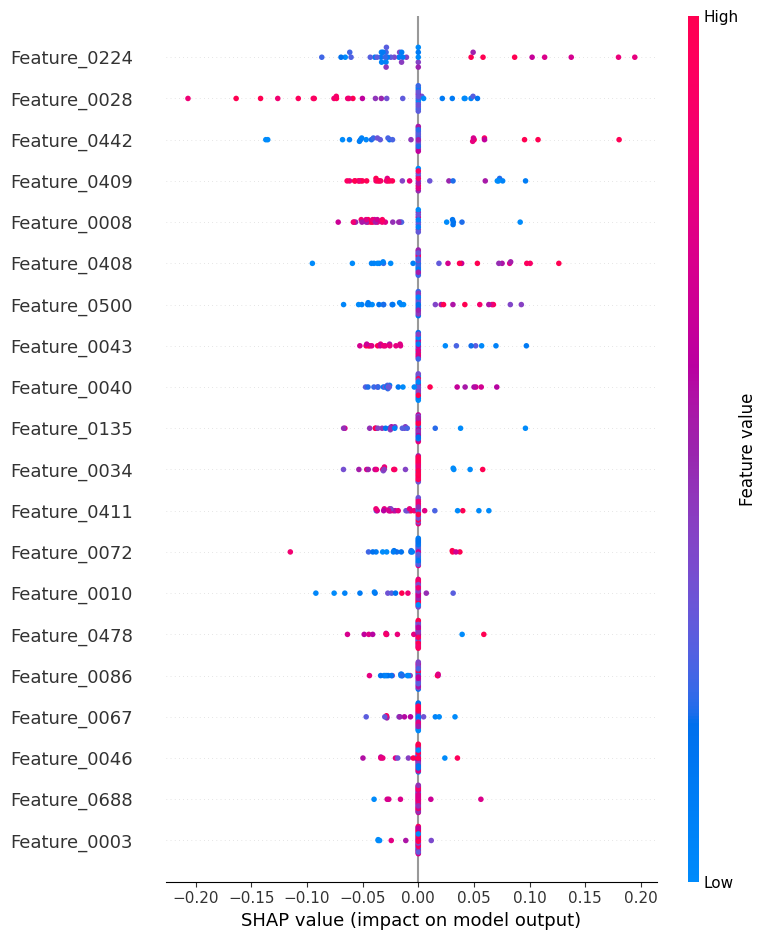

SHAP summary plot kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/shap_summary_plot_rbf_svm.png


In [62]:
# =========================
# HÜCRE 61: SHAP Summary Plot
# =========================

plt.figure()
shap.summary_plot(
    shap_values_positive,
    X_shap_explain,
    feature_names=shap_selected_features,
    show=False
)

shap_summary_fig_path = os.path.join(
    FIGURE_DIR,
    "shap_summary_plot_rbf_svm.png"
)
plt.savefig(shap_summary_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("SHAP summary plot kaydedildi:")
print(shap_summary_fig_path)

## 62. LIME Açıklanabilirlik Analizi

Bu bölümde RBF-SVM modeli için LIME açıklanabilirlik analizi uygulanacaktır.

LIME, tek bir örnek özelinde modelin tahminini hangi özelliklerin desteklediğini veya zayıflattığını açıklar.

Bu çalışmada bir normal ve bir papilödem test örneği için ayrı ayrı LIME açıklaması üretilecektir.

In [63]:
# =========================
# HÜCRE 62: LIME Hazırlık
# =========================

!pip install -q lime

from lime.lime_tabular import LimeTabularExplainer

lime_pipeline = final_dev_pipelines["RBF-SVM"]
lime_model = lime_pipeline["model"]
lime_calibrator = final_dev_calibrators["RBF-SVM"]
lime_selected_features = lime_pipeline["selected_features"]

X_dev_prep_lime = lime_pipeline["preprocessor"].transform(dev_df[feature_cols])
X_dev_selected_lime = X_dev_prep_lime[lime_selected_features]

X_test_prep_lime = lime_pipeline["preprocessor"].transform(test_df[feature_cols])
X_test_selected_lime = X_test_prep_lime[lime_selected_features]

def lime_predict_proba(X_array):
    X_df = pd.DataFrame(X_array, columns=lime_selected_features)

    raw_proba = lime_model.predict_proba(X_df)[:, 1]
    calibrated_proba = lime_calibrator.predict_proba(raw_proba)

    return np.column_stack([
        1 - calibrated_proba,
        calibrated_proba
    ])

lime_explainer = LimeTabularExplainer(
    training_data=X_dev_selected_lime.values,
    feature_names=lime_selected_features,
    class_names=["Normal", "Papilodem"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

normal_test_indices = np.where(y_test == 0)[0]
papilodem_test_indices = np.where(y_test == 1)[0]

normal_instance_idx = int(normal_test_indices[0])
papilodem_instance_idx = int(papilodem_test_indices[0])

print("LIME için seçilen normal test index:", normal_instance_idx)
print("LIME için seçilen papilödem test index:", papilodem_instance_idx)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME için seçilen normal test index: 0
LIME için seçilen papilödem test index: 140


## 63. Normal ve Papilödem Örnekleri İçin LIME Açıklamalarının Üretilmesi

Bu bölümde seçilen iki test örneği için LIME açıklamaları üretilecektir.

Açıklamalar hem HTML dosyası olarak kaydedilecek hem de tablo/grafik olarak görselleştirilecektir.


normal_example
Gerçek sınıf: Normal
Model papilödem olasılığı: 0.031204686060116418
LIME açıklaması:
('Feature_0008 <= -0.57', 0.07203703392243137)
('Feature_0408 <= -0.35', -0.06280297827217302)
('Feature_0135 <= -0.48', 0.05826392746643241)
('Feature_0442 <= -0.42', -0.05739630904291916)
('Feature_0010 <= -0.51', -0.044299046177766796)
('Feature_0028 <= -0.43', 0.04240624779376753)
('-0.24 < Feature_0224 <= -0.00', -0.0398107894806335)
('Feature_0067 > 0.50', 0.03586008737253063)
('-0.72 < Feature_0409 <= 0.00', -0.02787676792154712)
('Feature_0043 > 0.28', -0.023363816787109914)


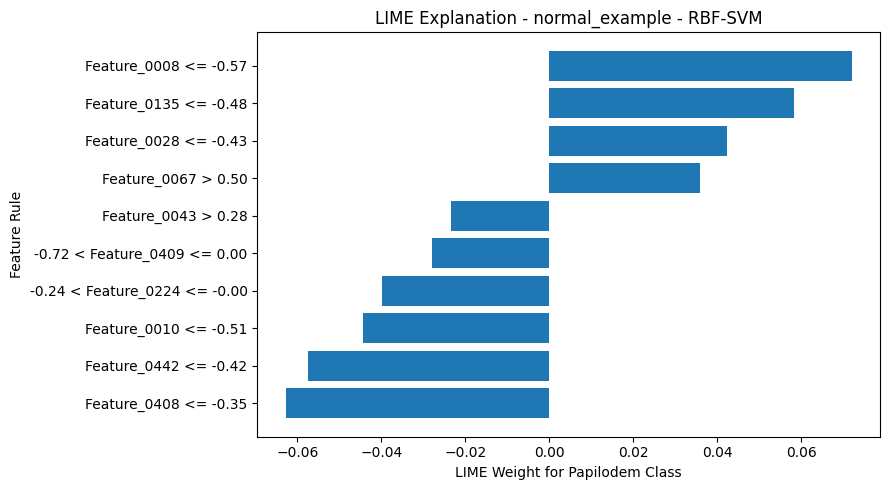

LIME HTML kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/outputs/lime_explanation_normal_example_rbf_svm.html
LIME grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/lime_explanation_normal_example_rbf_svm.png

papilodem_example
Gerçek sınıf: Papilodem
Model papilödem olasılığı: 0.3405225142849878
LIME açıklaması:
('Feature_0224 > 0.76', 0.08860169861286972)
('Feature_0500 > 0.67', 0.06977005603114149)
('0.00 < Feature_0409 <= 0.28', -0.049265512544929814)
('-0.35 < Feature_0408 <= 0.00', -0.03994895805264536)
('-0.42 < Feature_0442 <= 0.00', -0.038446066550149066)
('Feature_0010 > 0.49', 0.037935540605161876)
('Feature_0040 > 0.60', 0.036304833998129116)
('-0.71 < Feature_0034 <= 0.00', -0.029671599650517824)
('-0.66 < Feature_0046 <= -0.00', -0.025962316067258788)
('-0.73 < Feature_0411 <= 0.00', -0.025555364842750856)


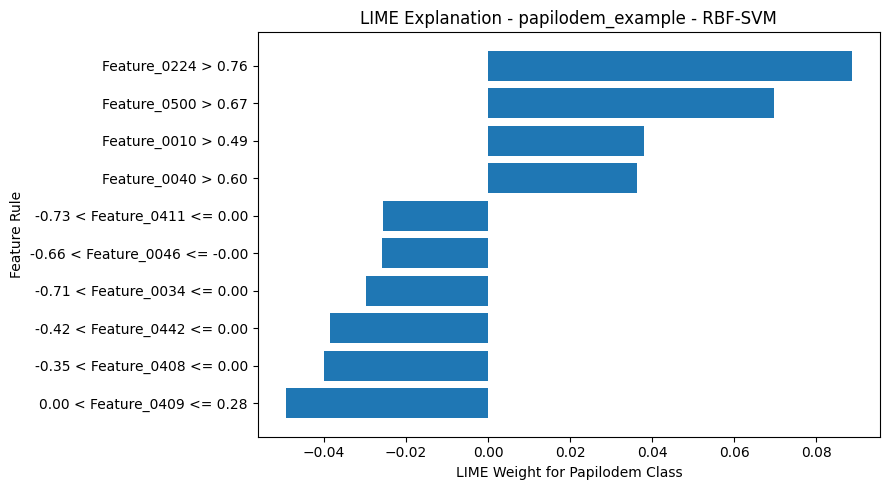

LIME HTML kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/outputs/lime_explanation_papilodem_example_rbf_svm.html
LIME grafik kaydedildi: /content/drive/MyDrive/radiomics_papilodem_project/figures/lime_explanation_papilodem_example_rbf_svm.png

LIME açıklama tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/lime_explanations_rbf_svm.csv


In [64]:
# =========================
# HÜCRE 63: LIME Açıklamaları
# =========================

lime_instances = {
    "normal_example": normal_instance_idx,
    "papilodem_example": papilodem_instance_idx
}

lime_explanation_records = []

for example_name, instance_idx in lime_instances.items():
    instance_values = X_test_selected_lime.iloc[instance_idx].values

    explanation = lime_explainer.explain_instance(
        data_row=instance_values,
        predict_fn=lime_predict_proba,
        num_features=10,
        labels=[1]
    )

    explanation_list = explanation.as_list(label=1)

    print("\n" + "=" * 80)
    print(example_name)
    print("Gerçek sınıf:", "Papilodem" if y_test[instance_idx] == 1 else "Normal")
    print("Model papilödem olasılığı:", lime_predict_proba(instance_values.reshape(1, -1))[0, 1])
    print("LIME açıklaması:")
    for item in explanation_list:
        print(item)

    html_path = os.path.join(
        OUTPUT_DIR,
        f"lime_explanation_{example_name}_rbf_svm.html"
    )
    explanation.save_to_file(html_path)

    for feature_rule, weight in explanation_list:
        lime_explanation_records.append({
            "example": example_name,
            "test_index": instance_idx,
            "true_class": int(y_test[instance_idx]),
            "feature_rule": feature_rule,
            "lime_weight_for_papilodem": weight
        })

    lime_plot_df = pd.DataFrame(
        explanation_list,
        columns=["feature_rule", "lime_weight_for_papilodem"]
    ).sort_values(by="lime_weight_for_papilodem", ascending=True)

    plt.figure(figsize=(9, 5))
    plt.barh(
        lime_plot_df["feature_rule"],
        lime_plot_df["lime_weight_for_papilodem"]
    )
    plt.title(f"LIME Explanation - {example_name} - RBF-SVM")
    plt.xlabel("LIME Weight for Papilodem Class")
    plt.ylabel("Feature Rule")
    plt.tight_layout()

    lime_fig_path = os.path.join(
        FIGURE_DIR,
        f"lime_explanation_{example_name}_rbf_svm.png"
    )
    plt.savefig(lime_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("LIME HTML kaydedildi:", html_path)
    print("LIME grafik kaydedildi:", lime_fig_path)

lime_explanations_df = pd.DataFrame(lime_explanation_records)

lime_explanations_path = os.path.join(
    OUTPUT_DIR,
    "lime_explanations_rbf_svm.csv"
)
lime_explanations_df.to_csv(lime_explanations_path, index=False)

print("\nLIME açıklama tablosu kaydedildi:")
print(lime_explanations_path)

## 64. Bonus Deep Learning Modeli İçin Veri Hazırlığı

Bu bölümde basit bir tabular deep learning modeli kurulacaktır.

Model, radyomik özelliklerden papilödem sınıflandırması yapmak için çok katmanlı yapay sinir ağı mimarisi kullanacaktır.

Bu model ana model olarak değil, bonus çalışma olarak değerlendirilecektir. Veri seti küçük olduğu için erken durdurma ve dropout kullanılacaktır.

In [65]:
# =========================
# HÜCRE 64: Deep Learning Veri Hazırlığı
# =========================

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

tf.keras.utils.set_random_seed(RANDOM_STATE)

DL_MRMR_FEATURE_COUNT = 50

dl_preprocessor = RadiomicsPreprocessor(
    variance_threshold=1e-8,
    corr_threshold=0.95
)

X_train_dl_prep = dl_preprocessor.fit_transform(train_df[feature_cols])
X_val_dl_prep = dl_preprocessor.transform(val_df[feature_cols])
X_test_dl_prep = dl_preprocessor.transform(test_df[feature_cols])

dl_selected_features, dl_mrmr_table = mrmr_feature_selection(
    X=X_train_dl_prep,
    y=y_train,
    n_features=DL_MRMR_FEATURE_COUNT,
    redundancy_weight=0.5,
    random_state=RANDOM_STATE
)

X_train_dl = X_train_dl_prep[dl_selected_features].values.astype("float32")
X_val_dl = X_val_dl_prep[dl_selected_features].values.astype("float32")
X_test_dl = X_test_dl_prep[dl_selected_features].values.astype("float32")

y_train_dl = y_train.astype("float32")
y_val_dl = y_val.astype("float32")
y_test_dl = y_test.astype("float32")

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print("Deep learning train shape:", X_train_dl.shape)
print("Deep learning validation shape:", X_val_dl.shape)
print("Deep learning test shape:", X_test_dl.shape)
print("Class weights:", class_weight_dict)

Deep learning train shape: (672, 50)
Deep learning validation shape: (98, 50)
Deep learning test shape: (196, 50)
Class weights: {0: np.float64(0.7272727272727273), 1: np.float64(1.6)}


## 65. Deep Learning Modelinin Eğitilmesi

Bu bölümde çok katmanlı dense neural network modeli eğitilecektir.

Mimari:

- Dense layer
- Batch normalization
- Dropout
- Dense layer
- Dropout
- Sigmoid output

Model validation loss takip edilerek early stopping ile eğitilecektir.

In [66]:
# =========================
# HÜCRE 65: Deep Learning Model Eğitimi
# =========================

dl_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_dl.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = dl_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("Deep learning modeli eğitildi.")

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - accuracy: 0.7738 - auc: 0.8055 - loss: 0.5457 - precision: 0.6436 - recall: 0.6190 - val_accuracy: 0.8469 - val_auc: 1.0000 - val_loss: 0.3649 - val_precision: 0.6512 - val_recall: 1.0000
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8452 - auc: 0.9244 - loss: 0.3493 - precision: 0.7190 - recall: 0.8286 - val_accuracy: 0.8878 - val_auc: 1.0000 - val_loss: 0.2866 - val_precision: 0.7179 - val_recall: 1.0000
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8661 - auc: 0.9457 - loss: 0.2983 - precision: 0.7459 - recall: 0.8667 - val_accuracy: 0.9286 - val_auc: 1.0000 - val_loss: 0.2424 - val_precision: 0.8000 - val_recall: 1.0000
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8929 - auc: 0.9677 - loss: 0.2451 - precision: 0.8000 - recall: 0.8762 - val_accuracy: 0.9694 - val_auc: 1.0000 - val_loss: 0.2113 - val_precision: 0.9032 - val_recall: 1.0000
Epoch 5/200
21/21 ━━━━━━━━━━━━

## 66. Deep Learning Modelinin Bağımsız Test Setinde Değerlendirilmesi

Bu bölümde bonus deep learning modeli bağımsız test seti üzerinde değerlendirilecektir.

Threshold seçimi validation set üzerinde yapılacak, test seti yalnızca final değerlendirme için kullanılacaktır.

Bu sonuçlar ana model karşılaştırmasını destekleyici bonus analiz olarak rapora eklenebilir.

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


,Model,Threshold,N MRMR Features,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10
0,Deep Learning MLP,0.6,50,0.979592,0.948276,0.982143,0.964912,0.975262,0.980357,0.999617,0.999092,0.011769,0.026952


Deep learning test sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/deep_learning_mlp_test_results.csv

Deep learning threshold tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/deep_learning_threshold_search_validation.csv


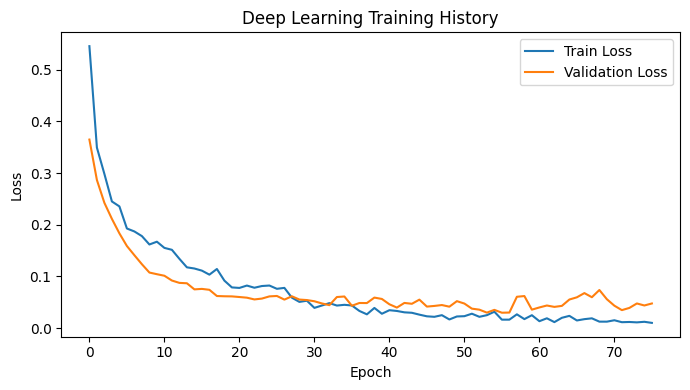

Deep learning training history grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/deep_learning_training_history.png


In [67]:
# =========================
# HÜCRE 66: Deep Learning Test Değerlendirmesi
# =========================

dl_val_proba = dl_model.predict(X_val_dl).ravel()
dl_test_proba = dl_model.predict(X_test_dl).ravel()

dl_best_threshold, dl_threshold_df = optimize_threshold_on_validation(
    y_true=y_val,
    y_proba=dl_val_proba,
    step=0.01
)

dl_test_pred = (dl_test_proba >= dl_best_threshold).astype(int)

dl_test_metrics = evaluate_final_binary_classification(
    y_true=y_test,
    y_pred=dl_test_pred,
    y_proba=dl_test_proba
)

dl_test_results_df = pd.DataFrame([{
    "Model": "Deep Learning MLP",
    "Threshold": dl_best_threshold,
    "N MRMR Features": DL_MRMR_FEATURE_COUNT,
    **dl_test_metrics
}])

display(dl_test_results_df)

dl_results_path = os.path.join(
    OUTPUT_DIR,
    "deep_learning_mlp_test_results.csv"
)
dl_test_results_df.to_csv(dl_results_path, index=False)

dl_threshold_path = os.path.join(
    OUTPUT_DIR,
    "deep_learning_threshold_search_validation.csv"
)
dl_threshold_df.to_csv(dl_threshold_path, index=False)

print("Deep learning test sonuçları kaydedildi:")
print(dl_results_path)

print("\nDeep learning threshold tablosu kaydedildi:")
print(dl_threshold_path)

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Deep Learning Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

dl_history_fig_path = os.path.join(
    FIGURE_DIR,
    "deep_learning_training_history.png"
)
plt.savefig(dl_history_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Deep learning training history grafiği kaydedildi:")
print(dl_history_fig_path)

## 67. Soft Voting Ensemble Ağırlık Optimizasyonu

Bu bölümde RF, ET ve GB modellerinden oluşan ensemble için ağırlık optimizasyonu yapılacaktır.

Önceki soft voting ensemble sabit ortalama ile kurulmuştu. Bu bölümde validation set üzerinde farklı ağırlık kombinasyonları denenerek Macro-F1 skorunu maksimize eden ağırlıklar seçilecektir.

Test seti ağırlık seçiminde kullanılmayacak, yalnızca seçilen ağırlıkların final değerlendirmesinde kullanılacaktır.

In [68]:
# =========================
# HÜCRE 67: Weighted Ensemble Optimization
# =========================

ensemble_base_models = ["RF", "ET", "GB"]

val_probs_for_weighted_ensemble = {
    model_name: validation_prediction_store[model_name]["val_calibrated_proba"]
    for model_name in ensemble_base_models
}

test_probs_for_weighted_ensemble = {
    model_name: test_prediction_store[model_name]["calibrated_proba"]
    for model_name in ensemble_base_models
}

weight_records = []

weight_grid = np.arange(0.0, 1.01, 0.05)

for w_rf in weight_grid:
    for w_et in weight_grid:
        w_gb = 1.0 - w_rf - w_et

        if w_gb < -1e-9:
            continue

        w_gb = round(w_gb, 10)

        weights = {
            "RF": w_rf,
            "ET": w_et,
            "GB": w_gb
        }

        val_proba_weighted = (
            weights["RF"] * val_probs_for_weighted_ensemble["RF"] +
            weights["ET"] * val_probs_for_weighted_ensemble["ET"] +
            weights["GB"] * val_probs_for_weighted_ensemble["GB"]
        )

        best_threshold_w, threshold_df_w = optimize_threshold_on_validation(
            y_true=y_val,
            y_proba=val_proba_weighted,
            step=0.01
        )

        val_pred_w = (val_proba_weighted >= best_threshold_w).astype(int)

        macro_f1_w = f1_score(
            y_val,
            val_pred_w,
            average="macro",
            zero_division=0
        )

        balanced_acc_w = balanced_accuracy_score(y_val, val_pred_w)

        weight_records.append({
            "w_RF": weights["RF"],
            "w_ET": weights["ET"],
            "w_GB": weights["GB"],
            "threshold": best_threshold_w,
            "Validation Macro-F1": macro_f1_w,
            "Validation Balanced Accuracy": balanced_acc_w
        })

weighted_ensemble_search_df = pd.DataFrame(weight_records)

best_weight_row = weighted_ensemble_search_df.sort_values(
    by=["Validation Macro-F1", "Validation Balanced Accuracy"],
    ascending=False
).iloc[0]

best_weights = {
    "RF": float(best_weight_row["w_RF"]),
    "ET": float(best_weight_row["w_ET"]),
    "GB": float(best_weight_row["w_GB"])
}

weighted_ensemble_threshold = float(best_weight_row["threshold"])

print("En iyi ensemble ağırlıkları:")
print(best_weights)
print("Weighted ensemble threshold:", weighted_ensemble_threshold)

display(best_weight_row.to_frame().T)

weighted_search_path = os.path.join(
    OUTPUT_DIR,
    "weighted_ensemble_validation_search.csv"
)
weighted_ensemble_search_df.to_csv(weighted_search_path, index=False)

print("Weighted ensemble validation arama tablosu kaydedildi:")
print(weighted_search_path)

En iyi ensemble ağırlıkları:
{'RF': 0.0, 'ET': 0.0, 'GB': 1.0}
Weighted ensemble threshold: 0.5600000000000002


,w_RF,w_ET,w_GB,threshold,Validation Macro-F1,Validation Balanced Accuracy
0,0.0,0.0,1.0,0.56,1.0,1.0


Weighted ensemble validation arama tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/weighted_ensemble_validation_search.csv


## 68. Weighted Ensemble Modelinin Bağımsız Test Setinde Değerlendirilmesi

Bu bölümde validation set üzerinde seçilen ensemble ağırlıkları bağımsız test setine uygulanacaktır.

Bu analiz, sabit soft voting ensemble ile optimize edilmiş weighted ensemble performansını karşılaştırmak için yapılmaktadır.

,Model,w_RF,w_ET,w_GB,Threshold,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10
0,Weighted Ensemble RF+ET+GB,0.0,0.0,1.0,0.56,0.933673,0.977778,0.785714,0.871287,0.913307,0.889286,0.984439,0.968603,0.045701,0.06029


Weighted Ensemble Confusion Matrix:
[[139   1]
 [ 12  44]]


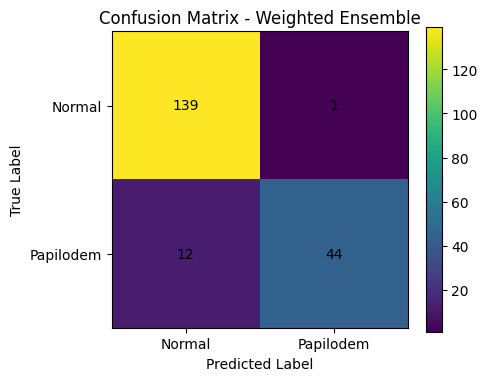

Weighted ensemble test sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/weighted_ensemble_test_results.csv

Weighted ensemble confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/weighted_ensemble_confusion_matrix.png


In [69]:
# =========================
# HÜCRE 68: Weighted Ensemble Test Evaluation
# =========================

weighted_ensemble_test_proba = (
    best_weights["RF"] * test_probs_for_weighted_ensemble["RF"] +
    best_weights["ET"] * test_probs_for_weighted_ensemble["ET"] +
    best_weights["GB"] * test_probs_for_weighted_ensemble["GB"]
)

weighted_ensemble_test_pred = (
    weighted_ensemble_test_proba >= weighted_ensemble_threshold
).astype(int)

weighted_ensemble_test_metrics = evaluate_final_binary_classification(
    y_true=y_test,
    y_pred=weighted_ensemble_test_pred,
    y_proba=weighted_ensemble_test_proba
)

weighted_ensemble_results_df = pd.DataFrame([{
    "Model": "Weighted Ensemble RF+ET+GB",
    "w_RF": best_weights["RF"],
    "w_ET": best_weights["ET"],
    "w_GB": best_weights["GB"],
    "Threshold": weighted_ensemble_threshold,
    **weighted_ensemble_test_metrics
}])

display(weighted_ensemble_results_df)

weighted_ensemble_results_path = os.path.join(
    OUTPUT_DIR,
    "weighted_ensemble_test_results.csv"
)
weighted_ensemble_results_df.to_csv(weighted_ensemble_results_path, index=False)

weighted_cm = confusion_matrix(y_test, weighted_ensemble_test_pred)

print("Weighted Ensemble Confusion Matrix:")
print(weighted_cm)

plt.figure(figsize=(5, 4))
plt.imshow(weighted_cm)
plt.title("Confusion Matrix - Weighted Ensemble")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Normal", "Papilodem"])
plt.yticks([0, 1], ["Normal", "Papilodem"])

for i in range(weighted_cm.shape[0]):
    for j in range(weighted_cm.shape[1]):
        plt.text(j, i, weighted_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

weighted_cm_fig_path = os.path.join(
    FIGURE_DIR,
    "weighted_ensemble_confusion_matrix.png"
)
plt.savefig(weighted_cm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Weighted ensemble test sonuçları kaydedildi:")
print(weighted_ensemble_results_path)

print("\nWeighted ensemble confusion matrix grafiği kaydedildi:")
print(weighted_cm_fig_path)

## 69. Bonus Nested Cross-Validation Analizi

Bu bölümde en başarılı final model olan RBF-SVM için nested cross-validation analizi yapılacaktır.

Nested cross-validation iki seviyeli doğrulama yapısı kullanır:

- Outer loop: Modelin bağımsız fold performansını tahmin eder.
- Inner loop: Her outer training fold içinde hiperparametre seçimi yapar.

Bu analiz, model performansının tek bir train-test ayrımına bağlı olup olmadığını değerlendirmek için bonus çalışma olarak eklenmiştir.

Hesaplama maliyetini kontrol altında tutmak için nested CV yalnızca en başarılı model olan RBF-SVM üzerinde uygulanacaktır.

In [70]:
# =========================
# HÜCRE 69: Bonus Nested CV Ayarları
# =========================

NESTED_MODEL_NAME = "RBF-SVM"

# Hesaplama maliyetini kontrol etmek için bonus analizde daha küçük ayar kullanıyoruz.
NESTED_OUTER_SPLITS = 5
NESTED_INNER_SPLITS = 3
NESTED_OPTUNA_TRIALS = 15

NESTED_MRMR_FEATURE_OPTIONS = [20, 30, 40, 50]

print("Nested CV modeli:", NESTED_MODEL_NAME)
print("Outer fold sayısı:", NESTED_OUTER_SPLITS)
print("Inner fold sayısı:", NESTED_INNER_SPLITS)
print("Her outer fold için Optuna trial sayısı:", NESTED_OPTUNA_TRIALS)
print("MRMR özellik seçenekleri:", NESTED_MRMR_FEATURE_OPTIONS)

Nested CV modeli: RBF-SVM
Outer fold sayısı: 5
Inner fold sayısı: 3
Her outer fold için Optuna trial sayısı: 15
MRMR özellik seçenekleri: [20, 30, 40, 50]


## 70. Nested CV İçin RBF-SVM Objective Fonksiyonunun Tanımlanması

Bu bölümde RBF-SVM için nested CV içinde kullanılacak Optuna objective fonksiyonu tanımlanacaktır.

Her inner fold içinde preprocessing ve MRMR yalnızca inner-training verisine fit edilecektir. Böylece nested CV sürecinde de veri sızıntısı engellenir.

In [71]:
# =========================
# HÜCRE 70: Nested CV Objective Fonksiyonu
# =========================

def create_nested_rbf_svm_objective(X_raw, y, groups):
    def objective(trial):
        n_mrmr_features = trial.suggest_categorical(
            "n_mrmr_features",
            NESTED_MRMR_FEATURE_OPTIONS
        )

        C = trial.suggest_float("C", 1e-2, 100.0, log=True)
        gamma = trial.suggest_float("gamma", 1e-4, 10.0, log=True)
        class_weight_option = trial.suggest_categorical("class_weight", ["balanced", None])

        inner_cv = StratifiedGroupKFold(
            n_splits=NESTED_INNER_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        inner_scores = []

        for fold_id, (inner_train_idx, inner_val_idx) in enumerate(
            inner_cv.split(X_raw, y, groups)
        ):
            X_inner_train_raw = X_raw.iloc[inner_train_idx].copy()
            X_inner_val_raw = X_raw.iloc[inner_val_idx].copy()

            y_inner_train = y[inner_train_idx]
            y_inner_val = y[inner_val_idx]

            fold_preprocessor = RadiomicsPreprocessor(
                variance_threshold=1e-8,
                corr_threshold=0.95
            )

            X_inner_train_prep = fold_preprocessor.fit_transform(X_inner_train_raw)
            X_inner_val_prep = fold_preprocessor.transform(X_inner_val_raw)

            selected_features_fold, _ = mrmr_feature_selection(
                X=X_inner_train_prep,
                y=y_inner_train,
                n_features=n_mrmr_features,
                redundancy_weight=0.5,
                random_state=RANDOM_STATE + fold_id
            )

            X_inner_train_selected = X_inner_train_prep[selected_features_fold]
            X_inner_val_selected = X_inner_val_prep[selected_features_fold]

            model = SVC(
                kernel="rbf",
                C=C,
                gamma=gamma,
                probability=True,
                class_weight=class_weight_option,
                random_state=RANDOM_STATE
            )

            model.fit(X_inner_train_selected, y_inner_train)

            y_inner_pred = model.predict(X_inner_val_selected)

            inner_macro_f1 = f1_score(
                y_inner_val,
                y_inner_pred,
                average="macro",
                zero_division=0
            )

            inner_scores.append(inner_macro_f1)

        return float(np.mean(inner_scores))

    return objective

print("Nested RBF-SVM objective fonksiyonu hazır.")

Nested RBF-SVM objective fonksiyonu hazır.


## 71. RBF-SVM İçin Patient-Level Nested Cross-Validation Çalıştırılması

Bu bölümde RBF-SVM modeli için nested cross-validation uygulanacaktır.

Her outer fold içinde:

1. Outer train ve outer test hasta bazlı ayrılır.
2. Outer train içinde Optuna ile inner CV hiperparametre optimizasyonu yapılır.
3. En iyi hiperparametrelerle outer train üzerinde preprocessing, MRMR ve model yeniden fit edilir.
4. Outer test fold üzerinde performans hesaplanır.

Bu analiz bağımsız final test sonucunun yerine geçmez; modelin kararlılığını destekleyen bonus analiz olarak kullanılır.

In [72]:
# =========================
# HÜCRE 71: RBF-SVM Nested Cross-Validation
# =========================

# Nested CV için yalnızca development alanını kullanıyoruz.
# Böylece bağımsız test seti final değerlendirme olarak ayrı kalır.
nested_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

X_nested_raw = nested_df[feature_cols].copy()
y_nested = nested_df["target"].astype(int).values
groups_nested = nested_df["group_id"].values

outer_cv = StratifiedGroupKFold(
    n_splits=NESTED_OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

nested_records = []
nested_best_params_records = []

for outer_fold_id, (outer_train_idx, outer_test_idx) in enumerate(
    outer_cv.split(X_nested_raw, y_nested, groups_nested),
    start=1
):
    print("\n" + "=" * 80)
    print(f"Nested CV outer fold {outer_fold_id}/{NESTED_OUTER_SPLITS}")
    print("=" * 80)

    X_outer_train_raw = X_nested_raw.iloc[outer_train_idx].copy()
    X_outer_test_raw = X_nested_raw.iloc[outer_test_idx].copy()

    y_outer_train = y_nested[outer_train_idx]
    y_outer_test = y_nested[outer_test_idx]

    groups_outer_train = groups_nested[outer_train_idx]

    sampler = TPESampler(seed=RANDOM_STATE + outer_fold_id)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        study_name=f"nested_rbf_svm_outer_fold_{outer_fold_id}"
    )

    objective = create_nested_rbf_svm_objective(
        X_raw=X_outer_train_raw,
        y=y_outer_train,
        groups=groups_outer_train
    )

    study.optimize(
        objective,
        n_trials=NESTED_OPTUNA_TRIALS,
        show_progress_bar=True
    )

    best_params = study.best_params

    nested_best_params_records.append({
        "outer_fold": outer_fold_id,
        "best_inner_cv_macro_f1": study.best_value,
        **best_params
    })

    # Outer train üzerinde final fold pipeline fit
    fold_train_df = nested_df.iloc[outer_train_idx].reset_index(drop=True)
    fold_test_df = nested_df.iloc[outer_test_idx].reset_index(drop=True)

    fold_best_params = best_params.copy()

    fold_pipeline = fit_model_pipeline(
        train_data=fold_train_df,
        feature_columns=feature_cols,
        model_name="RBF-SVM",
        best_params=fold_best_params
    )

    y_outer_test_proba = predict_pipeline_proba(
        pipeline=fold_pipeline,
        data=fold_test_df,
        feature_columns=feature_cols
    )

    # Nested CV içinde threshold leakage olmaması için 0.5 kullanıyoruz.
    y_outer_test_pred = (y_outer_test_proba >= 0.5).astype(int)

    metrics = evaluate_final_binary_classification(
        y_true=y_outer_test,
        y_pred=y_outer_test_pred,
        y_proba=y_outer_test_proba
    )

    metrics["outer_fold"] = outer_fold_id
    metrics["outer_test_sample_count"] = len(y_outer_test)
    metrics["outer_test_group_count"] = fold_test_df["group_id"].nunique()
    metrics["best_inner_cv_macro_f1"] = study.best_value
    metrics["n_mrmr_features"] = best_params["n_mrmr_features"]
    metrics["C"] = best_params["C"]
    metrics["gamma"] = best_params["gamma"]
    metrics["class_weight"] = best_params["class_weight"]

    nested_records.append(metrics)

nested_cv_results_df = pd.DataFrame(nested_records)

nested_cv_results_df = nested_cv_results_df[
    [
        "outer_fold",
        "outer_test_sample_count",
        "outer_test_group_count",
        "best_inner_cv_macro_f1",
        "n_mrmr_features",
        "C",
        "gamma",
        "class_weight",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Macro-F1",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "ECE-10"
    ]
]

print("\nNested CV fold sonuçları:")
display(nested_cv_results_df)

nested_cv_summary_df = nested_cv_results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Macro-F1",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "ECE-10"
    ]
].agg(["mean", "std"]).T.reset_index()

nested_cv_summary_df.columns = ["Metric", "Mean", "Std"]

print("\nNested CV özet sonuçları:")
display(nested_cv_summary_df)

nested_cv_results_path = os.path.join(
    OUTPUT_DIR,
    "nested_cv_rbf_svm_outer_fold_results.csv"
)

nested_cv_summary_path = os.path.join(
    OUTPUT_DIR,
    "nested_cv_rbf_svm_summary.csv"
)

nested_best_params_path = os.path.join(
    OUTPUT_DIR,
    "nested_cv_rbf_svm_best_params_by_outer_fold.csv"
)

nested_cv_results_df.to_csv(nested_cv_results_path, index=False)
nested_cv_summary_df.to_csv(nested_cv_summary_path, index=False)
pd.DataFrame(nested_best_params_records).to_csv(nested_best_params_path, index=False)

print("\nNested CV fold sonuçları kaydedildi:")
print(nested_cv_results_path)

print("\nNested CV özet sonuçları kaydedildi:")
print(nested_cv_summary_path)

print("\nNested CV best params kaydedildi:")
print(nested_best_params_path)

[I 2026-06-09 21:49:19,236] A new study created in memory with name: nested_rbf_svm_outer_fold_1



Nested CV outer fold 1/5


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-09 21:49:24,146] Trial 0 finished with value: 0.40497512437810945 and parameters: {'n_mrmr_features': 30, 'C': 0.20349616224981557, 'gamma': 1.975547401915311, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.40497512437810945.
[I 2026-06-09 21:49:28,770] Trial 1 finished with value: 0.4057459611910425 and parameters: {'n_mrmr_features': 50, 'C': 0.10415605048648957, 'gamma': 0.00019249731810955166, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.4057459611910425.
[I 2026-06-09 21:49:35,927] Trial 2 finished with value: 0.4055555555555556 and parameters: {'n_mrmr_features': 50, 'C': 24.874627793005725, 'gamma': 7.199883299874765, 'class_weight': None}. Best is trial 1 with value: 0.4057459611910425.
[I 2026-06-09 21:49:42,431] Trial 3 finished with value: 0.8578782591252047 and parameters: {'n_mrmr_features': 50, 'C': 0.15560158006902594, 'gamma': 0.0020489158070976943, 'class_weight': None}. Best is trial 3 with value: 0.8578782591252047.
[I 2026-06-09 

[I 2026-06-09 21:50:41,113] A new study created in memory with name: nested_rbf_svm_outer_fold_2


...

[I 2026-06-09 21:54:39,058] Trial 0 finished with value: 0.41568309531593045 and parameters: {'n_mrmr_features': 30, 'C': 6.767379836193071, 'gamma': 0.9954581539032689, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.41568309531593045.
[I 2026-06-09 21:54:43,401] Trial 1 finished with value: 0.8335120777226991 and parameters: {'n_mrmr_features': 20, 'C': 0.024825832415288848, 'gamma': 0.0031782069776994043, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8335120777226991.
[I 2026-06-09 21:54:47,940] Trial 2 finished with value: 0.8633912423342509 and parameters: {'n_mrmr_features': 30, 'C': 65.71291452152195, 'gamma': 0.0004320886467928906, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.8633912423342509.
[I 2026-06-09 21:54:54,126] Trial 3 finished with value: 0.8510699249240213 and parameters: {'n_mrmr_features': 50, 'C': 1.1232957583917667, 'gamma': 0.000772787925846661, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.8633912423342509.
[I

,outer_fold,outer_test_sample_count,outer_test_group_count,best_inner_cv_macro_f1,n_mrmr_features,C,gamma,class_weight,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10
0,1,154,11,0.879363,20,1.538087,0.000149,balanced,0.870130,0.823529,0.666667,0.736842,0.825318,0.806548,0.869898,0.798838,0.120299,0.115599
1,2,154,11,0.932158,40,2.571537,0.002310,None,0.805195,1.000000,0.285714,0.444444,0.663167,0.642857,0.768282,0.733811,0.153643,0.144274
2,3,154,11,0.850257,30,0.139345,0.007913,balanced,0.922078,0.833333,0.982143,0.901639,0.918562,0.934949,0.996538,0.994640,0.042581,0.112163
3,4,154,11,0.861597,30,0.076631,0.029521,None,0.909091,1.000000,0.750000,0.857143,0.895238,0.875000,0.901603,0.900727,0.082311,0.061937
4,5,154,11,0.907020,40,0.548185,0.053706,balanced,0.889610,0.711864,1.000000,0.831683,0.874779,0.924107,0.959184,0.837571,0.089494,0.109807



Nested CV özet sonuçları:


,Metric,Mean,Std
0,Accuracy,0.879221,0.045824
1,Precision,0.873745,0.124740
2,Recall,0.736905,0.290705
3,F1-score,0.754350,0.183432
4,Macro-F1,0.835413,0.102241
5,Balanced Accuracy,0.836692,0.119629
6,ROC-AUC,0.899101,0.088143
7,PR-AUC,0.853117,0.099646
8,Brier Score,0.097665,0.041781
9,ECE-10,0.108756,0.029636



Nested CV fold sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/nested_cv_rbf_svm_outer_fold_results.csv

Nested CV özet sonuçları kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/nested_cv_rbf_svm_summary.csv

Nested CV best params kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/nested_cv_rbf_svm_best_params_by_outer_fold.csv


## 72. Nested Cross-Validation Sonuçlarının Görselleştirilmesi

Bu bölümde RBF-SVM nested cross-validation outer fold Macro-F1 skorları görselleştirilecektir.

Bu grafik, modelin farklı hasta bazlı outer foldlarda ne kadar kararlı performans verdiğini gösterir.

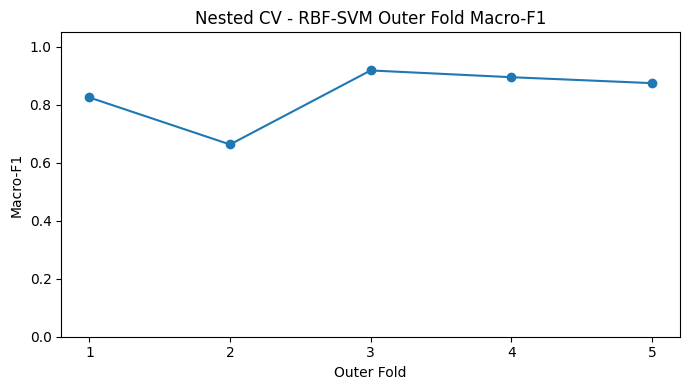

Nested CV Macro-F1 grafiği kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/figures/nested_cv_rbf_svm_outer_fold_macro_f1.png


In [73]:
# =========================
# HÜCRE 72: Nested CV Macro-F1 Grafiği
# =========================

plt.figure(figsize=(7, 4))
plt.plot(
    nested_cv_results_df["outer_fold"],
    nested_cv_results_df["Macro-F1"],
    marker="o"
)

plt.title("Nested CV - RBF-SVM Outer Fold Macro-F1")
plt.xlabel("Outer Fold")
plt.ylabel("Macro-F1")
plt.ylim(0, 1.05)
plt.xticks(nested_cv_results_df["outer_fold"])
plt.tight_layout()

nested_cv_macro_f1_fig_path = os.path.join(
    FIGURE_DIR,
    "nested_cv_rbf_svm_outer_fold_macro_f1.png"
)
plt.savefig(nested_cv_macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Nested CV Macro-F1 grafiği kaydedildi:")
print(nested_cv_macro_f1_fig_path)

## 73. MRMR Özellik Seçiminin Performansa Etkisinin Değerlendirilmesi

Bu bölümde MRMR özellik seçiminin model performansına etkisi incelenmektedir.

Karşılaştırmanın adil olması için aynı RBF-SVM hiperparametreleri kullanılacaktır. Bir senaryoda model preprocessing sonrası kalan tüm özelliklerle eğitilecek, diğer senaryoda ise MRMR ile seçilen özellikler kullanılacaktır.

Bu analizde amaç final model seçimini değiştirmek değil, MRMR özellik seçiminin performans ve boyut azaltma açısından katkısını raporlamaktır.

In [74]:
# =========================
# HÜCRE 73: MRMR vs No-MRMR Karşılaştırması
# =========================

best_rbf_params = final_optuna_studies["RBF-SVM"].best_params.copy()

def evaluate_rbf_mrmr_effect(use_mrmr):
    preprocessor = RadiomicsPreprocessor(
        variance_threshold=1e-8,
        corr_threshold=0.95
    )

    X_train_prep = preprocessor.fit_transform(train_df[feature_cols])
    X_val_prep = preprocessor.transform(val_df[feature_cols])
    X_test_prep = preprocessor.transform(test_df[feature_cols])

    y_train_local = train_df["target"].astype(int).values
    y_val_local = val_df["target"].astype(int).values
    y_test_local = test_df["target"].astype(int).values

    if use_mrmr:
        selected_features, _ = mrmr_feature_selection(
            X=X_train_prep,
            y=y_train_local,
            n_features=best_rbf_params["n_mrmr_features"],
            redundancy_weight=0.5,
            random_state=RANDOM_STATE
        )
    else:
        selected_features = list(X_train_prep.columns)

    X_train_selected = X_train_prep[selected_features]
    X_val_selected = X_val_prep[selected_features]
    X_test_selected = X_test_prep[selected_features]

    model = SVC(
        kernel="rbf",
        C=best_rbf_params["C"],
        gamma=best_rbf_params["gamma"],
        probability=True,
        class_weight=best_rbf_params["class_weight"],
        random_state=RANDOM_STATE
    )

    model.fit(X_train_selected, y_train_local)

    val_proba = model.predict_proba(X_val_selected)[:, 1]
    test_proba = model.predict_proba(X_test_selected)[:, 1]

    best_threshold, threshold_df = optimize_threshold_on_validation(
        y_true=y_val_local,
        y_proba=val_proba,
        step=0.01
    )

    test_pred = (test_proba >= best_threshold).astype(int)

    metrics = evaluate_final_binary_classification(
        y_true=y_test_local,
        y_pred=test_pred,
        y_proba=test_proba
    )

    cm = confusion_matrix(y_test_local, test_pred)

    return {
        "Setting": "With MRMR" if use_mrmr else "Without MRMR",
        "Feature Count": len(selected_features),
        "Threshold": best_threshold,
        **metrics,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    }

mrmr_effect_results = [
    evaluate_rbf_mrmr_effect(use_mrmr=False),
    evaluate_rbf_mrmr_effect(use_mrmr=True)
]

mrmr_effect_df = pd.DataFrame(mrmr_effect_results)

ordered_cols = [
    "Setting",
    "Feature Count",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Brier Score",
    "ECE-10",
    "TN",
    "FP",
    "FN",
    "TP"
]

mrmr_effect_df = mrmr_effect_df[ordered_cols]

print("MRMR vs No-MRMR karşılaştırması:")
display(mrmr_effect_df)

mrmr_effect_path = os.path.join(
    OUTPUT_DIR,
    "mrmr_vs_no_mrmr_rbf_svm_test_comparison.csv"
)
mrmr_effect_df.to_csv(mrmr_effect_path, index=False)

print("MRMR karşılaştırma tablosu kaydedildi:")
print(mrmr_effect_path)

MRMR vs No-MRMR karşılaştırması:


,Setting,Feature Count,Threshold,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,ROC-AUC,PR-AUC,Brier Score,ECE-10,TN,FP,FN,TP
0,Without MRMR,237,0.32,0.714286,0.000000,0.000000,0.000000,0.416667,0.500000,0.956760,0.828218,0.204670,0.026982,140,0,56,0
1,With MRMR,20,0.56,0.969388,0.980769,0.910714,0.944444,0.961659,0.951786,0.993495,0.987029,0.025509,0.034111,139,1,5,51


MRMR karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/mrmr_vs_no_mrmr_rbf_svm_test_comparison.csv


## 74. Kalibrasyonun Model Güvenilirliğine Etkisinin Değerlendirilmesi

Bu bölümde sigmoid kalibrasyonun model olasılık çıktılarının güvenilirliği üzerindeki etkisi incelenmektedir.

Kalibrasyonun amacı sınıf tahminini değiştirmekten çok, modelin ürettiği olasılık değerlerini gerçek gözlenme oranlarına daha yakın hale getirmektir.

Bu nedenle karşılaştırmada özellikle Brier Score ve Expected Calibration Error değerleri kullanılacaktır. Bu değerlerin düşmesi, olasılık tahminlerinin daha güvenilir hale geldiğini gösterir.

In [75]:
# =========================
# HÜCRE 74: Raw vs Calibrated Probability Karşılaştırması
# =========================

from sklearn.metrics import brier_score_loss

calibration_comparison_records = []

calibration_model_names = ["LR", "RBF-SVM", "RF", "ET", "GB", "KNN"]

for model_name in calibration_model_names:
    if model_name not in final_dev_pipelines:
        continue

    pipeline = final_dev_pipelines[model_name]
    calibrator = final_dev_calibrators[model_name]

    raw_test_proba = predict_pipeline_proba(
        pipeline=pipeline,
        data=test_df,
        feature_columns=feature_cols
    )

    calibrated_test_proba = calibrator.predict_proba(raw_test_proba)

    raw_brier = brier_score_loss(y_test, raw_test_proba)
    calibrated_brier = brier_score_loss(y_test, calibrated_test_proba)

    raw_ece = expected_calibration_error(
        y_true=y_test,
        y_proba=raw_test_proba,
        n_bins=10
    )

    calibrated_ece = expected_calibration_error(
        y_true=y_test,
        y_proba=calibrated_test_proba,
        n_bins=10
    )

    calibration_comparison_records.append({
        "Model": model_name,
        "Raw Brier Score": raw_brier,
        "Calibrated Brier Score": calibrated_brier,
        "Brier Improvement": raw_brier - calibrated_brier,
        "Raw ECE-10": raw_ece,
        "Calibrated ECE-10": calibrated_ece,
        "ECE Improvement": raw_ece - calibrated_ece
    })

calibration_comparison_df = pd.DataFrame(calibration_comparison_records)

calibration_comparison_df = calibration_comparison_df.sort_values(
    by="Brier Improvement",
    ascending=False
).reset_index(drop=True)

print("Raw probability vs calibrated probability karşılaştırması:")
display(calibration_comparison_df)

calibration_comparison_path = os.path.join(
    OUTPUT_DIR,
    "raw_vs_calibrated_probability_test_comparison.csv"
)
calibration_comparison_df.to_csv(calibration_comparison_path, index=False)

print("Kalibrasyon karşılaştırma tablosu kaydedildi:")
print(calibration_comparison_path)

Raw probability vs calibrated probability karşılaştırması:


,Model,Raw Brier Score,Calibrated Brier Score,Brier Improvement,Raw ECE-10,Calibrated ECE-10,ECE Improvement
0,GB,0.050149,0.045701,0.004448,0.047360,0.060290,-0.012931
1,ET,0.037620,0.038414,-0.000794,0.060686,0.057238,0.003448
2,RF,0.044868,0.046700,-0.001832,0.060021,0.059758,0.000263
3,LR,0.026398,0.031966,-0.005569,0.047363,0.133379,-0.086016
4,RBF-SVM,0.021889,0.027744,-0.005856,0.032386,0.072334,-0.039948
5,KNN,0.036803,0.048220,-0.011418,0.035905,0.057742,-0.021837


Kalibrasyon karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/radiomics_papilodem_project/outputs/raw_vs_calibrated_probability_test_comparison.csv
